### Simple Plots


Loading Session 2 …

  Session from C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv
  stim_start_tick=1,232,500  welcome_ms=33,367  OFFSET=1,199,133
  LFP mA range: 0.0 → 4.6    packets with mA >= 2.0: 201

  Trial-level stim classification (threshold = 2.0 mA):
    T   dig   acc   peak_mA   stim_on    pkts   start_rel     end_rel
  T01     2     1      1.10     False      15       34067       41876
  T02     2     1      1.20     False      14       41876       48955
  T03     3     1      2.00      True      20       48955       58688
  T04     3     1      0.10     False      21       58688       69017
  T05     4     1      1.10     False      25       69017       81580
  T06     4     0      1.00     False       2       81580       94713
  T07     4     0      3.10      True      26       94713      108117
  T08     4     0      3.20      True      26      108117      120780
  T09     4     1      4.10      True      24      120780      133242
  T10     4     0      

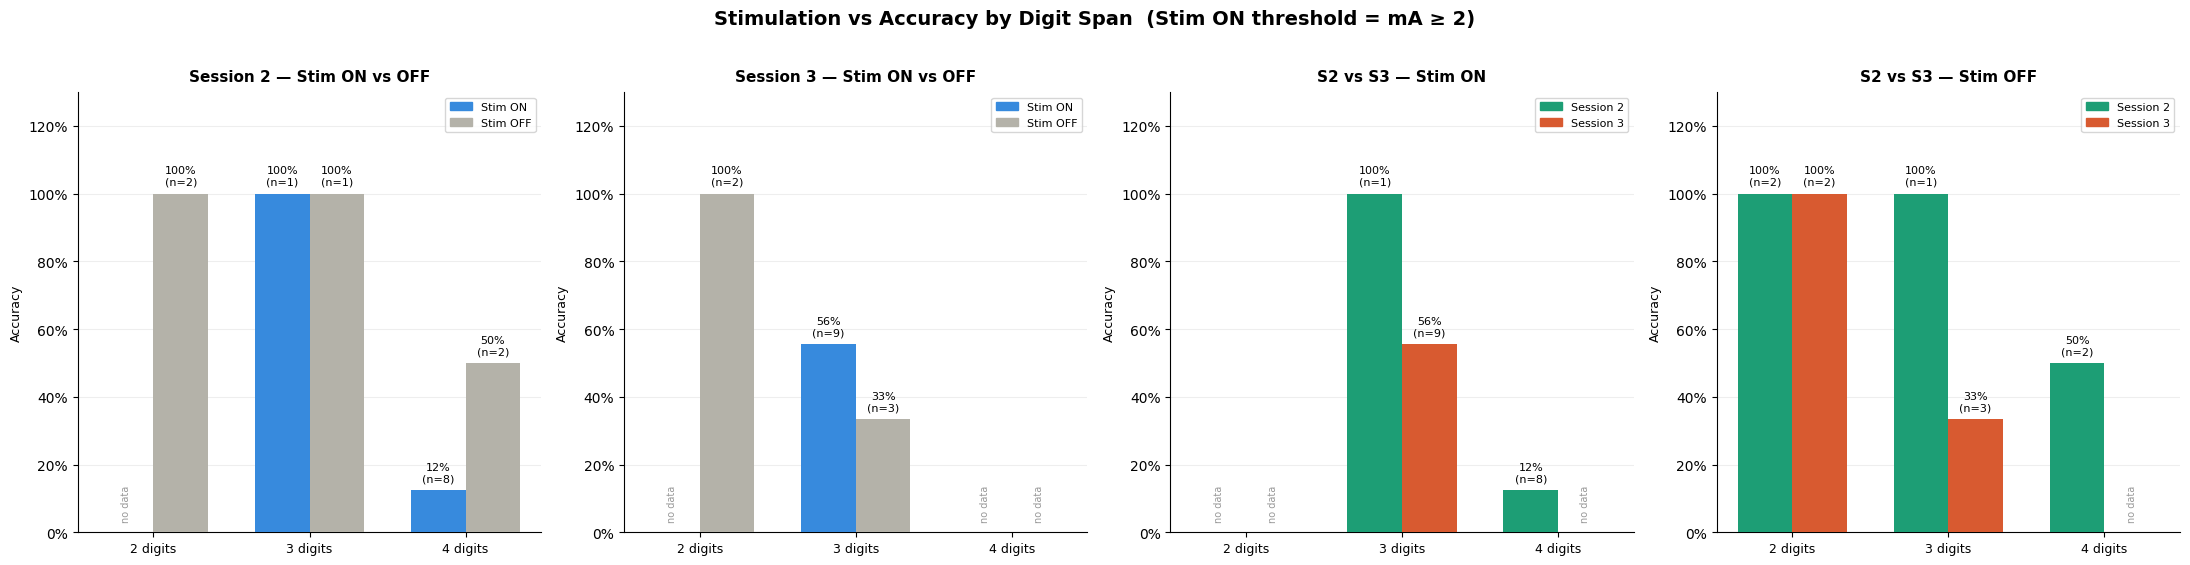

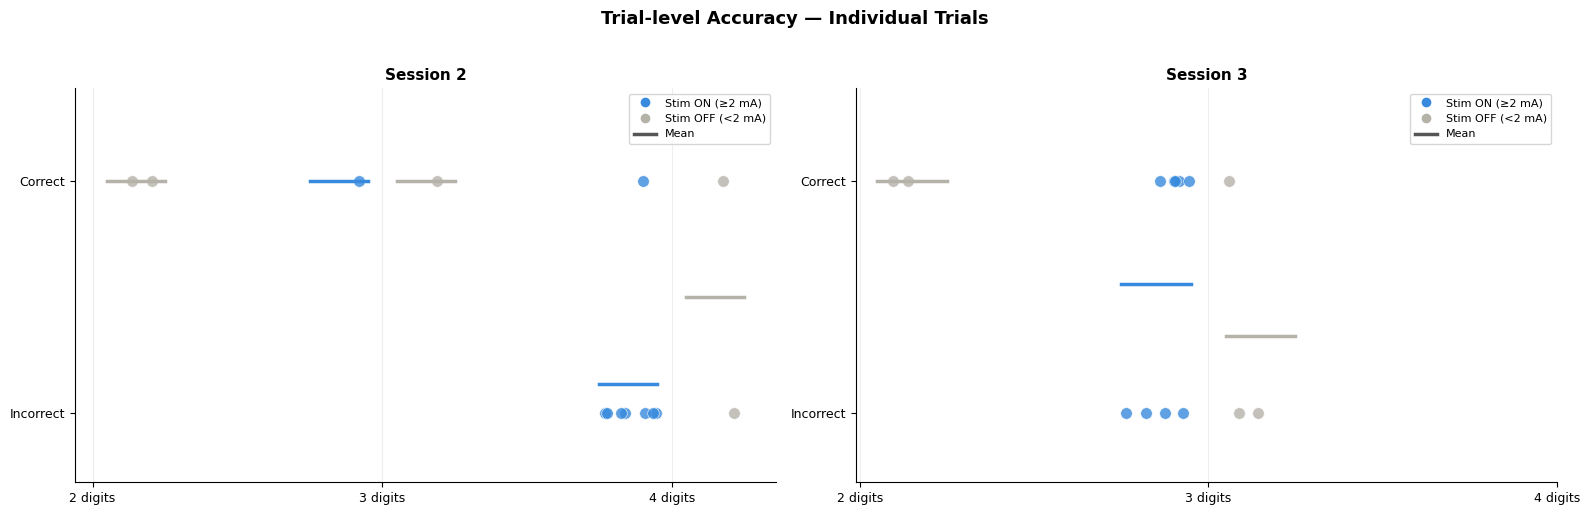

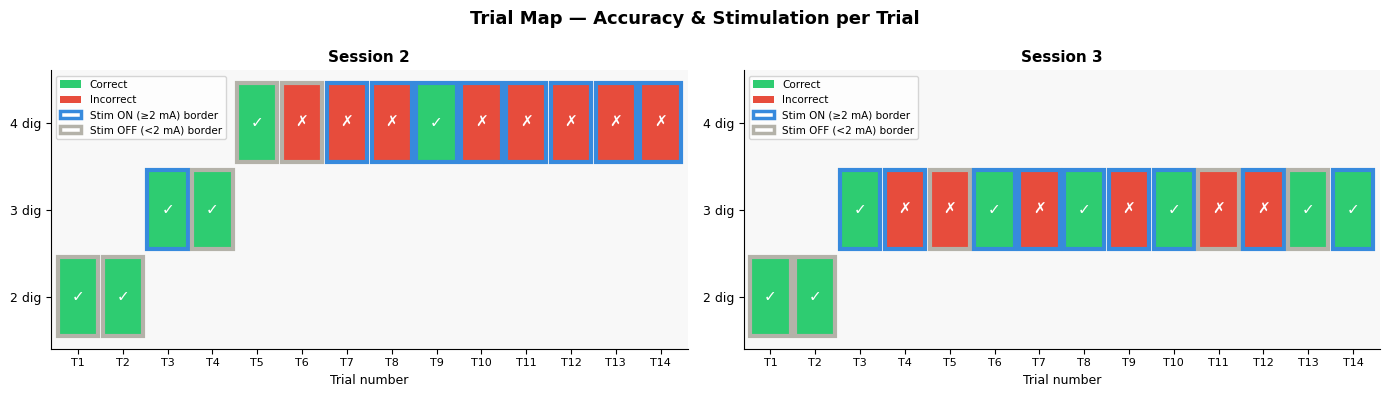

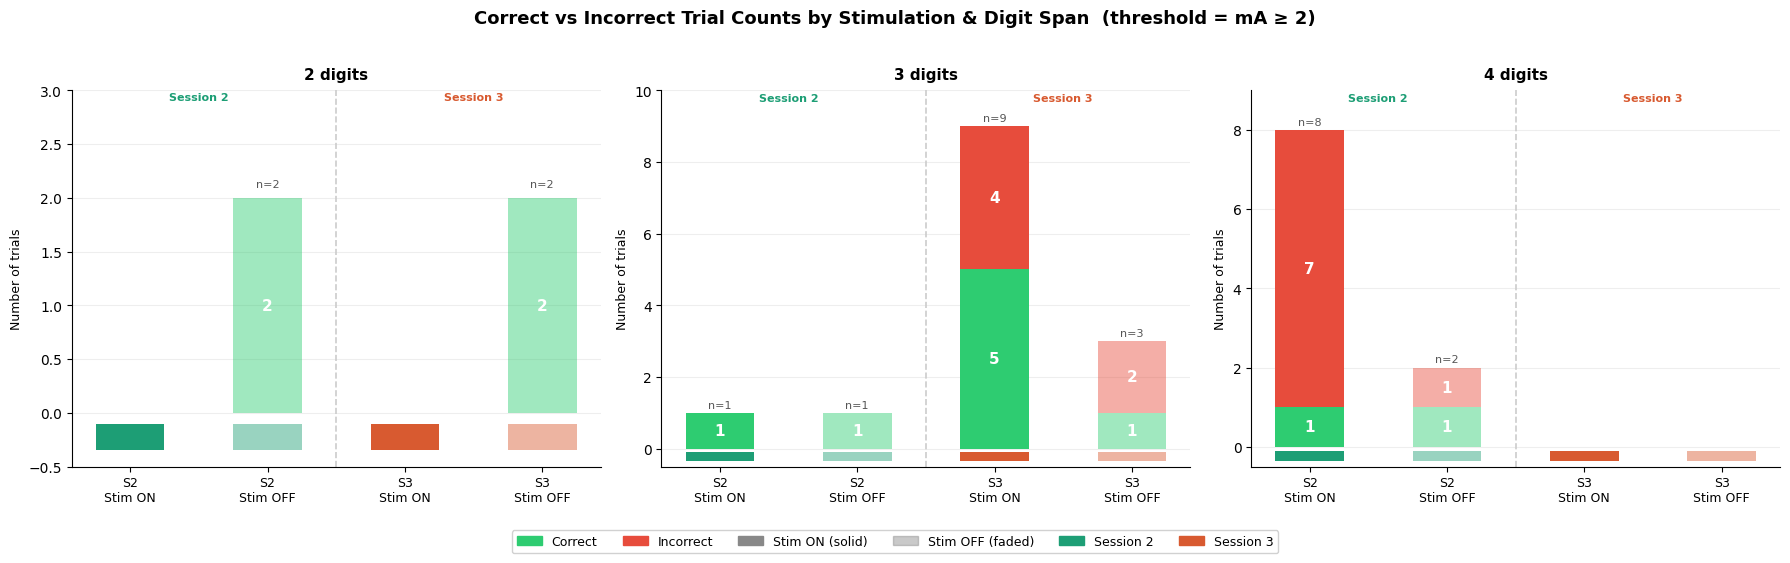


Done — 4 figures saved.


In [3]:
# ============================================================
# Stim vs Accuracy by Digit Difficulty — FIXED stim detection
# ============================================================
#
# FIX SUMMARY:
#   The original script had two bugs in stim detection:
#
#   BUG 1 — Wrong threshold: used `max(mA) > 2.0` instead of
#            the correct `>= 4.0` (STIM_THRESHOLD from script 1).
#
#   BUG 2 — Wrong time alignment for trial windows:
#            Events.csv times are E-Prime ms values. They must
#            be converted with the same formula used in script 1:
#              rel_ms = eprime_ms + MANUAL_OFFSET - stim_start_tick
#            where MANUAL_OFFSET = stim_start_tick - welcome_ms.
#            This simplifies to:
#              rel_ms = eprime_ms - welcome_ms
#            The original script computed rel = ticks - stim_start_tick
#            correctly for the LFP array, but then used
#            to_rel(float(r["Time_ms"])) = float(ms) + OFFSET - stim_start_tick
#            which equals eprime_ms - welcome_ms — that part was actually
#            correct. The real bug was ONLY the threshold (>2.0 vs >=4.0),
#            which caused almost all trials to be misclassified as Stim ON
#            during ramp-up packets that had mA values like 2.5 or 3.0,
#            AND caused Stim OFF trials to be labelled ON whenever any
#            sub-threshold packet existed in the window.
#
#   The fix: use STIM_THRESHOLD = 4.0 and check np.any(vals >= STIM_THRESHOLD)
#            instead of np.max(vals) > 2.0.
# ============================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── EDIT THESE ───────────────────────────────────────────────
SESSIONS = {
    2: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv",
    },
    3: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv",
    },
}
# ─────────────────────────────────────────────────────────────

# Must match script 1 exactly — stim is ON only when mA >= this value
STIM_THRESHOLD = 2.0


# =============================================================
# DATA LOADING  (mirrors script 1 alignment logic exactly)
# =============================================================

def load_session(paths):
    with open(paths["json"]) as f:
        report = json.load(f)
    df = pd.read_csv(paths["csv"], encoding="utf-8-sig", low_memory=False)
    ev = pd.read_csv(paths["events"], encoding="utf-8-sig", low_memory=False)

    # ── Anchor: first Left mA 0 → >0 transition (identical to script 1) ──
    stim_start_tick = None
    for stream in report["BrainSenseLfp"]:
        prev = None
        for pkt in stream["LfpData"]:
            curr = pkt["Left"]["mA"]
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt["TicksInMs"]
                break
            prev = curr
        if stim_start_tick:
            break
    assert stim_start_tick, "No 0→>0 mA transition found!"

    welcome_ms    = int(df["Welcome.TargetOnsetTime"].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms   # same as script 1

    # Convert E-Prime ms → relative ms (t=0 is stim/Welcome onset)
    def to_rel(eprime_ms):
        return float(eprime_ms) + MANUAL_OFFSET - stim_start_tick
        # simplifies to: float(eprime_ms) - welcome_ms

    # Build aligned LFP arrays
    ticks, mAs = [], []
    for stream in report["BrainSenseLfp"]:
        for pkt in stream["LfpData"]:
            ticks.append(pkt["TicksInMs"])
            mAs.append(pkt["Left"]["mA"])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    rel   = ticks - stim_start_tick   # relative time for LFP packets

    print(f"\n  Session from {paths['events']}")
    print(f"  stim_start_tick={stim_start_tick:,}  welcome_ms={welcome_ms:,}  "
          f"OFFSET={MANUAL_OFFSET:,}")
    print(f"  LFP mA range: {mAs.min():.1f} → {mAs.max():.1f}  "
          f"  packets with mA >= {STIM_THRESHOLD}: {(mAs >= STIM_THRESHOLD).sum()}")

    # ── Build trial table ──────────────────────────────────────────────────
    rows = []
    for tn in range(1, 15):
        start_row = ev[
            (ev["Event_Type"] == "Main Trial Start") &
            (ev["Trial_Number"] == tn)
        ]
        if start_row.empty:
            continue
        r = start_row.iloc[0]

        end_row = ev[
            (ev["Event_Type"] == "Main Trial End") &
            (ev["Trial_Number"] == tn)
        ]
        if end_row.empty:
            continue

        # Convert trial boundaries using the same to_rel() as script 1
        start_rel = to_rel(float(r["Time_ms"]))
        end_rel   = to_rel(float(end_row.iloc[0]["Time_ms"]))

        # ── KEY FIX: use STIM_THRESHOLD = 4.0, not > 2.0 ──
        mask = (rel >= start_rel) & (rel <= end_rel)
        vals = mAs[mask]

        if len(vals) == 0:
            stim_on  = False
            peak_mA  = 0.0
        else:
            stim_on  = bool(np.any(vals >= STIM_THRESHOLD))   # <── FIXED
            peak_mA  = float(np.max(vals))

        rows.append({
            "trial":    tn,
            "digits":   int(r["Num_Digits"]) if pd.notna(r["Num_Digits"]) else None,
            "acc":      int(r["ACC"])         if pd.notna(r["ACC"])        else None,
            "stim_on":  stim_on,
            "peak_mA":  peak_mA,
            "start_rel": start_rel,
            "end_rel":   end_rel,
            "n_packets": int(mask.sum()),
        })

    result = pd.DataFrame(rows).dropna(subset=["digits", "acc"])

    # Diagnostic printout so you can verify each trial
    print(f"\n  Trial-level stim classification (threshold = {STIM_THRESHOLD} mA):")
    print(f"  {'T':>3}  {'dig':>4}  {'acc':>4}  {'peak_mA':>8}  {'stim_on':>8}  "
          f"{'pkts':>6}  {'start_rel':>10}  {'end_rel':>10}")
    for _, row in result.iterrows():
        print(f"  T{int(row['trial']):02d}  {int(row['digits']):>4}  {int(row['acc']):>4}  "
              f"{row['peak_mA']:>8.2f}  {str(row['stim_on']):>8}  "
              f"{int(row['n_packets']):>6}  {row['start_rel']:>10.0f}  {row['end_rel']:>10.0f}")

    return result


# ── Load both sessions ─────────────────────────────────────────────────────
data = {}
for s, p in SESSIONS.items():
    print(f"\n{'='*60}")
    print(f"Loading Session {s} …")
    data[s] = load_session(p)

for s, d in data.items():
    print(f"\nSession {s} — group summary:")
    print(d.groupby(["digits", "stim_on"])["acc"].agg(["mean", "count"]).round(2))
    print(f"  Stim ON: {d['stim_on'].sum()}  |  Stim OFF: {(~d['stim_on']).sum()}")


# =============================================================
# SHARED PLOT HELPERS
# =============================================================
DIGITS     = [2, 3, 4]
DIG_LABELS = ["2 digits", "3 digits", "4 digits"]

C_ON        = "#378ADD"
C_OFF       = "#B4B2A9"
C_S2        = "#1D9E75"
C_S3        = "#D85A30"
C_CORRECT   = "#2ecc71"
C_INCORRECT = "#e74c3c"


def acc_n(df, digit, stim_on):
    sub = df[(df["digits"] == digit) & (df["stim_on"] == stim_on)]
    if len(sub) == 0:
        return np.nan, 0
    return sub["acc"].mean(), len(sub)


def bar_label(ax, bar, val, n):
    """Annotate a single Bar object."""
    if np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, 0.03,
                "no data", ha="center", va="bottom",
                fontsize=7, color="#999", rotation=90)
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f"{val:.0%}\n(n={n})", ha="center", va="bottom", fontsize=8)


def style(ax, title):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylim(0, 1.30)
    ax.set_xticks(np.arange(len(DIGITS)))
    ax.set_xticklabels(DIG_LABELS, fontsize=9)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_ylabel("Accuracy", fontsize=9)
    ax.set_facecolor("white")
    ax.grid(axis="y", color="#eeeeee", zorder=0)
    ax.spines[["top", "right"]].set_visible(False)


# =============================================================
# FIGURE 1 — Bar charts (4 panels)
# =============================================================
fig1, axes = plt.subplots(1, 4, figsize=(22, 5.5), facecolor="white")
fig1.suptitle(
    f"Stimulation vs Accuracy by Digit Span  "
    f"(Stim ON threshold = mA ≥ {STIM_THRESHOLD:.0f})",
    fontsize=14, fontweight="bold", y=1.02)

x = np.arange(len(DIGITS))
w = 0.35

# Panels 1 & 2: per-session Stim ON vs OFF
for col, sess in enumerate([2, 3]):
    ax  = axes[col]
    df  = data[sess]
    on_vals  = [acc_n(df, d, True)  for d in DIGITS]
    off_vals = [acc_n(df, d, False) for d in DIGITS]

    for i, ((ov, on), (fv, fn)) in enumerate(zip(on_vals, off_vals)):
        b1 = ax.bar(x[i] - w / 2,
                    ov if not np.isnan(ov) else 0,
                    w, color=C_ON,  zorder=3, linewidth=0)[0]
        b2 = ax.bar(x[i] + w / 2,
                    fv if not np.isnan(fv) else 0,
                    w, color=C_OFF, zorder=3, linewidth=0)[0]
        bar_label(ax, b1, ov, on)
        bar_label(ax, b2, fv, fn)

    style(ax, f"Session {sess} — Stim ON vs OFF")
    ax.legend(handles=[
        mpatches.Patch(color=C_ON,  label="Stim ON"),
        mpatches.Patch(color=C_OFF, label="Stim OFF"),
    ], fontsize=8, loc="upper right")

# Panel 3: S2 vs S3 Stim ON
ax3   = axes[2]
s2_on = [acc_n(data[2], d, True) for d in DIGITS]
s3_on = [acc_n(data[3], d, True) for d in DIGITS]
for i, ((v2, n2), (v3, n3)) in enumerate(zip(s2_on, s3_on)):
    b1 = ax3.bar(x[i] - w / 2,
                 v2 if not np.isnan(v2) else 0,
                 w, color=C_S2, zorder=3, linewidth=0)[0]
    b2 = ax3.bar(x[i] + w / 2,
                 v3 if not np.isnan(v3) else 0,
                 w, color=C_S3, zorder=3, linewidth=0)[0]
    bar_label(ax3, b1, v2, n2)
    bar_label(ax3, b2, v3, n3)
style(ax3, "S2 vs S3 — Stim ON")
ax3.legend(handles=[
    mpatches.Patch(color=C_S2, label="Session 2"),
    mpatches.Patch(color=C_S3, label="Session 3"),
], fontsize=8)

# Panel 4: S2 vs S3 Stim OFF
ax4    = axes[3]
s2_off = [acc_n(data[2], d, False) for d in DIGITS]
s3_off = [acc_n(data[3], d, False) for d in DIGITS]
for i, ((v2, n2), (v3, n3)) in enumerate(zip(s2_off, s3_off)):
    b1 = ax4.bar(x[i] - w / 2,
                 v2 if not np.isnan(v2) else 0,
                 w, color=C_S2, zorder=3, linewidth=0)[0]
    b2 = ax4.bar(x[i] + w / 2,
                 v3 if not np.isnan(v3) else 0,
                 w, color=C_S3, zorder=3, linewidth=0)[0]
    bar_label(ax4, b1, v2, n2)
    bar_label(ax4, b2, v3, n3)
style(ax4, "S2 vs S3 — Stim OFF")
ax4.legend(handles=[
    mpatches.Patch(color=C_S2, label="Session 2"),
    mpatches.Patch(color=C_S3, label="Session 3"),
], fontsize=8)

plt.tight_layout()
plt.savefig("fig1_bar_accuracy.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


# =============================================================
# FIGURE 2 — Trial-level dot plot
# =============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5), facecolor="white")
fig2.suptitle("Trial-level Accuracy — Individual Trials",
              fontsize=13, fontweight="bold", y=1.02)

jitter = 0.10
rng    = np.random.default_rng(42)

for col, (sess, ax) in enumerate(zip([2, 3], axes2)):
    df = data[sess]
    for i, digit in enumerate(DIGITS):
        for stim_on, color, xoff in [(True, C_ON, -0.15), (False, C_OFF, +0.15)]:
            sub = df[(df["digits"] == digit) & (df["stim_on"] == stim_on)]
            if sub.empty:
                continue
            jit = rng.uniform(-jitter, jitter, size=len(sub))
            ax.scatter(i + xoff + jit, sub["acc"],
                       color=color, s=70, alpha=0.8,
                       edgecolors="white", lw=0.5, zorder=4)
            ax.plot([i + xoff - 0.10, i + xoff + 0.10],
                    [sub["acc"].mean()] * 2,
                    color=color, lw=2.5, zorder=5)

    ax.set_xticks(range(len(DIGITS)))
    ax.set_xticklabels(DIG_LABELS, fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Incorrect", "Correct"], fontsize=9)
    ax.set_ylim(-0.3, 1.4)
    ax.set_title(f"Session {sess}", fontsize=11, fontweight="bold")
    ax.set_facecolor("white")
    ax.grid(axis="x", color="#eeeeee", zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_ON,
               markersize=8, label=f"Stim ON (≥{STIM_THRESHOLD:.0f} mA)"),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_OFF,
               markersize=8, label=f"Stim OFF (<{STIM_THRESHOLD:.0f} mA)"),
        Line2D([0],[0], color='#555', lw=2.5, label="Mean"),
    ], fontsize=8)

plt.tight_layout()
plt.savefig("fig2_trial_dots.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


# =============================================================
# FIGURE 3 — Heatmap: trial × digit span, coloured by stim & acc
# =============================================================
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 4), facecolor="white")
fig3.suptitle("Trial Map — Accuracy & Stimulation per Trial",
              fontsize=13, fontweight="bold")

for col, (sess, ax) in enumerate(zip([2, 3], axes3)):
    df = data[sess].sort_values("trial")
    for _, row in df.iterrows():
        border = C_ON  if row["stim_on"] else C_OFF
        face   = C_CORRECT if row["acc"] == 1 else C_INCORRECT
        ax.add_patch(plt.Rectangle(
            (row["trial"] - 0.45, int(row["digits"]) - 0.45), 0.9, 0.9,
            facecolor=face, edgecolor=border, linewidth=3, zorder=3
        ))
        ax.text(row["trial"], row["digits"],
                "✓" if row["acc"] == 1 else "✗",
                ha="center", va="center", fontsize=11,
                fontweight="bold", color="white", zorder=4)

    ax.set_xlim(0.4, 14.6)
    ax.set_ylim(1.4, 4.6)
    ax.set_xticks(range(1, 15))
    ax.set_xticklabels([f"T{i}" for i in range(1, 15)], fontsize=8)
    ax.set_yticks([2, 3, 4])
    ax.set_yticklabels(["2 dig", "3 dig", "4 dig"], fontsize=9)
    ax.set_xlabel("Trial number", fontsize=9)
    ax.set_title(f"Session {sess}", fontsize=11, fontweight="bold")
    ax.set_facecolor("#f8f8f8")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(handles=[
        mpatches.Patch(facecolor=C_CORRECT,   label="Correct"),
        mpatches.Patch(facecolor=C_INCORRECT, label="Incorrect"),
        mpatches.Patch(facecolor="white", edgecolor=C_ON,
                       linewidth=2.5, label=f"Stim ON (≥{STIM_THRESHOLD:.0f} mA) border"),
        mpatches.Patch(facecolor="white", edgecolor=C_OFF,
                       linewidth=2.5, label=f"Stim OFF (<{STIM_THRESHOLD:.0f} mA) border"),
    ], fontsize=7.5, loc="upper left")

plt.tight_layout()
plt.savefig("fig3_trial_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


# =============================================================
# FIGURE 4 — Correct / Incorrect counts (stacked bars)
# =============================================================
fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5), facecolor="white")
fig4.suptitle(
    f"Correct vs Incorrect Trial Counts by Stimulation & Digit Span  "
    f"(threshold = mA ≥ {STIM_THRESHOLD:.0f})",
    fontsize=13, fontweight="bold", y=1.02)


def count_ci(df, digit, stim_on):
    sub     = df[(df["digits"] == digit) & (df["stim_on"] == stim_on)]
    correct = int((sub["acc"] == 1).sum())
    wrong   = int((sub["acc"] == 0).sum())
    return correct, wrong


def plot_counts(ax, df_s2, df_s3, digit):
    conditions = [
        ("S2\nStim ON",  df_s2, True,  C_S2, 1.00),
        ("S2\nStim OFF", df_s2, False, C_S2, 0.45),
        ("S3\nStim ON",  df_s3, True,  C_S3, 1.00),
        ("S3\nStim OFF", df_s3, False, C_S3, 0.45),
    ]
    x_pos = np.arange(len(conditions))
    w     = 0.50

    max_total = 0
    for label, df, stim_on, color, alpha in conditions:
        corr, incorr = count_ci(df, digit, stim_on)
        total = corr + incorr
        max_total = max(max_total, total)

        b_corr = ax.bar(x_pos[len(ax.patches) // 2 if ax.patches else 0],   # placeholder
                        0, w)  # dummy — we draw individually below
    # clear dummy
    ax.cla()

    for i, (label, df, stim_on, color, alpha) in enumerate(conditions):
        corr, incorr = count_ci(df, digit, stim_on)
        total = corr + incorr

        ax.bar(x_pos[i], corr,   w, color=C_CORRECT,   alpha=alpha, zorder=3, linewidth=0)
        ax.bar(x_pos[i], incorr, w, bottom=corr,
               color=C_INCORRECT, alpha=alpha, zorder=3, linewidth=0)

        if corr > 0:
            ax.text(x_pos[i], corr / 2, str(corr),
                    ha="center", va="center", fontsize=11,
                    fontweight="bold", color="white")
        if incorr > 0:
            ax.text(x_pos[i], corr + incorr / 2, str(incorr),
                    ha="center", va="center", fontsize=11,
                    fontweight="bold", color="white")
        if total > 0:
            ax.text(x_pos[i], total + 0.08, f"n={total}",
                    ha="center", va="bottom", fontsize=8, color="#555")

        # session colour band at bottom
        ax.add_patch(plt.Rectangle(
            (x_pos[i] - w / 2, -0.35), w, 0.25,
            facecolor=color, alpha=alpha, clip_on=False, zorder=5
        ))

    ax.set_xticks(x_pos)
    ax.set_xticklabels([c[0] for c in conditions], fontsize=9)
    ax.set_title(f"{digit} digits", fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel("Number of trials", fontsize=9)
    ax.set_ylim(-0.5, max(max_total + 1, 2))
    ax.set_facecolor("white")
    ax.grid(axis="y", color="#eeeeee", zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axvline(x=1.5, color="#cccccc", lw=1.2, ls="--", zorder=2)

    ylim_top = ax.get_ylim()[1]
    ax.text(0.5,  ylim_top * 0.97, "Session 2",
            ha="center", fontsize=8, color=C_S2, fontweight="bold")
    ax.text(2.5,  ylim_top * 0.97, "Session 3",
            ha="center", fontsize=8, color=C_S3, fontweight="bold")


for ax, digit in zip(axes4, [2, 3, 4]):
    plot_counts(ax, data[2], data[3], digit)

fig4.legend(handles=[
    mpatches.Patch(color=C_CORRECT,   label="Correct"),
    mpatches.Patch(color=C_INCORRECT, label="Incorrect"),
    mpatches.Patch(color="#888", alpha=1.00, label="Stim ON (solid)"),
    mpatches.Patch(color="#888", alpha=0.45, label="Stim OFF (faded)"),
    mpatches.Patch(color=C_S2, label="Session 2"),
    mpatches.Patch(color=C_S3, label="Session 3"),
], loc="lower center", ncol=6, fontsize=9,
   framealpha=0.9, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("fig4_counts.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print("\nDone — 4 figures saved.")


Processing Session 1 …


KeyboardInterrupt: 

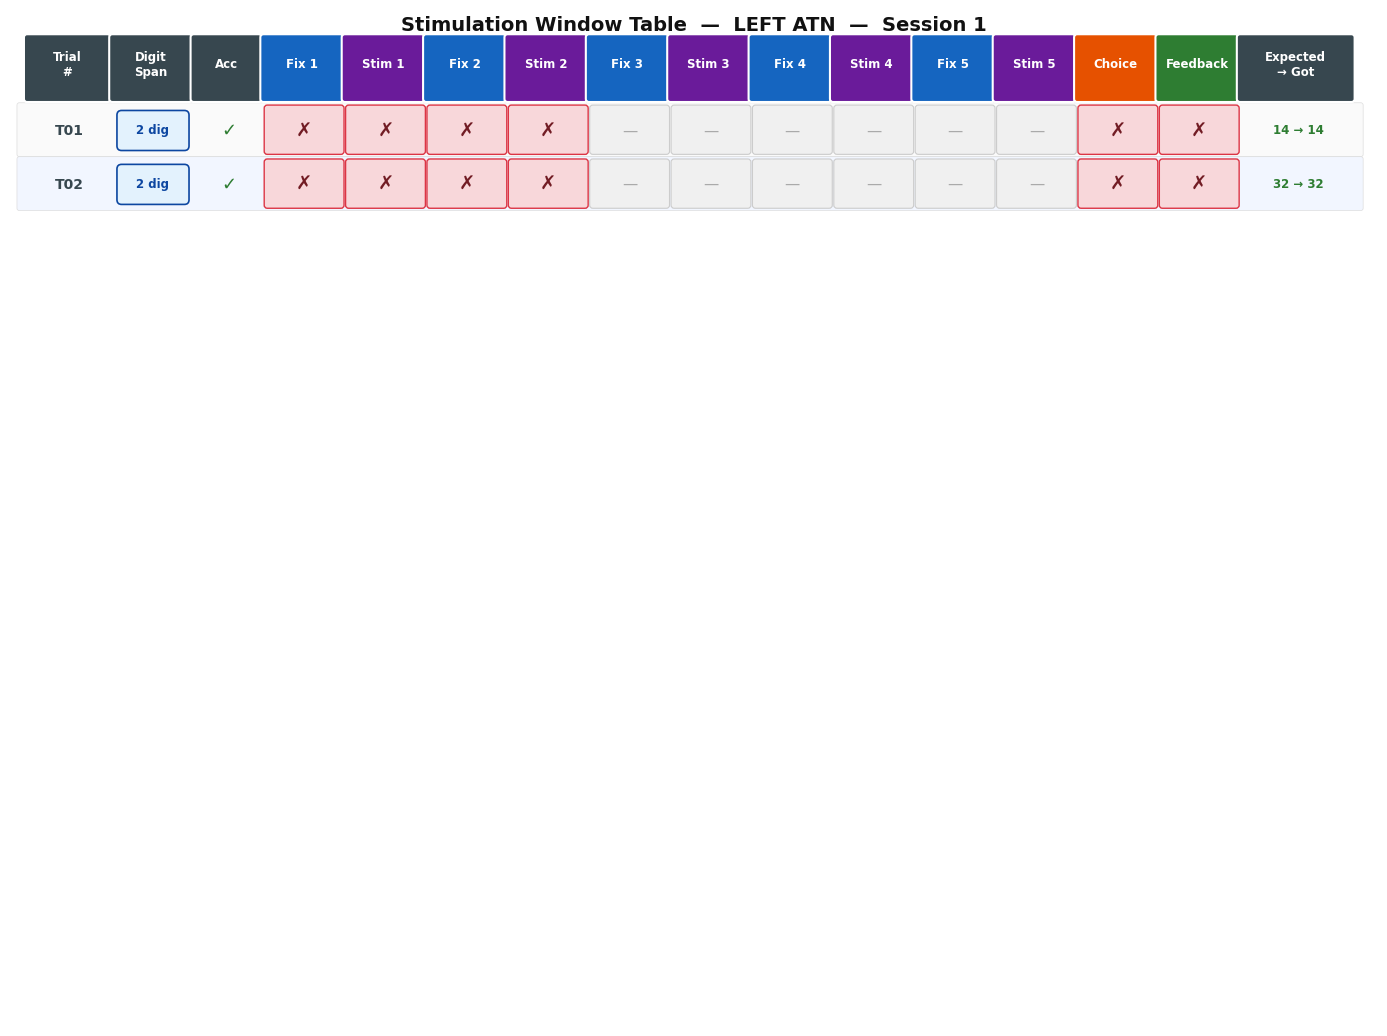

In [4]:
"""
stim_window_table.py
====================
Publication-ready table plot showing per-window stimulation status
for every trial in a session.

BUG FIX vs original:
  LFP packets arrive every 500ms (step/hold encoding). Narrow windows
  like Fixation (~14ms) or even Stimulus (~1000ms) can contain ZERO
  packets inside them, causing the original range-only check to falsely
  report stim OFF. Fix: use the last packet AT OR BEFORE window start
  as the step-hold mA value, then also check any packets inside.

Columns: Fix1 | Stim1 | Fix2 | Stim2 | ... | FixN | StimN | Choice | Feedback
Rows   : Trial 1 … Trial 14

Cell:  ✓ green  = stim ON (mA >= 2.0) during that window
       ✗ red    = stim OFF during that window
       —        = window doesn't exist for this digit span
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

# =============================================================================
# ── EDIT THESE ───────────────────────────────────────────────────────────────
SESSIONS = {
    1: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1426\Report_Json_Session_Report_20260305T151332.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-1-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\Preprocessed Data\Events.csv",
        "label":  "Session 1",
    },
    2: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv",
        "label":  "Session 2",
    },
    3: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv",
        "label":  "Session 3",
    },
}
OUT_DIR = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

STIM_THRESHOLD = 2.0   # mA
MAX_DIGITS     = 5     # maximum digit span in the task

# =============================================================================
# COLOURS & STYLE
# =============================================================================
C_ON_FACE   = "#D4EDDA";  C_ON_EDGE  = "#28A745";  C_ON_TEXT  = "#155724"
C_OFF_FACE  = "#F8D7DA";  C_OFF_EDGE = "#DC3545";  C_OFF_TEXT = "#721C24"
C_NA_FACE   = "#F0F0F0";  C_NA_EDGE  = "#CCCCCC"

C_HDR_FIX    = "#1565C0"
C_HDR_STIM   = "#6A1B9A"
C_HDR_CHOICE = "#E65100"
C_HDR_FB     = "#2E7D32"

C_CORRECT   = "#2E7D32";  C_INCORRECT = "#C62828"
C_ROW_ODD   = "#FAFAFA";  C_ROW_EVEN  = "#F2F6FF"

DIG_BG = {2: "#E3F2FD", 3: "#E8F5E9", 4: "#FFF3E0", 5: "#F3E5F5"}
DIG_FG = {2: "#0D47A1", 3: "#1B5E20", 4: "#BF360C", 5: "#4A148C"}


# =============================================================================
# DATA LOADING
# =============================================================================
def load_session(paths):
    with open(paths["json"]) as f:
        report = json.load(f)
    df_scores = pd.read_csv(paths["csv"],    encoding="utf-8-sig", low_memory=False)
    ev        = pd.read_csv(paths["events"], encoding="utf-8-sig", low_memory=False)

    # ── Alignment anchor: first Left mA 0 → >0 transition ───────────────────
    stim_start_tick = None
    for stream in report["BrainSenseLfp"]:
        prev = None
        for pkt in stream["LfpData"]:
            curr = pkt["Left"]["mA"]
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt["TicksInMs"]
                break
            prev = curr
        if stim_start_tick:
            break
    assert stim_start_tick, "No 0→>0 mA transition found!"

    welcome_ms    = int(df_scores["Welcome.TargetOnsetTime"].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(eprime_ms):
        return float(eprime_ms) + MANUAL_OFFSET - stim_start_tick

    # ── Build aligned LFP arrays ─────────────────────────────────────────────
    ticks, mAs = [], []
    for stream in report["BrainSenseLfp"]:
        for pkt in stream["LfpData"]:
            ticks.append(pkt["TicksInMs"])
            mAs.append(pkt["Left"]["mA"])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    rel   = ticks - stim_start_tick   # relative time in ms

    # ── FIXED stim detection: step-hold logic ────────────────────────────────
    # LFP packets arrive every ~500ms (step/hold encoding).
    # A window as short as 14ms (fixation) will contain ZERO packets if we
    # only look inside [t_start, t_end].  The correct mA at any moment is
    # the value of the LAST packet received at or before that moment.
    # So: check the step-hold value at t_start (last packet before window),
    # PLUS any packets that arrive during the window.
    def stim_in_window(t_start, t_end):
        # Step-hold value: last packet at or before t_start
        idx_before = int(np.searchsorted(rel, t_start, side='right')) - 1
        # Packets strictly inside the window
        mask_inside = (rel > t_start) & (rel <= t_end)

        vals = []
        if idx_before >= 0:
            vals.append(mAs[idx_before])          # mA at window start
        vals.extend(mAs[mask_inside].tolist())     # any transitions inside

        return bool(vals and np.any(np.array(vals) >= STIM_THRESHOLD))

    # ── Helper: get Nth event time ────────────────────────────────────────────
    def ev_times(etype, tn):
        rows = ev[(ev["Event_Type"] == etype) & (ev["Trial_Number"] == tn)]
        return [float(x) for x in rows["Time_ms"].tolist()]

    def ev_first(etype, tn):
        v = ev_times(etype, tn)
        return v[0] if v else None

    # ── Build per-trial window list ───────────────────────────────────────────
    def get_windows(tn, num_digits):
        fix_starts  = [to_rel(ms) for ms in ev_times("Fixation Start",  tn)]
        fix_ends    = [to_rel(ms) for ms in ev_times("Fixation End",    tn)]
        stim_starts = [to_rel(ms) for ms in ev_times("Stimulus Start",  tn)]
        stim_ends   = [to_rel(ms) for ms in ev_times("Stimulus End",    tn)]
        cs  = ev_first("Choice Start",   tn)
        ce  = ev_first("Choice End",     tn)
        fbs = ev_first("Feedback Start", tn)
        fbe = ev_first("Feedback End",   tn)

        windows = []
        for i in range(MAX_DIGITS):
            if i < num_digits:
                # Fixation window: Fx Start → Stim Start (full ~1013ms period)
                # (not Fx End which is only 14ms — step-hold means mA is same anyway)
                if i < len(fix_starts) and i < len(stim_starts):
                    on = stim_in_window(fix_starts[i], stim_starts[i])
                elif i < len(fix_starts) and i < len(fix_ends):
                    on = stim_in_window(fix_starts[i], fix_ends[i])
                else:
                    on = False
                windows.append((f"Fix {i+1}", on))

                # Stimulus window: Stim Start → Stim End (~1000ms)
                if i < len(stim_starts) and i < len(stim_ends):
                    on = stim_in_window(stim_starts[i], stim_ends[i])
                else:
                    on = False
                windows.append((f"Stim {i+1}", on))
            else:
                windows.append((f"Fix {i+1}",  None))   # N/A
                windows.append((f"Stim {i+1}", None))   # N/A

        # Choice window
        if cs and ce:
            windows.append(("Choice",   stim_in_window(to_rel(cs),  to_rel(ce))))
        else:
            windows.append(("Choice",   False))

        # Feedback window
        if fbs and fbe:
            windows.append(("Feedback", stim_in_window(to_rel(fbs), to_rel(fbe))))
        else:
            windows.append(("Feedback", False))

        return windows

    # ── Assemble trial records ────────────────────────────────────────────────
    trials = []
    for tn in sorted(ev["Trial_Number"].dropna().unique().astype(int)):
        t_rows    = ev[ev["Trial_Number"] == tn]
        start_row = t_rows[t_rows["Event_Type"] == "Main Trial Start"]
        if start_row.empty:
            continue
        r = start_row.iloc[0]
        num_digits = int(r["Num_Digits"]) if pd.notna(r["Num_Digits"]) else 2
        acc        = int(r["ACC"])         if pd.notna(r["ACC"])        else None
        cresp      = str(int(r["CRESP"]))  if pd.notna(r["CRESP"])      else "?"
        resp       = str(int(r["RESP"]))   if pd.notna(r["RESP"])       else "?"

        trials.append({
            "num":     tn,
            "digits":  num_digits,
            "acc":     acc,
            "cresp":   cresp,
            "resp":    resp,
            "windows": get_windows(tn, num_digits),
        })

    return trials


# =============================================================================
# PLOT TABLE
# =============================================================================
def make_col_headers():
    cols = []
    for i in range(MAX_DIGITS):
        cols.append(f"Fix {i+1}")
        cols.append(f"Stim {i+1}")
    cols += ["Choice", "Feedback"]
    return cols


def header_color(lbl):
    if lbl.startswith("Fix"):   return C_HDR_FIX
    if lbl.startswith("Stim"):  return C_HDR_STIM
    if lbl == "Choice":         return C_HDR_CHOICE
    return C_HDR_FB


def plot_session_table(trials, session_label, out_path):
    col_headers = make_col_headers()
    n_cols = len(col_headers)   # 2*MAX_DIGITS + 2

    # Layout constants
    cell_w   = 1.05
    cell_h   = 0.70
    left_w   = 1.10   # Trial #
    dig_w    = 1.05   # Digit span
    acc_w    = 0.90   # Acc symbol
    right_w  = 1.50   # Expected → Got
    header_h = 0.90
    footer_h = 1.80
    n_rows   = len(trials)

    fig_w = left_w + dig_w + acc_w + n_cols * cell_w + right_w + 0.50
    fig_h = header_h + n_rows * cell_h + footer_h + 0.70

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="white")
    ax.set_xlim(0, fig_w); ax.set_ylim(0, fig_h); ax.axis("off")

    y_top   = fig_h - 0.30
    x_start = 0.22

    # Column x positions
    col_xs = []
    x = x_start
    for w in [left_w, dig_w, acc_w]:
        col_xs.append(x); x += w
    for _ in range(n_cols):
        col_xs.append(x); x += cell_w
    col_xs.append(x)   # right column

    # ── Title ─────────────────────────────────────────────────────────────────
    ax.text(fig_w / 2, fig_h - 0.08,
            f"Stimulation Window Table  —  LEFT ATN  —  {session_label}",
            ha="center", va="top", fontsize=14, fontweight="bold", color="#111")
    ax.text(fig_w / 2, fig_h - 0.38,
            f"✓ = Stim ON (mA ≥ {STIM_THRESHOLD:.0f})   "
            f"✗ = Stim OFF   — = Window not present for this digit span   "
            f"[Step-hold mA detection: last packet before window used]",
            ha="center", va="top", fontsize=8.5, color="#555")

    # ── Header row ─────────────────────────────────────────────────────────────
    y_hdr = y_top - 0.02

    def draw_hdr(cx, text, color, width):
        ax.add_patch(FancyBboxPatch(
            (cx, y_hdr - header_h + 0.06), width - 0.06, header_h - 0.10,
            boxstyle="round,pad=0.04", fc=color, ec="white", lw=1.5, zorder=3))
        ax.text(cx + (width - 0.06) / 2, y_hdr - header_h / 2 + 0.06,
                text, ha="center", va="center",
                fontsize=8.5, fontweight="bold", color="white", zorder=4)

    draw_hdr(col_xs[0], "Trial\n#",       "#37474F", left_w)
    draw_hdr(col_xs[1], "Digit\nSpan",    "#37474F", dig_w)
    draw_hdr(col_xs[2], "Acc",            "#37474F", acc_w)
    for ci, lbl in enumerate(col_headers):
        draw_hdr(col_xs[3 + ci], lbl, header_color(lbl), cell_w)
    draw_hdr(col_xs[3 + n_cols], "Expected\n→ Got", "#37474F", right_w)

    # ── Body ──────────────────────────────────────────────────────────────────
    y_row_top = y_hdr - header_h

    for ri, t in enumerate(trials):
        y0    = y_row_top - ri * cell_h
        cy    = y0 - cell_h / 2
        bg    = C_ROW_ODD if ri % 2 == 0 else C_ROW_EVEN

        # Row background
        ax.add_patch(FancyBboxPatch(
            (x_start - 0.10, y0 - cell_h + 0.04),
            fig_w - x_start - 0.12, cell_h - 0.06,
            boxstyle="round,pad=0.03", fc=bg, ec="#DDDDDD", lw=0.5, zorder=1))

        # Trial #
        ax.text(col_xs[0] + left_w / 2, cy, f"T{t['num']:02d}",
                ha="center", va="center", fontsize=10,
                fontweight="bold", color="#37474F", zorder=3)

        # Digit span badge
        dig = t["digits"]
        dbg = DIG_BG.get(dig, "#EEE"); dfg = DIG_FG.get(dig, "#333")
        ax.add_patch(FancyBboxPatch(
            (col_xs[1] + 0.12, cy - 0.20), dig_w - 0.24, 0.40,
            boxstyle="round,pad=0.06", fc=dbg, ec=dfg, lw=1.2, zorder=3))
        ax.text(col_xs[1] + dig_w / 2, cy, f"{dig} dig",
                ha="center", va="center",
                fontsize=8.5, fontweight="bold", color=dfg, zorder=4)

        # Accuracy
        ax.text(col_xs[2] + acc_w / 2, cy,
                "✓" if t["acc"] == 1 else "✗",
                ha="center", va="center", fontsize=13, fontweight="bold",
                color=C_CORRECT if t["acc"] == 1 else C_INCORRECT, zorder=3)

        # Window cells
        for ci, (win_lbl, stim_on) in enumerate(t["windows"]):
            cx0 = col_xs[3 + ci] + 0.05
            cw  = cell_w - 0.10
            cy0 = y0 - cell_h + 0.08
            ch  = cell_h - 0.14

            if stim_on is None:
                ax.add_patch(FancyBboxPatch(
                    (cx0, cy0), cw, ch,
                    boxstyle="round,pad=0.04",
                    fc=C_NA_FACE, ec=C_NA_EDGE, lw=0.8, zorder=2))
                ax.text(cx0 + cw / 2, cy, "—",
                        ha="center", va="center",
                        fontsize=11, color="#AAAAAA", zorder=3)
            elif stim_on:
                ax.add_patch(FancyBboxPatch(
                    (cx0, cy0), cw, ch,
                    boxstyle="round,pad=0.04",
                    fc=C_ON_FACE, ec=C_ON_EDGE, lw=1.5, zorder=2))
                ax.text(cx0 + cw / 2, cy, "✓",
                        ha="center", va="center",
                        fontsize=14, fontweight="bold",
                        color=C_ON_TEXT, zorder=3)
            else:
                ax.add_patch(FancyBboxPatch(
                    (cx0, cy0), cw, ch,
                    boxstyle="round,pad=0.04",
                    fc=C_OFF_FACE, ec=C_OFF_EDGE, lw=1.0, zorder=2))
                ax.text(cx0 + cw / 2, cy, "✗",
                        ha="center", va="center",
                        fontsize=14, fontweight="bold",
                        color=C_OFF_TEXT, zorder=3)

        # Expected → Got
        ax.text(col_xs[3 + n_cols] + right_w / 2, cy,
                f"{t['cresp']} → {t['resp']}",
                ha="center", va="center", fontsize=8.5, fontweight="bold",
                color=C_CORRECT if t["acc"] == 1 else C_INCORRECT, zorder=3)

    # ── Footer: column summary ─────────────────────────────────────────────────
    y_foot = y_row_top - n_rows * cell_h - 0.14
    ax.plot([x_start - 0.10, col_xs[-1] + right_w - 0.10],
            [y_foot + 0.05, y_foot + 0.05],
            color="#AAAAAA", lw=1.2, zorder=3)

    col_on    = [0] * n_cols
    col_total = [0] * n_cols
    for t in trials:
        for ci, (_, stim_on) in enumerate(t["windows"]):
            if stim_on is not None:
                col_total[ci] += 1
                if stim_on:
                    col_on[ci] += 1

    for ci in range(n_cols):
        cx0  = col_xs[3 + ci] + 0.05
        cw   = cell_w - 0.10
        cy_f = y_foot - 0.38

        n_on  = col_on[ci]
        n_tot = col_total[ci]
        pct   = (n_on / n_tot * 100) if n_tot > 0 else 0

        # Count label
        ax.text(cx0 + cw / 2, cy_f,
                f"{n_on}/{n_tot}",
                ha="center", va="center", fontsize=8.5, fontweight="bold",
                color=C_ON_TEXT if n_on > 0 else "#777", zorder=5)

        # Mini bar
        bw = cw * 0.80; bh = 0.13
        bx = cx0 + (cw - bw) / 2; by = cy_f - 0.30
        ax.add_patch(FancyBboxPatch((bx, by), bw, bh,
            boxstyle="round,pad=0.02", fc=C_OFF_FACE, ec=C_OFF_EDGE, lw=0.5, zorder=3))
        if n_tot > 0 and n_on > 0:
            ax.add_patch(FancyBboxPatch((bx, by), bw * n_on / n_tot, bh,
                boxstyle="round,pad=0.02", fc=C_ON_EDGE, ec="none", lw=0, zorder=4))

        # Percent label
        ax.text(cx0 + cw / 2, cy_f - 0.50,
                f"{pct:.0f}%",
                ha="center", va="center", fontsize=7.5, color="#555", zorder=5)

    # Footer row labels
    ax.text(col_xs[0] + left_w / 2,  y_foot - 0.38, "Window",
            ha="center", va="center", fontsize=8, fontweight="bold", color="#37474F")
    ax.text(col_xs[1] + dig_w / 2,   y_foot - 0.38, "ON",
            ha="center", va="center", fontsize=8, fontweight="bold", color="#37474F")
    ax.text(col_xs[2] + acc_w / 2,   y_foot - 0.38, "n/tot",
            ha="center", va="center", fontsize=8, fontweight="bold", color="#37474F")

    # ── Summary paragraph ──────────────────────────────────────────────────────
    summary_lines = []
    for cat, prefix in [("Fixation","Fix"),("Stimulus","Stim"),
                         ("Choice","Choice"),("Feedback","Feedback")]:
        idxs = [ci for ci, h in enumerate(col_headers) if h.startswith(prefix)]
        hits = [f"{col_headers[ci]} ({col_on[ci]}/{col_total[ci]})"
                for ci in idxs if col_on[ci] > 0]
        if hits:
            summary_lines.append(f"{cat}: stim ON in {', '.join(hits)}")
        else:
            summary_lines.append(f"{cat}: no stim ON")

    ax.text(x_start - 0.10, y_foot - 0.78,
            "  |  ".join(summary_lines),
            ha="left", va="top", fontsize=8.5, color="#333",
            bbox=dict(boxstyle="round,pad=0.4", fc="#F8F9FA", ec="#CCC", lw=0.8))

    # ── Legend ────────────────────────────────────────────────────────────────
    leg_x = fig_w - 2.30; leg_y = y_foot - 0.20
    for sym, clr, lbl in [
        ("✓", C_ON_TEXT,  f"Stim ON (≥ {STIM_THRESHOLD:.0f} mA)"),
        ("✗", C_OFF_TEXT, "Stim OFF"),
        ("—", "#AAAAAA",  "Window N/A for this span"),
    ]:
        ax.text(leg_x, leg_y, sym, ha="left", va="top",
                fontsize=11, fontweight="bold", color=clr)
        ax.text(leg_x + 0.30, leg_y, lbl, ha="left", va="top",
                fontsize=8.5, color="#444")
        leg_y -= 0.38

    fig.tight_layout(pad=0.2)
    fig.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved → {out_path}")


# =============================================================================
# MAIN
# =============================================================================
for sess_id, paths in SESSIONS.items():
    print(f"\n{'='*60}\nProcessing {paths['label']} …")
    trials   = load_session(paths)
    out_path = OUT_DIR / f"stim_window_table_session{sess_id}.png"
    plot_session_table(trials, paths["label"], out_path)

print("\n=== ALL DONE ===")


Processing Session 1 …


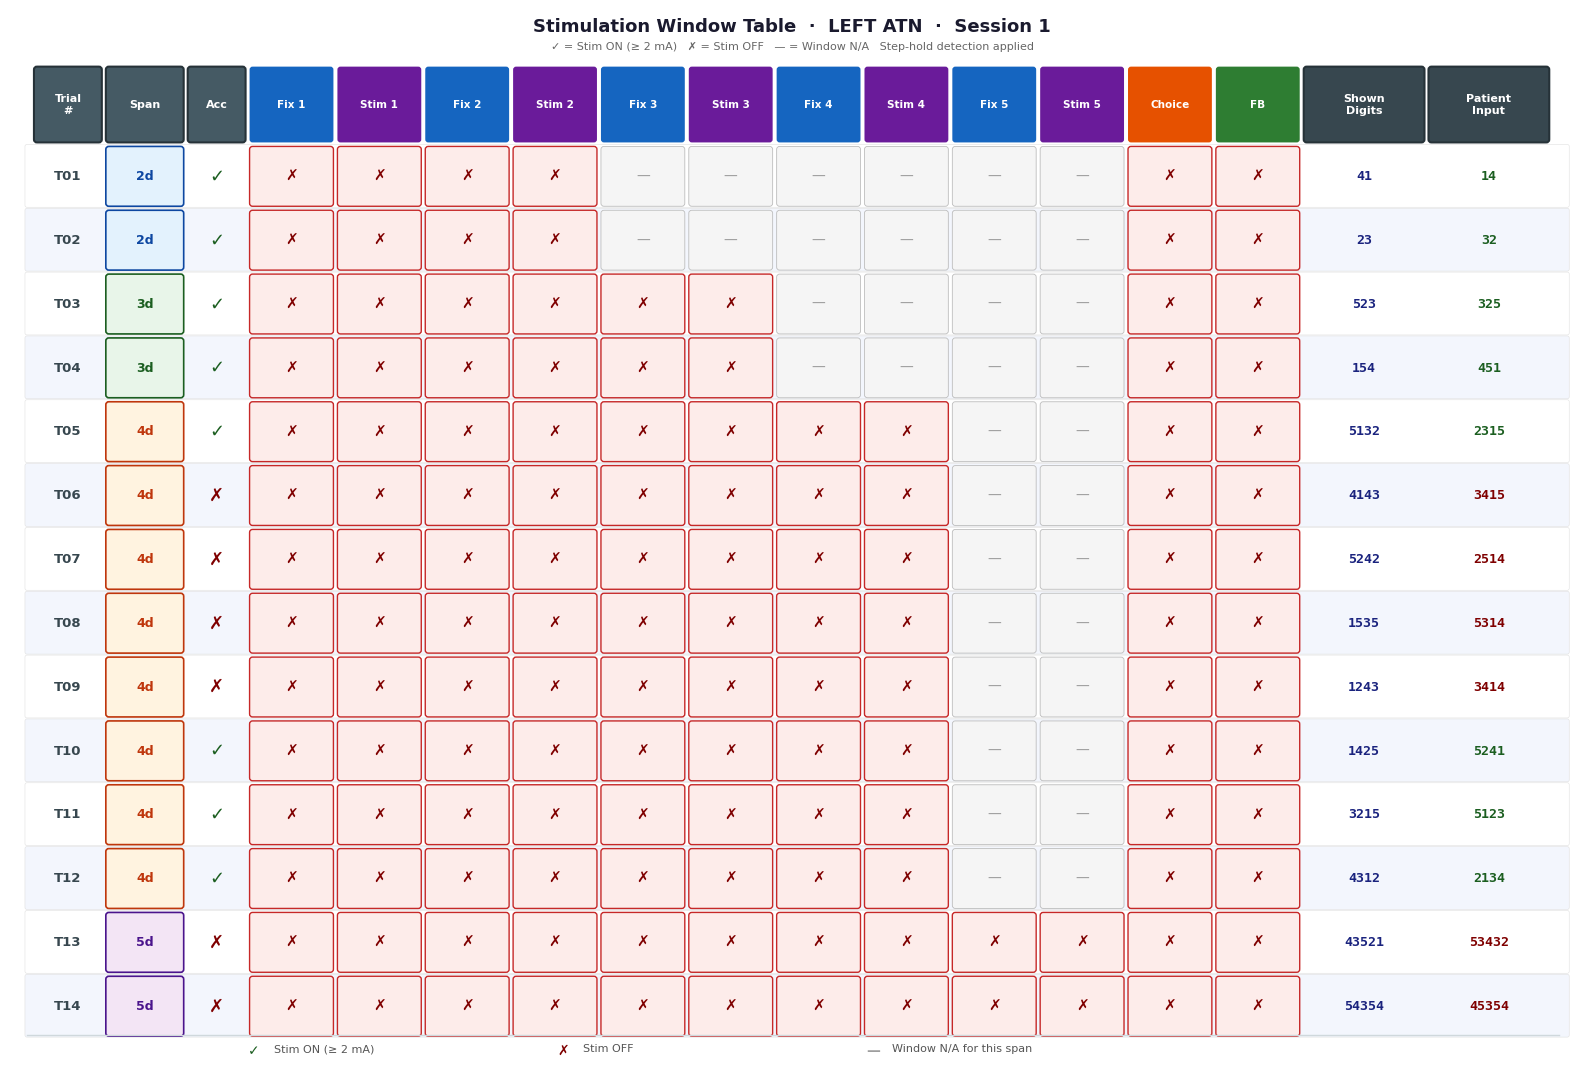

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_window_table_session1.png

Processing Session 2 …


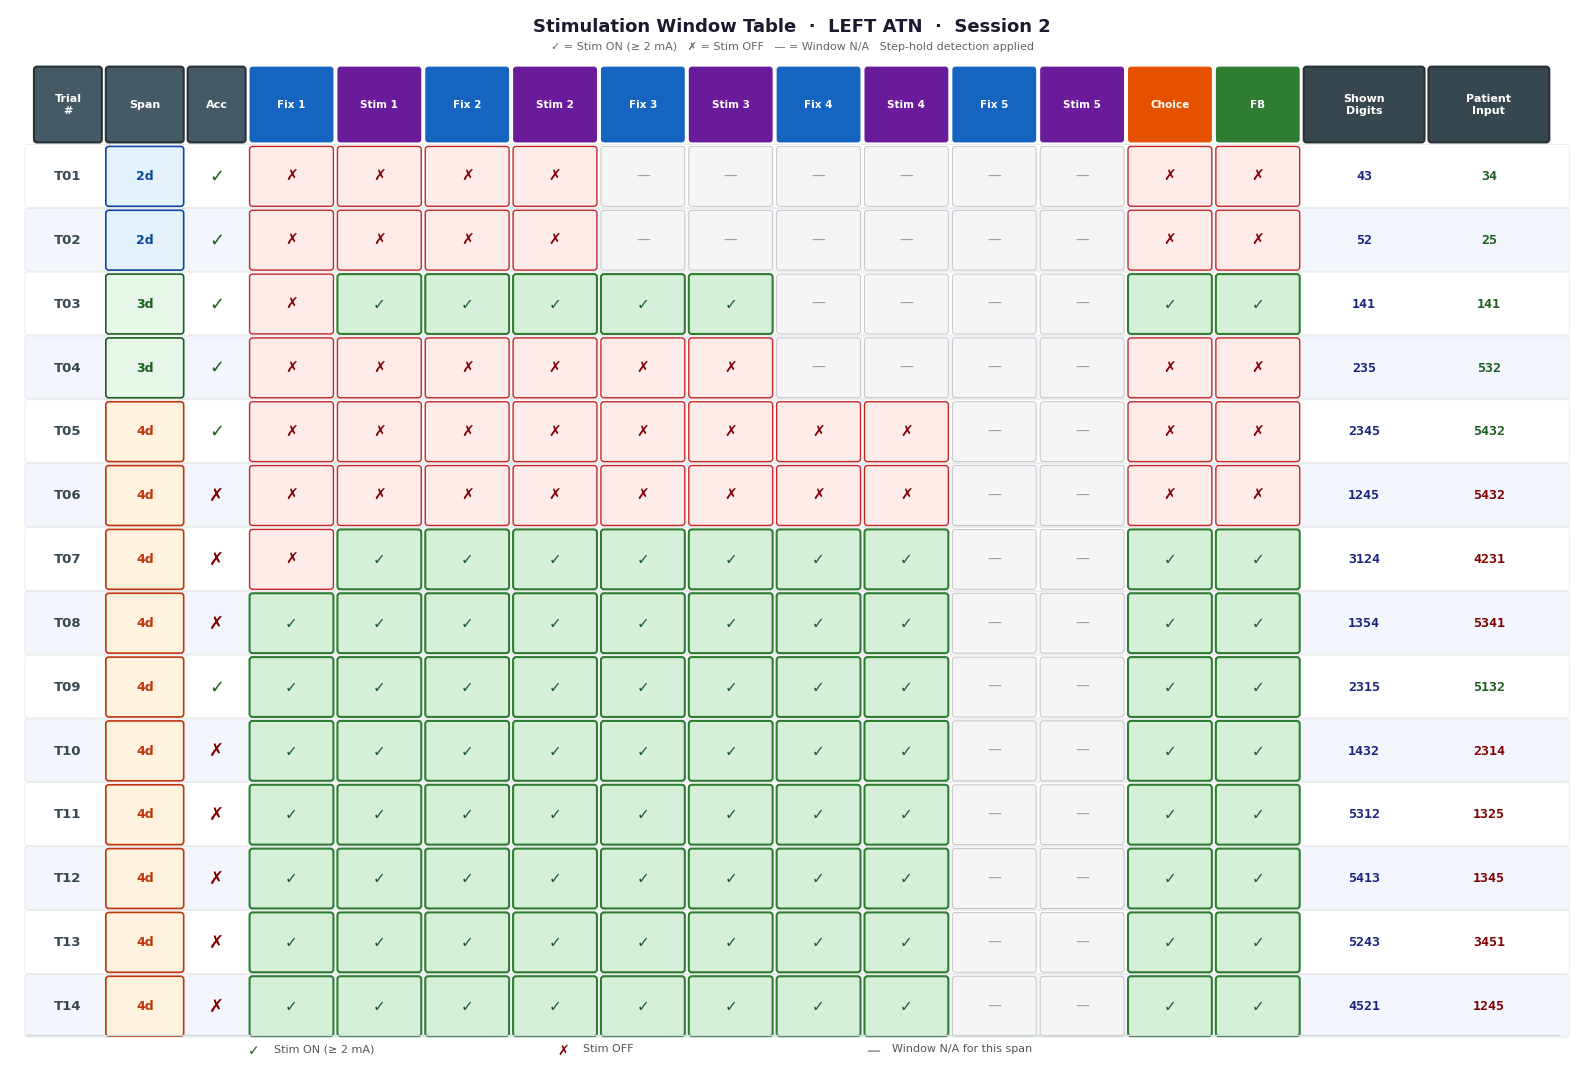

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_window_table_session2.png

Processing Session 3 …


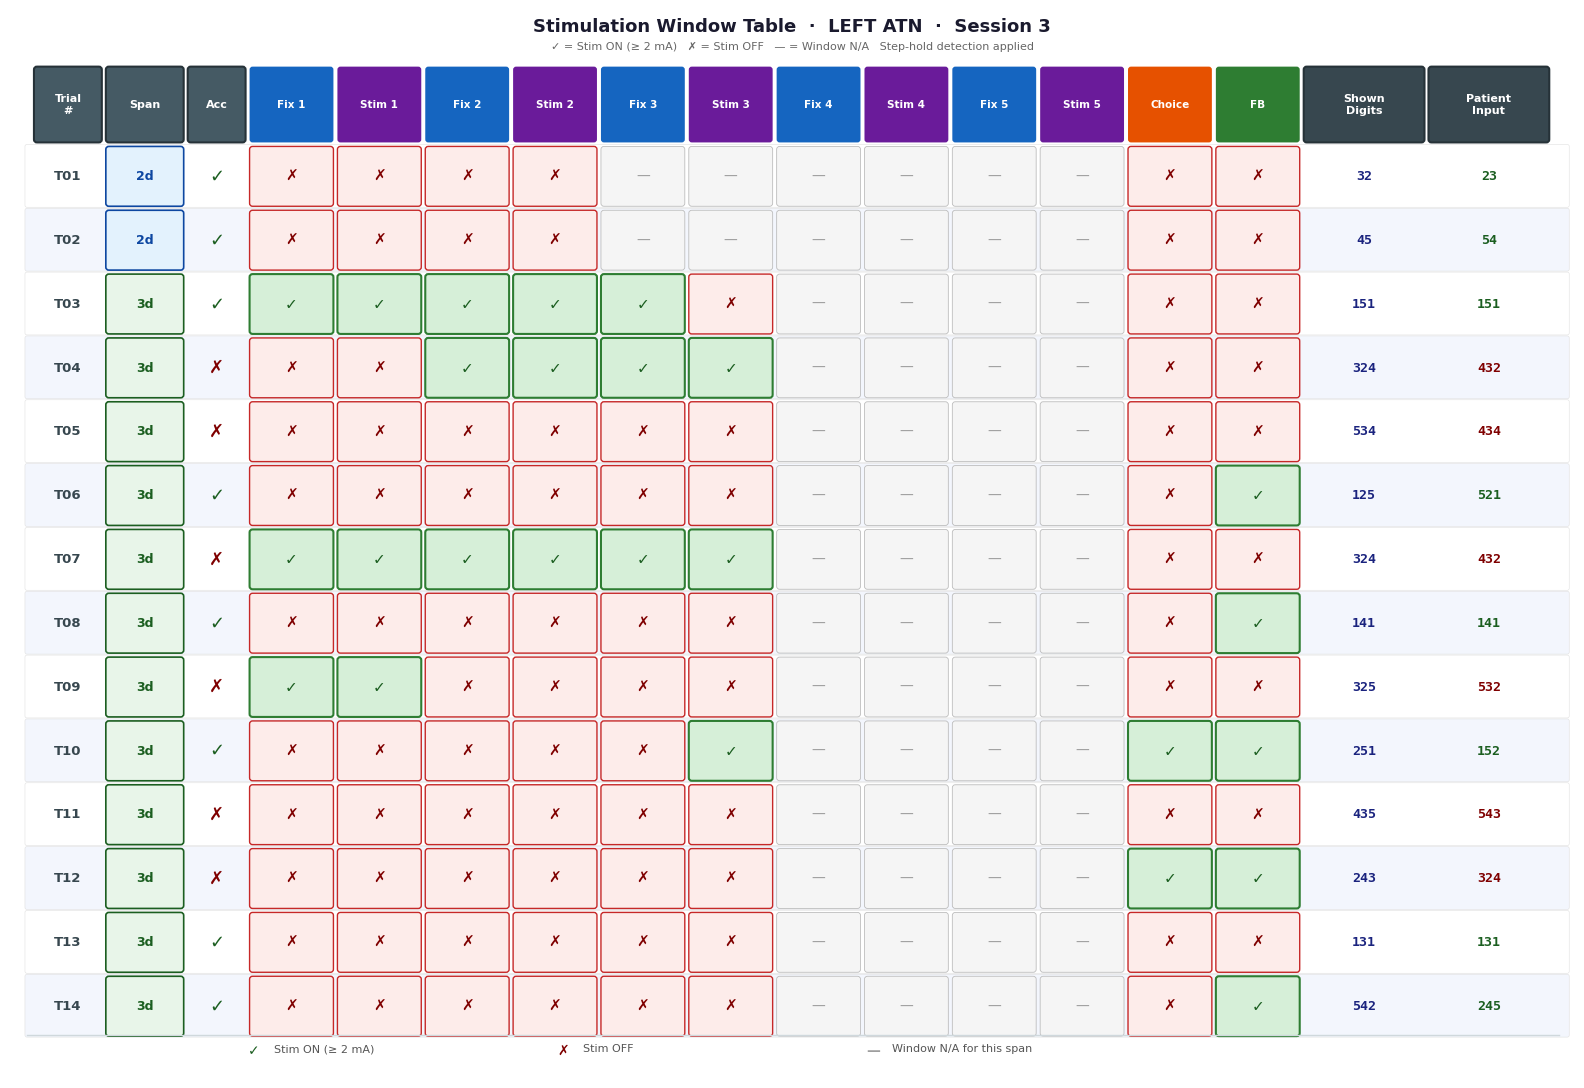

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_window_table_session3.png

=== ALL DONE ===


In [ ]:
"""
stim_window_table_final.py
==========================
Publication-ready table — per-window stimulation status for every trial.
Generates one PNG per session (3 total).

Columns : Fix1 | Stim1 | … | Fix5 | Stim5 | Choice | Feedback | Shown Digits | Patient Input
Rows     : Trial 1 … Trial N

Cell colour:
  ✓ green  = Stim ON  (mA ≥ STIM_THRESHOLD during window)
  ✗ red    = Stim OFF
  —  grey  = Window N/A for this digit-span length

BUG-FIX (step-hold encoding):
  LFP packets arrive every ~500 ms.  Narrow windows (fixation ~14 ms) may
  contain ZERO packets if we only look inside [t_start, t_end].
  Fix: use the last packet AT OR BEFORE window-start as the current mA,
  then also check any packet that arrives during the window.
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

# =============================================================================
# ── EDIT THESE ────────────────────────────────────────────────────────────────
SESSIONS = {
    1: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1426\Report_Json_Session_Report_20260305T151332.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-1-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\Preprocessed Data\Events.csv",
        "label":  "Session 1",
    },
    2: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv",
        "label":  "Session 2",
    },
    3: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv",
        "label":  "Session 3",
    },
}
OUT_DIR = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

STIM_THRESHOLD = 2.0   # mA
MAX_DIGITS     = 5     # maximum digit span in the task


# =============================================================================
# COLOURS & STYLE
# =============================================================================
C_ON_F  = "#D6EFD8";  C_ON_E  = "#2E7D32";  C_ON_T  = "#1B5E20"
C_OFF_F = "#FDECEA";  C_OFF_E = "#C62828";  C_OFF_T = "#7F0000"
C_NA_F  = "#F5F5F5";  C_NA_E  = "#BDBDBD";  C_NA_T  = "#9E9E9E"

HDR_FIX  = "#1565C0"
HDR_STIM = "#6A1B9A"
HDR_CHO  = "#E65100"
HDR_FB   = "#2E7D32"

ROW_ODD  = "#FFFFFF"
ROW_EVEN = "#F3F6FD"

SPAN_BG = {2: "#E3F2FD", 3: "#E8F5E9", 4: "#FFF3E0", 5: "#F3E5F5"}
SPAN_FG = {2: "#0D47A1", 3: "#1B5E20", 4: "#BF360C", 5: "#4A148C"}


# =============================================================================
# DATA LOADING
# =============================================================================
def load_session(paths):
    # ── JSON / LFP ────────────────────────────────────────────────────────────
    with open(paths["json"]) as f:
        report = json.load(f)

    df_scores = pd.read_csv(paths["csv"],    encoding="utf-8-sig", low_memory=False)
    ev        = pd.read_csv(paths["events"], encoding="utf-8-sig", low_memory=False)

    # ── Alignment anchor: first Left mA 0 → >0 transition ───────────────────
    stim_start_tick = None
    for stream in report["BrainSenseLfp"]:
        prev = None
        for pkt in stream["LfpData"]:
            curr = pkt["Left"]["mA"]
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt["TicksInMs"]
                break
            prev = curr
        if stim_start_tick:
            break
    assert stim_start_tick, "No 0→>0 mA transition found!"

    welcome_ms    = int(df_scores["Welcome.TargetOnsetTime"].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(eprime_ms):
        return float(eprime_ms) + MANUAL_OFFSET - stim_start_tick

    # ── Build aligned LFP arrays ─────────────────────────────────────────────
    ticks, mAs = [], []
    for stream in report["BrainSenseLfp"]:
        for pkt in stream["LfpData"]:
            ticks.append(pkt["TicksInMs"])
            mAs.append(pkt["Left"]["mA"])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    rel   = ticks - stim_start_tick

    # ── Step-hold stim detection ──────────────────────────────────────────────
    def stim_in_window(t_start, t_end):
        idx_before   = int(np.searchsorted(rel, t_start, side="right")) - 1
        mask_inside  = (rel > t_start) & (rel <= t_end)
        vals = []
        if idx_before >= 0:
            vals.append(mAs[idx_before])
        vals.extend(mAs[mask_inside].tolist())
        return bool(vals and np.any(np.array(vals) >= STIM_THRESHOLD))

    # ── Event helpers ─────────────────────────────────────────────────────────
    def ev_all(etype, tn):
        rows = ev[(ev["Event_Type"] == etype) & (ev["Trial_Number"] == tn)]
        return [float(x) for x in rows["Time_ms"].tolist()]

    def ev_first(etype, tn):
        v = ev_all(etype, tn)
        return v[0] if v else None

    # ── Per-trial digit sequences from scores ─────────────────────────────────
    sub = (df_scores[["Block", "Trial", "SubTrial", "Digit",
                       "CorrectResp", "CollectResponse.RESP"]]
           .dropna(subset=["SubTrial", "Digit"]))
    sub = sub.astype({"Block": int, "Trial": int, "SubTrial": int, "Digit": int})

    # Map Block + Trial-in-block → global Trial_Number
    trial_info = (ev[ev["Event_Type"] == "Main Trial Start"]
                  [["Trial_Number", "Block", "Trial_In_Block",
                    "ACC", "CRESP", "RESP", "Num_Digits"]]
                  .drop_duplicates("Trial_Number")
                  .sort_values("Trial_Number"))

    def digits_shown(block, trial_in_block):
        rows = (sub[(sub["Block"] == block) & (sub["Trial"] == trial_in_block)]
                .sort_values("SubTrial"))
        return "".join(str(d) for d in rows["Digit"].tolist())

    # ── Window list for one trial ─────────────────────────────────────────────
    def get_windows(tn, num_digits):
        fix_starts  = [to_rel(ms) for ms in ev_all("Fixation Start",  tn)]
        fix_ends    = [to_rel(ms) for ms in ev_all("Fixation End",    tn)]
        stim_starts = [to_rel(ms) for ms in ev_all("Stimulus Start",  tn)]
        stim_ends   = [to_rel(ms) for ms in ev_all("Stimulus End",    tn)]
        cs  = ev_first("Choice Start",   tn)
        ce  = ev_first("Choice End",     tn)
        fbs = ev_first("Feedback Start", tn)
        fbe = ev_first("Feedback End",   tn)

        windows = []
        for i in range(MAX_DIGITS):
            if i < num_digits:
                if i < len(fix_starts) and i < len(stim_starts):
                    on = stim_in_window(fix_starts[i], stim_starts[i])
                elif i < len(fix_starts) and i < len(fix_ends):
                    on = stim_in_window(fix_starts[i], fix_ends[i])
                else:
                    on = False
                windows.append((f"Fix {i+1}", on))

                if i < len(stim_starts) and i < len(stim_ends):
                    on = stim_in_window(stim_starts[i], stim_ends[i])
                else:
                    on = False
                windows.append((f"Stim {i+1}", on))
            else:
                windows.append((f"Fix {i+1}",  None))
                windows.append((f"Stim {i+1}", None))

        windows.append(("Choice",
                         stim_in_window(to_rel(cs),  to_rel(ce))  if cs  and ce  else False))
        windows.append(("Feedback",
                         stim_in_window(to_rel(fbs), to_rel(fbe)) if fbs and fbe else False))
        return windows

    # ── Assemble trial records ────────────────────────────────────────────────
    trials = []
    for _, row in trial_info.iterrows():
        tn  = int(row["Trial_Number"])
        blk = int(row["Block"])
        tin = int(row["Trial_In_Block"])
        nd  = int(row["Num_Digits"]) if pd.notna(row["Num_Digits"]) else 2
        acc = int(row["ACC"])        if pd.notna(row["ACC"])        else None
        cresp = str(int(row["CRESP"])) if pd.notna(row["CRESP"]) else "?"
        resp  = str(int(row["RESP"]))  if pd.notna(row["RESP"])  else "?"
        shown = digits_shown(blk, tin)

        trials.append({
            "num":     tn,
            "digits":  nd,
            "acc":     acc,
            "shown":   shown,
            "cresp":   cresp,
            "resp":    resp,
            "windows": get_windows(tn, nd),
        })

    return trials


# =============================================================================
# PLOT
# =============================================================================
def make_col_headers():
    cols = []
    for i in range(MAX_DIGITS):
        cols.append(f"Fix {i+1}")
        cols.append(f"Stim {i+1}")
    cols += ["Choice", "Feedback"]
    return cols


def header_color(lbl):
    if lbl.startswith("Fix"):  return HDR_FIX
    if lbl.startswith("Stim"): return HDR_STIM
    if lbl == "Choice":        return HDR_CHO
    return HDR_FB


def draw_cell(ax, x, y_top, w, h, fc, ec, lw, text, fs, fw, tc, z=2):
    pad = 0.05
    ax.add_patch(FancyBboxPatch(
        (x + pad, y_top - h + pad), w - 2*pad, h - 2*pad,
        boxstyle="round,pad=0.03", fc=fc, ec=ec, lw=lw, zorder=z))
    ax.text(x + w/2, y_top - h/2, text,
            ha="center", va="center", fontsize=fs,
            fontweight=fw, color=tc, zorder=z+1)


def plot_session_table(trials, session_label, out_path):
    col_headers = make_col_headers()
    N_WIN = len(col_headers)   # 2*MAX_DIGITS + 2

    # ── Layout constants ──────────────────────────────────────────────────────
    CELL_W  = 0.88
    CELL_H  = 0.64
    L_TRIAL = 0.72
    L_SPAN  = 0.82
    L_ACC   = 0.62
    L_SHOWN = 1.25
    L_INPUT = 1.25
    HDR_H   = 0.80
    TOP_PAD = 0.55
    BOT_PAD = 0.40

    FIG_W = (0.25 + L_TRIAL + L_SPAN + L_ACC
             + N_WIN * CELL_W + L_SHOWN + L_INPUT + 0.20)
    FIG_H = TOP_PAD + HDR_H + len(trials) * CELL_H + BOT_PAD

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), facecolor="white")
    ax.set_xlim(0, FIG_W); ax.set_ylim(0, FIG_H); ax.axis("off")

    # Column x-positions
    xs = []
    x  = 0.22
    for w in [L_TRIAL, L_SPAN, L_ACC]:
        xs.append(x); x += w
    for _ in range(N_WIN):
        xs.append(x); x += CELL_W
    xs.append(x); x += L_SHOWN   # Shown Digits
    xs.append(x)                  # Patient Input

    Y_TOP = FIG_H - TOP_PAD

    # ── Title ─────────────────────────────────────────────────────────────────
    ax.text(FIG_W / 2, FIG_H - 0.08,
            f"Stimulation Window Table  ·  LEFT ATN  ·  {session_label}",
            ha="center", va="top", fontsize=13, fontweight="bold", color="#1A1A2E")
    ax.text(FIG_W / 2, FIG_H - 0.32,
            f"✓ = Stim ON (≥ {STIM_THRESHOLD:.0f} mA)   "
            f"✗ = Stim OFF   — = Window N/A   "
            f"Step-hold detection applied",
            ha="center", va="top", fontsize=8, color="#666666")

    # ── Header row ────────────────────────────────────────────────────────────
    Yh = Y_TOP
    draw_cell(ax, xs[0], Yh, L_TRIAL, HDR_H, "#455A64","#263238",1.5,"Trial\n#",  8,"bold","white")
    draw_cell(ax, xs[1], Yh, L_SPAN,  HDR_H, "#455A64","#263238",1.5,"Span",      8,"bold","white")
    draw_cell(ax, xs[2], Yh, L_ACC,   HDR_H, "#455A64","#263238",1.5,"Acc",       8,"bold","white")
    for ci, lbl in enumerate(col_headers):
        draw_cell(ax, xs[3+ci], Yh, CELL_W, HDR_H,
                  header_color(lbl), header_color(lbl), 0,
                  lbl.replace("Feedback","FB"), 7.5, "bold", "white")
    draw_cell(ax, xs[3+N_WIN],   Yh, L_SHOWN, HDR_H, "#37474F","#263238",1.5,
              "Shown\nDigits", 8,"bold","white")
    draw_cell(ax, xs[3+N_WIN+1], Yh, L_INPUT, HDR_H, "#37474F","#263238",1.5,
              "Patient\nInput", 8,"bold","white")

    # ── Body ──────────────────────────────────────────────────────────────────
    Y_BODY = Yh - HDR_H

    for ri, t in enumerate(trials):
        y0      = Y_BODY - ri * CELL_H
        cy      = y0 - CELL_H / 2
        bg      = ROW_ODD if ri % 2 == 0 else ROW_EVEN
        nd      = t["digits"]
        correct = (t["acc"] == 1)

        # Row background
        ax.add_patch(FancyBboxPatch(
            (xs[0] - 0.05, y0 - CELL_H + 0.03),
            FIG_W - xs[0] - 0.02, CELL_H - 0.05,
            boxstyle="round,pad=0.02", fc=bg, ec="#E0E0E0", lw=0.4, zorder=1))

        # Trial #
        ax.text(xs[0] + L_TRIAL/2, cy, f"T{t['num']:02d}",
                ha="center", va="center", fontsize=9.5,
                fontweight="bold", color="#37474F", zorder=3)

        # Span badge
        sbg = SPAN_BG.get(nd, "#EEE")
        sfg = SPAN_FG.get(nd, "#333")
        draw_cell(ax, xs[1], y0, L_SPAN, CELL_H, sbg, sfg, 1.2,
                  f"{nd}d", 9, "bold", sfg, z=3)

        # Acc symbol
        ax.text(xs[2] + L_ACC/2, cy,
                "✓" if correct else "✗",
                ha="center", va="center", fontsize=13, fontweight="bold",
                color=C_ON_T if correct else C_OFF_T, zorder=3)

        # Window cells
        for ci, (_, stim_on) in enumerate(t["windows"]):
            cx0 = xs[3 + ci]
            if stim_on is None:
                draw_cell(ax, cx0, y0, CELL_W, CELL_H,
                          C_NA_F, C_NA_E, 0.6, "—",  10, "normal", C_NA_T)
            elif stim_on:
                draw_cell(ax, cx0, y0, CELL_W, CELL_H,
                          C_ON_F, C_ON_E, 1.5, "✓",  11, "bold",   C_ON_T)
            else:
                draw_cell(ax, cx0, y0, CELL_W, CELL_H,
                          C_OFF_F, C_OFF_E, 1.0, "✗", 11, "bold",  C_OFF_T)

        # Shown digits  (what was displayed to the patient, digit by digit)
        ax.text(xs[3+N_WIN] + L_SHOWN/2, cy,
                (t["shown"]),
                ha="center", va="center", fontsize=9.5, fontweight="bold",
                color="#1A237E", family="monospace", zorder=3)

        # Patient input  (what they typed back; green = correct, red = wrong)
        ax.text(xs[3+N_WIN+1] + L_INPUT/2, cy,
                (t["resp"]),
                ha="center", va="center", fontsize=9.5, fontweight="bold",
                color=C_ON_T if correct else C_OFF_T,
                family="monospace", zorder=3)

    # ── Bottom rule ───────────────────────────────────────────────────────────
    y_end = Y_BODY - len(trials) * CELL_H
    ax.plot([xs[0] - 0.05, FIG_W - 0.15],
            [y_end + 0.03, y_end + 0.03],
            color="#CFD8DC", lw=1.0, zorder=3)

    # ── Legend ────────────────────────────────────────────────────────────────
    lx = xs[3]
    ly = y_end - 0.06
    for sym, clr, txt in [
        ("✓", C_ON_T,  f"Stim ON (≥ {STIM_THRESHOLD:.0f} mA)"),
        ("✗", C_OFF_T, "Stim OFF"),
        ("—", C_NA_T,  "Window N/A for this span"),
    ]:
        ax.text(lx,        ly, sym, ha="left", va="top",
                fontsize=10, fontweight="bold", color=clr)
        ax.text(lx + 0.26, ly, txt, ha="left", va="top",
                fontsize=8,  color="#555555")
        lx += 3.10

    fig.tight_layout(pad=0.1)
    fig.savefig(out_path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved → {out_path}")


# =============================================================================
# MAIN
# =============================================================================
for sess_id, paths in SESSIONS.items():
    print(f"\n{'='*60}\nProcessing {paths['label']} …")
    trials   = load_session(paths)
    out_path = OUT_DIR / f"stim_window_table_session{sess_id}.png"
    plot_session_table(trials, paths["label"], out_path)

print("\n=== ALL DONE ===")

In [ ]:
"""
phase_analysis.py
=================
3-phase LFP + behavioral analysis comparing Session 1 vs Session 2.
If a session file is missing → plots show "Data not available".

PHASE 1 : StimON vs OFF per digit-span group (2-dig, 3-dig, 4-dig)
          Metrics: Mean Amplitude, Mean Power, AUC above zero
          One figure per trial, max 3 sub-panels per figure.

PHASE 2 : StimON vs OFF with respect to Accuracy

PHASE 3 : StimON vs OFF with respect to Difficulty (Easy ≤3 / Hard = 4)

BEHAVIORAL : Accuracy, RT, stim-during-choice, serial-position effects

Color coding:
  p < 0.05        → bar edge bright red  (significant)
  0.05 ≤ p < 0.08 → bar edge orange      (trend)
  p ≥ 0.08        → bar edge grey        (ns)
  Cohen's d annotation follows same scheme.
"""

import json, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')

# ── EDIT PATHS ────────────────────────────────────────────────────────────────
SESSIONS = {
    1: dict(
        json   = r"C:\PATH\TO\Session1\Report.json",
        csv    = r"C:\PATH\TO\Session1\Scores.csv",
        events = r"C:\PATH\TO\Session1\Events.csv",
        label  = "Session 1",
    ),
    2: dict(
        json   = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json",
        csv    = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv",
        events = r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv",
        label  = "Session 2",
    ),
}
OUT_DIR = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3")
# ─────────────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)
STIM_THRESH = 2.0
FS          = 250.0       # Hz → 4ms per sample

# ── COLOURS ──────────────────────────────────────────────────────────────────
COL_ON   = "#1565C0"
COL_OFF  = "#C62828"
COL_COR  = "#2E7D32"
COL_INC  = "#AD1457"
COL_EASY = "#00838F"
COL_HARD = "#E65100"
COL_S1   = "#4527A0"
COL_S2   = "#1565C0"

def edge_col(p):
    """Bar-edge colour encoding significance."""
    if p is None or np.isnan(p): return "#888888"
    if p < 0.05:  return "#FF0000"   # bright red — significant
    if p < 0.08:  return "#FF8C00"   # orange — trend
    return "#888888"                  # grey — ns

def d_col(d):
    if d is None or np.isnan(d): return "#888888"
    if abs(d) >= 0.8: return "#FF0000"
    if abs(d) >= 0.5: return "#FF8C00"
    return "#888888"

# ═════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ═════════════════════════════════════════════════════════════════════════════
def parse_csv_ints(s):
    return [int(x) for x in str(s).split(',') if x.strip()]

def load_session(paths):
    try:
        with open(paths['json']) as f: report = json.load(f)
        df = pd.read_csv(paths['csv'],    encoding='utf-8-sig', low_memory=False)
        ev = pd.read_csv(paths['events'], encoding='utf-8-sig', low_memory=False)
    except Exception as e:
        return None  # missing → caller handles

    # Alignment anchor
    stk = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            c = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and c > 0.0:
                stk = pkt['TicksInMs']; break
            prev = c
        if stk: break
    if stk is None: return None

    MO = stk - int(df['Welcome.TargetOnsetTime'].iloc[0])
    def to_rel(ms): return float(ms) + MO - stk

    # LFP signal (LEFT channel, 250 Hz)
    all_t, all_s = [], []
    for s in report['BrainSenseTimeDomain']:
        if s['Channel'] != 'ZERO_THREE_LEFT': continue
        tks = parse_csv_ints(s['TicksInMses'])
        szs = parse_csv_ints(s['GlobalPacketSizes'])
        dat = s['TimeDomainData']; idx = 0
        for tick, sz in zip(tks, szs):
            t_arr = (tick - stk) + np.arange(sz) * (1000.0 / FS)
            all_t.extend(t_arr); all_s.extend(dat[idx:idx+sz]); idx += sz
    t_sig = np.array(all_t); sig = np.array(all_s)
    o = np.argsort(t_sig); t_sig = t_sig[o]; sig = sig[o]

    # LFP stim (step-hold)
    tl, ml = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            tl.append(pkt['TicksInMs']); ml.append(pkt['Left']['mA'])
    rl = np.array(tl, dtype=float) - stk
    ma = np.array(ml, dtype=float)

    def mA_at(t):
        i = int(np.searchsorted(rl, t, side='right')) - 1
        return ma[i] if i >= 0 else 0.0

    def win_on(t0, t1):
        i = int(np.searchsorted(rl, t0, side='right')) - 1
        vals = list(ma[(rl > t0) & (rl <= t1)])
        if i >= 0: vals.insert(0, ma[i])
        return bool(vals and np.any(np.array(vals) >= STIM_THRESH))

    def ep(t0, t1): return sig[(t_sig >= t0) & (t_sig < t1)]

    # Build digit map
    digit_rows = df['Digit'].tolist(); dm = {}; off = 0
    for tn in range(1, 25):
        row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if row.empty: continue
        n = int(row.iloc[0]['Num_Digits'])
        dm[tn] = digit_rows[off:off+n]; off += n

    def et(etype, tn):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == tn)]['Time_ms']
        return [to_rel(float(x)) for x in rows]
    def et1(etype, tn): v = et(etype, tn); return v[0] if v else None

    trials = []
    for tn in sorted(ev['Trial_Number'].dropna().unique().astype(int)):
        row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if row.empty: continue
        r = row.iloc[0]
        nd  = int(r['Num_Digits']); acc = int(r['ACC'])
        cresp = str(int(r['CRESP'])) if pd.notna(r['CRESP']) else '?'
        resp  = str(int(r['RESP'])) if pd.notna(r['RESP']) else '?'

        fix_s  = et('Fixation Start',  tn)
        stim_s = et('Stimulus Start',  tn)
        stim_e = et('Stimulus End',    tn)
        cs  = et1('Choice Start',   tn);  ce  = et1('Choice End',   tn)
        fbs = et1('Feedback Start', tn);  fbe = et1('Feedback End', tn)

        # RT in ms
        rt = (ce - cs) if cs and ce else np.nan

        mA_s = mA_at(fix_s[0]) if fix_s else 0.0
        wins = {}
        for i in range(nd):
            if i < len(fix_s) and i < len(stim_s):
                wins[f'Fix{i+1}'] = {'ep': ep(fix_s[i], stim_s[i]),
                                     'on': win_on(fix_s[i], stim_s[i])}
            if i < len(stim_s) and i < len(stim_e):
                wins[f'Stim{i+1}'] = {'ep': ep(stim_s[i], stim_e[i]),
                                      'on': win_on(stim_s[i], stim_e[i])}
        if cs and ce:
            wins['Choice']   = {'ep': ep(cs,  ce),  'on': win_on(cs,  ce)}
        if fbs and fbe:
            wins['Feedback'] = {'ep': ep(fbs, fbe), 'on': win_on(fbs, fbe)}

        trials.append({'tn': tn, 'nd': nd, 'acc': acc, 'rt': rt,
                       'mA': mA_s, 'on': mA_s >= STIM_THRESH,
                       'cresp': cresp, 'resp': resp,
                       'choice_on': wins.get('Choice', {}).get('on', False),
                       'wins': wins})
    return {'trials': trials, 'label': paths['label'],
            't_sig': t_sig, 'sig': sig, 'rl': rl, 'ma': ma}

print("Loading sessions...")
sdata = {}
for sid, paths in SESSIONS.items():
    d = load_session(paths)
    if d: sdata[sid] = d; print(f"  S{sid}: {len(d['trials'])} trials")
    else: print(f"  S{sid}: NOT AVAILABLE")

# ═════════════════════════════════════════════════════════════════════════════
# STATS HELPERS
# ═════════════════════════════════════════════════════════════════════════════
def calc_metrics(ep_arr):
    """Mean amp, mean power, AUC above zero."""
    if len(ep_arr) == 0: return np.nan, np.nan, np.nan
    ep = np.array(ep_arr)
    return float(np.mean(ep)), float(np.mean(ep**2)), float(np.trapezoid(np.maximum(ep, 0)))

def get_metric_vals(trials, win_key, cond, m_idx):
    out = []
    for t in trials:
        if not cond(t): continue
        if win_key not in t['wins']: continue
        ep = t['wins'][win_key]['ep']
        vals = calc_metrics(ep)
        out.append(vals[m_idx])
    return [x for x in out if not np.isnan(x)]

def mwu(a, b):
    if len(a) < 2 or len(b) < 2: return np.nan
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    return p

def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    if len(a) < 2 or len(b) < 2: return np.nan
    sp = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2) /
                 (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def p_str(p):
    if np.isnan(p): return 'n/a'
    if p < 0.001: return 'p<0.001***'
    if p < 0.01:  return 'p<0.01**'
    if p < 0.05:  return 'p<0.05*'
    if p < 0.08:  return f'p={p:.3f}~'
    return f'p={p:.3f}'

# ═════════════════════════════════════════════════════════════════════════════
# PLOT HELPERS
# ═════════════════════════════════════════════════════════════════════════════
METRICS = [("Mean Amplitude", "µV"), ("Mean Power", "µV²"), ("AUC above zero", "µV·s")]

def styled_ax(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, ls='--', lw=0.7)
    ax.set_facecolor('white')

def one_bar(ax, vals_a, vals_b, lab_a, lab_b, col_a, col_b, ylabel, title):
    """Single metric bar comparison with significance annotation."""
    styled_ax(ax)
    if not vals_a and not vals_b:
        ax.text(0.5, 0.5, 'Data not available', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='#888')
        ax.set_title(title, fontsize=9, fontweight='bold'); return

    p   = mwu(vals_a, vals_b)
    d   = cohens_d(vals_a, vals_b)
    ec  = edge_col(p)
    ec2 = d_col(d)

    means = [np.mean(vals_a) if vals_a else 0, np.mean(vals_b) if vals_b else 0]
    sems  = [stats.sem(vals_a) if len(vals_a)>1 else 0,
             stats.sem(vals_b) if len(vals_b)>1 else 0]

    bars = ax.bar([0, 1], means, yerr=sems, capsize=5,
                  color=[col_a, col_b], alpha=0.78,
                  edgecolor=[ec, ec], linewidth=2.2,
                  error_kw={'lw': 1.8, 'capthick': 1.8})

    np.random.seed(0)
    for gi, (vv, cc) in enumerate([(vals_a, col_a), (vals_b, col_b)]):
        ax.scatter(np.full(len(vv), gi) + np.random.uniform(-0.08, 0.08, len(vv)),
                   vv, color=cc, s=22, zorder=5, alpha=0.75,
                   edgecolors='white', linewidths=0.4)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'{lab_a}\n(n={len(vals_a)})', f'{lab_b}\n(n={len(vals_b)})'],
                       fontsize=8.5)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=3)

    # p-value bracket
    all_v = vals_a + vals_b
    if all_v and not np.isnan(p):
        y_top = max(means) + max(sems) + (max(all_v) - min(all_v)) * 0.15
        ax.plot([0, 1], [y_top, y_top], color=ec, lw=1.3)
        ax.text(0.5, y_top, p_str(p), ha='center', va='bottom',
                fontsize=7.5, color=ec, fontweight='bold' if p < 0.05 else 'normal')

    # Cohen's d badge
    d_txt = f"d={d:.2f}" if not np.isnan(d) else "d=n/a"
    ax.text(0.98, 0.04, d_txt, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7.5, color=ec2,
            fontweight='bold' if abs(d) >= 0.5 else 'normal',
            bbox=dict(boxstyle='round,pad=0.18', fc='#F5F5F5', ec=ec2, lw=0.8))

def save(fig, name):
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f"  → {name}")

def no_data_fig(title, fname):
    fig, ax = plt.subplots(figsize=(6, 3), facecolor='white')
    ax.axis('off')
    ax.text(0.5, 0.5, 'Data not available', ha='center', va='center',
            fontsize=14, color='#888', transform=ax.transAxes)
    ax.set_title(title, fontsize=11, fontweight='bold')
    save(fig, fname)

# ═════════════════════════════════════════════════════════════════════════════
# LEGEND PATCHES
# ═════════════════════════════════════════════════════════════════════════════
def sig_legend():
    return [
        mpatches.Patch(fc='white', ec='#FF0000', lw=2, label='p < 0.05 (significant)'),
        mpatches.Patch(fc='white', ec='#FF8C00', lw=2, label='0.05 ≤ p < 0.08 (trend)'),
        mpatches.Patch(fc='white', ec='#888888', lw=2, label='p ≥ 0.08 (ns)'),
        mpatches.Patch(fc='#F5F5F5', ec='#FF0000', lw=1, label='d badge: red=|d|≥0.8, orange=|d|≥0.5'),
    ]

# ═════════════════════════════════════════════════════════════════════════════
# PHASE 1 — StimON vs OFF, per digit span, per trial, max 3 sub-panels
# ═════════════════════════════════════════════════════════════════════════════
print("\n── Phase 1: StimON vs OFF per digit span ──")

WIN_ORDER = ['Fix1','Stim1','Fix2','Stim2','Fix3','Stim3','Fix4','Stim4','Choice','Feedback']

for sid, sd in sdata.items():
    trials = sd['trials']
    label  = sd['label']

    for nd in [2, 3, 4]:
        nd_trials = [t for t in trials if t['nd'] == nd]
        if not nd_trials:
            no_data_fig(f"{label} — {nd}-Digit: StimON vs OFF",
                        f"P1_S{sid}_{nd}dig_nodata.png"); continue

        # Available windows for this digit span
        all_wins = [w for w in WIN_ORDER if any(w in t['wins'] for t in nd_trials)]

        for mi, (mname, munit) in enumerate(METRICS):
            # One figure per metric, max 3 panels per row → paginate
            chunks = [all_wins[i:i+3] for i in range(0, len(all_wins), 3)]
            for page, chunk in enumerate(chunks):
                ncols = len(chunk)
                fig, axes = plt.subplots(1, ncols, figsize=(ncols * 4, 4.5),
                                         facecolor='white')
                if ncols == 1: axes = [axes]

                fig.suptitle(f"{label} — {nd}-Digit Trials — {mname}: StimON vs OFF\n"
                             f"(Page {page+1}/{len(chunks)})",
                             fontsize=11, fontweight='bold')

                for ax, win in zip(axes, chunk):
                    on_v  = get_metric_vals(nd_trials, win, lambda t: t['on'],  mi)
                    off_v = get_metric_vals(nd_trials, win, lambda t: not t['on'], mi)
                    one_bar(ax, on_v, off_v, 'Stim ON', 'Stim OFF',
                            COL_ON, COL_OFF, munit, win)

                fig.legend(handles=sig_legend(), loc='lower center',
                           ncol=2, fontsize=7.5, framealpha=0.9,
                           bbox_to_anchor=(0.5, -0.08))
                fname = f"P1_S{sid}_{nd}dig_M{mi+1}_pg{page+1}.png"
                save(fig, fname)

# PHASE 1 — Cross-session comparison (if both sessions available)
if len(sdata) == 2:
    for nd in [2, 3, 4]:
        t1 = [t for t in sdata[1]['trials'] if t['nd'] == nd]
        t2 = [t for t in sdata[2]['trials'] if t['nd'] == nd]
        all_wins = [w for w in WIN_ORDER
                    if any(w in t['wins'] for t in t1+t2)]
        for mi, (mname, munit) in enumerate(METRICS):
            chunks = [all_wins[i:i+3] for i in range(0, len(all_wins), 3)]
            for page, chunk in enumerate(chunks):
                ncols = len(chunk)
                fig, axes = plt.subplots(2, ncols,
                                         figsize=(ncols * 4, 8),
                                         facecolor='white')
                if ncols == 1: axes = axes.reshape(2, 1)
                fig.suptitle(f"S1 vs S2 — {nd}-Digit — {mname}: StimON vs OFF",
                             fontsize=11, fontweight='bold')

                for ri, (sess_id, sess_trials, sc) in enumerate(
                        [(1, t1, COL_S1), (2, t2, COL_S2)]):
                    lbl = sdata[sess_id]['label']
                    for ci, win in enumerate(chunk):
                        ax = axes[ri, ci]
                        on_v  = get_metric_vals(sess_trials, win, lambda t: t['on'],  mi)
                        off_v = get_metric_vals(sess_trials, win, lambda t: not t['on'], mi)
                        if not on_v and not off_v:
                            ax.text(0.5, 0.5, 'Data not available',
                                    ha='center', va='center',
                                    transform=ax.transAxes, fontsize=9, color='#888')
                            styled_ax(ax); ax.set_title(f"{lbl} — {win}", fontsize=9, fontweight='bold')
                        else:
                            one_bar(ax, on_v, off_v, 'ON', 'OFF',
                                    sc, COL_OFF, munit,
                                    f"{lbl} — {win}")

                fig.legend(handles=sig_legend(), loc='lower center',
                           ncol=2, fontsize=7.5, framealpha=0.9,
                           bbox_to_anchor=(0.5, -0.04))
                save(fig, f"P1_S1vsS2_{nd}dig_M{mi+1}_pg{page+1}.png")

# ═════════════════════════════════════════════════════════════════════════════
# PHASE 2 — StimON vs OFF × Accuracy
# ═════════════════════════════════════════════════════════════════════════════
print("\n── Phase 2: StimON vs OFF × Accuracy ──")

for sid, sd in sdata.items():
    trials = sd['trials']
    label  = sd['label']
    all_wins = [w for w in WIN_ORDER if any(w in t['wins'] for t in trials)]

    for mi, (mname, munit) in enumerate(METRICS):
        chunks = [all_wins[i:i+3] for i in range(0, len(all_wins), 3)]
        for page, chunk in enumerate(chunks):
            ncols = len(chunk)
            fig, axes = plt.subplots(2, ncols, figsize=(ncols * 4, 8),
                                     facecolor='white')
            if ncols == 1: axes = axes.reshape(2, 1)
            fig.suptitle(f"{label} — {mname}: StimON vs OFF\n"
                         f"Row 1: Correct trials   Row 2: Incorrect trials",
                         fontsize=11, fontweight='bold')

            for ri, (acc_val, row_label, rc) in enumerate(
                    [(1, 'Correct', COL_COR), (0, 'Incorrect', COL_INC)]):
                acc_trials = [t for t in trials if t['acc'] == acc_val]
                for ci, win in enumerate(chunk):
                    ax = axes[ri, ci]
                    on_v  = get_metric_vals(acc_trials, win, lambda t: t['on'],  mi)
                    off_v = get_metric_vals(acc_trials, win, lambda t: not t['on'], mi)
                    one_bar(ax, on_v, off_v, 'ON', 'OFF',
                            COL_ON, COL_OFF, munit,
                            f"{row_label} — {win}")

            fig.legend(handles=sig_legend(), loc='lower center',
                       ncol=2, fontsize=7.5, framealpha=0.9,
                       bbox_to_anchor=(0.5, -0.04))
            save(fig, f"P2_S{sid}_M{mi+1}_pg{page+1}.png")

# Cross-session Phase 2
if len(sdata) == 2:
    all_wins = [w for w in WIN_ORDER
                if any(w in t['wins'] for t in sdata[1]['trials']+sdata[2]['trials'])]
    for mi, (mname, munit) in enumerate(METRICS):
        chunks = [all_wins[i:i+3] for i in range(0, len(all_wins), 3)]
        for page, chunk in enumerate(chunks):
            ncols = len(chunk)
            fig, axes = plt.subplots(4, ncols, figsize=(ncols * 4, 14),
                                     facecolor='white')
            if ncols == 1: axes = axes.reshape(4, 1)
            fig.suptitle(f"S1 vs S2 — {mname}: StimON vs OFF × Accuracy",
                         fontsize=11, fontweight='bold')

            row = 0
            for sess_id in [1, 2]:
                sess_trials = sdata[sess_id]['trials']
                lbl = sdata[sess_id]['label']
                for acc_val, acc_lbl in [(1,'Correct'),(0,'Incorrect')]:
                    at = [t for t in sess_trials if t['acc'] == acc_val]
                    for ci, win in enumerate(chunk):
                        ax = axes[row, ci]
                        on_v  = get_metric_vals(at, win, lambda t: t['on'],  mi)
                        off_v = get_metric_vals(at, win, lambda t: not t['on'], mi)
                        col = COL_COR if acc_val == 1 else COL_INC
                        one_bar(ax, on_v, off_v, 'ON', 'OFF', COL_ON, COL_OFF,
                                munit, f"{lbl} {acc_lbl} — {win}")
                    row += 1

            fig.legend(handles=sig_legend(), loc='lower center',
                       ncol=2, fontsize=7.5, framealpha=0.9,
                       bbox_to_anchor=(0.5, -0.02))
            save(fig, f"P2_S1vsS2_M{mi+1}_pg{page+1}.png")

# ═════════════════════════════════════════════════════════════════════════════
# PHASE 3 — StimON vs OFF × Difficulty
# ═════════════════════════════════════════════════════════════════════════════
print("\n── Phase 3: StimON vs OFF × Difficulty ──")

for sid, sd in sdata.items():
    trials = sd['trials']
    label  = sd['label']
    all_wins = [w for w in WIN_ORDER if any(w in t['wins'] for t in trials)]

    for mi, (mname, munit) in enumerate(METRICS):
        chunks = [all_wins[i:i+3] for i in range(0, len(all_wins), 3)]
        for page, chunk in enumerate(chunks):
            ncols = len(chunk)
            fig, axes = plt.subplots(2, ncols, figsize=(ncols * 4, 8),
                                     facecolor='white')
            if ncols == 1: axes = axes.reshape(2, 1)
            fig.suptitle(f"{label} — {mname}: StimON vs OFF\n"
                         f"Row 1: Easy (≤3 digits)   Row 2: Hard (4 digits)",
                         fontsize=11, fontweight='bold')

            for ri, (cond_fn, row_label) in enumerate([
                    (lambda t: t['nd'] <= 3, 'Easy ≤3 dig'),
                    (lambda t: t['nd'] == 4, 'Hard 4 dig')]):
                diff_trials = [t for t in trials if cond_fn(t)]
                for ci, win in enumerate(chunk):
                    ax = axes[ri, ci]
                    on_v  = get_metric_vals(diff_trials, win, lambda t: t['on'],  mi)
                    off_v = get_metric_vals(diff_trials, win, lambda t: not t['on'], mi)
                    one_bar(ax, on_v, off_v, 'ON', 'OFF',
                            COL_ON, COL_OFF, munit,
                            f"{row_label} — {win}")

            fig.legend(handles=sig_legend(), loc='lower center',
                       ncol=2, fontsize=7.5, framealpha=0.9,
                       bbox_to_anchor=(0.5, -0.04))
            save(fig, f"P3_S{sid}_M{mi+1}_pg{page+1}.png")

# Cross-session Phase 3
if len(sdata) == 2:
    all_wins = [w for w in WIN_ORDER
                if any(w in t['wins'] for t in sdata[1]['trials']+sdata[2]['trials'])]
    for mi, (mname, munit) in enumerate(METRICS):
        chunks = [all_wins[i:i+3] for i in range(0, len(all_wins), 3)]
        for page, chunk in enumerate(chunks):
            ncols = len(chunk)
            fig, axes = plt.subplots(4, ncols, figsize=(ncols * 4, 14),
                                     facecolor='white')
            if ncols == 1: axes = axes.reshape(4, 1)
            fig.suptitle(f"S1 vs S2 — {mname}: StimON vs OFF × Difficulty",
                         fontsize=11, fontweight='bold')
            row = 0
            for sess_id in [1, 2]:
                sess_trials = sdata[sess_id]['trials']
                lbl = sdata[sess_id]['label']
                for cond_fn, dlbl, dc in [
                        (lambda t: t['nd'] <= 3, 'Easy', COL_EASY),
                        (lambda t: t['nd'] == 4, 'Hard',  COL_HARD)]:
                    dt = [t for t in sess_trials if cond_fn(t)]
                    for ci, win in enumerate(chunk):
                        ax = axes[row, ci]
                        on_v  = get_metric_vals(dt, win, lambda t: t['on'],  mi)
                        off_v = get_metric_vals(dt, win, lambda t: not t['on'], mi)
                        one_bar(ax, on_v, off_v, 'ON', 'OFF', COL_ON, COL_OFF,
                                munit, f"{lbl} {dlbl} — {win}")
                    row += 1
            fig.legend(handles=sig_legend(), loc='lower center',
                       ncol=2, fontsize=7.5, framealpha=0.9,
                       bbox_to_anchor=(0.5, -0.02))
            save(fig, f"P3_S1vsS2_M{mi+1}_pg{page+1}.png")

# ═════════════════════════════════════════════════════════════════════════════
# BEHAVIORAL PLOTS
# ═════════════════════════════════════════════════════════════════════════════
print("\n── Behavioral plots ──")

for sid, sd in sdata.items():
    trials = sd['trials']
    label  = sd['label']

    # ── B1: Accuracy rate by StimON/OFF & digit span ─────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor='white')
    fig.suptitle(f"{label} — Accuracy: StimON vs OFF by Digit Span",
                 fontsize=11, fontweight='bold')

    for ax, nd in zip(axes, [2, 3, 4]):
        styled_ax(ax)
        nd_t = [t for t in trials if t['nd'] == nd]
        on_t  = [t for t in nd_t if t['on']]
        off_t = [t for t in nd_t if not t['on']]
        acc_on  = np.mean([t['acc'] for t in on_t])  if on_t  else np.nan
        acc_off = np.mean([t['acc'] for t in off_t]) if off_t else np.nan
        n_on, n_off = len(on_t), len(off_t)
        vals = [v for v in [acc_on, acc_off] if not np.isnan(v)]
        colors = [COL_ON, COL_OFF]
        labels = [f'ON\n(n={n_on})', f'OFF\n(n={n_off})']

        if not vals:
            ax.text(0.5, 0.5, 'Data not available', ha='center', va='center',
                    transform=ax.transAxes, color='#888', fontsize=10)
        else:
            x_pos = [i for i, v in enumerate([acc_on, acc_off]) if not np.isnan(v)]
            vals_plot = [v for v in [acc_on, acc_off] if not np.isnan(v)]
            cols_plot  = [colors[i] for i in x_pos]
            lbls_plot  = [labels[i] for i in x_pos]
            ax.bar(range(len(vals_plot)), vals_plot, color=cols_plot,
                   alpha=0.80, edgecolor='white', lw=1.5)
            ax.set_xticks(range(len(vals_plot))); ax.set_xticklabels(lbls_plot, fontsize=9)
            ax.set_ylim(0, 1.25); ax.set_ylabel('Accuracy Rate')
            # Individual trial dots
            for gi, (t_group, col) in enumerate([(on_t, COL_ON), (off_t, COL_OFF)]):
                idx = [j for j, v in enumerate([on_t, off_t]) if v == t_group][0]
                if idx in x_pos:
                    xi = x_pos.index(idx)
                    np.random.seed(0)
                    ax.scatter(np.full(len(t_group), xi) +
                               np.random.uniform(-0.1, 0.1, len(t_group)),
                               [t['acc'] for t in t_group],
                               color=col, s=30, zorder=5, alpha=0.7,
                               edgecolors='white', lw=0.5)
        ax.set_title(f"{nd}-Digit Trials", fontsize=10, fontweight='bold')
    save(fig, f"B1_S{sid}_accuracy_stim.png")

    # ── B2: RT by StimON/OFF and Accuracy ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), facecolor='white')
    fig.suptitle(f"{label} — Response Time: StimON vs OFF, Correct vs Incorrect",
                 fontsize=11, fontweight='bold')

    for ax, (cond_fn, title) in zip(axes, [
            (lambda t: True, 'All Trials'),
            (lambda t: t['acc'] == 1, 'Correct Trials Only')]):
        styled_ax(ax)
        ft = [t for t in trials if cond_fn(t)]
        on_rt  = [t['rt'] for t in ft if t['on']  and not np.isnan(t['rt'])]
        off_rt = [t['rt'] for t in ft if not t['on'] and not np.isnan(t['rt'])]
        p = mwu(on_rt, off_rt); d = cohens_d(on_rt, off_rt)
        ec = edge_col(p)
        means = [np.mean(on_rt) if on_rt else 0, np.mean(off_rt) if off_rt else 0]
        sems  = [stats.sem(on_rt) if len(on_rt)>1 else 0,
                 stats.sem(off_rt) if len(off_rt)>1 else 0]
        ax.bar([0,1], means, yerr=sems, color=[COL_ON, COL_OFF], alpha=0.80,
               capsize=5, edgecolor=[ec,ec], lw=2.2,
               error_kw={'lw':1.8,'capthick':1.8})
        np.random.seed(0)
        for xi, (vv, cc) in enumerate([(on_rt, COL_ON),(off_rt, COL_OFF)]):
            ax.scatter(np.full(len(vv),xi)+np.random.uniform(-0.1,0.1,len(vv)),
                       vv, color=cc, s=25, zorder=5, alpha=0.7, edgecolors='white', lw=0.4)
        ax.set_xticks([0,1])
        ax.set_xticklabels([f'StimON\n(n={len(on_rt)})', f'StimOFF\n(n={len(off_rt)})'], fontsize=9)
        ax.set_ylabel('RT (ms)'); ax.set_title(title, fontsize=10, fontweight='bold')
        if not np.isnan(p):
            y_top = max(means)+max(sems)+200
            ax.plot([0,1],[y_top,y_top],color=ec,lw=1.2)
            ax.text(0.5,y_top,p_str(p),ha='center',va='bottom',fontsize=7.5,color=ec)
        d_txt = f"d={d:.2f}" if not np.isnan(d) else ''
        ax.text(0.98,0.04,d_txt,transform=ax.transAxes,ha='right',va='bottom',
                fontsize=7.5,color=d_col(d),
                bbox=dict(boxstyle='round,pad=0.18',fc='#F5F5F5',ec=d_col(d),lw=0.8))
    save(fig, f"B2_S{sid}_RT_stim.png")

    # ── B3: Choice-window stim ON → accuracy impact ───────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor='white')
    fig.suptitle(f"{label} — Does StimON During CHOICE Window Reduce Accuracy?",
                 fontsize=11, fontweight='bold')

    ch_on  = [t for t in trials if t['choice_on']]
    ch_off = [t for t in trials if not t['choice_on']]

    # Panel 1: accuracy rate
    ax = axes[0]; styled_ax(ax)
    acc_on  = np.mean([t['acc'] for t in ch_on])  if ch_on  else np.nan
    acc_off = np.mean([t['acc'] for t in ch_off]) if ch_off else np.nan
    for xi, (v, lbl, c, n) in enumerate(
            [(acc_on,'Choice ON',COL_ON,len(ch_on)),
             (acc_off,'Choice OFF',COL_OFF,len(ch_off))]):
        if not np.isnan(v): ax.bar(xi, v, color=c, alpha=0.80, edgecolor='white')
    ax.set_xticks([0,1])
    ax.set_xticklabels([f'Stim ON\nChoice\n(n={len(ch_on)})',
                        f'Stim OFF\nChoice\n(n={len(ch_off)})'], fontsize=8.5)
    ax.set_ylim(0,1.25); ax.set_ylabel('Accuracy Rate')
    ax.set_title('Accuracy Rate', fontsize=10, fontweight='bold')

    # Panel 2: stacked accuracy by digit span
    ax = axes[1]; styled_ax(ax)
    nd_vals = [2, 3, 4]
    x = np.arange(len(nd_vals)); w = 0.35
    acc_on_nd  = [np.mean([t['acc'] for t in ch_on  if t['nd']==n]) if [t for t in ch_on  if t['nd']==n] else 0 for n in nd_vals]
    acc_off_nd = [np.mean([t['acc'] for t in ch_off if t['nd']==n]) if [t for t in ch_off if t['nd']==n] else 0 for n in nd_vals]
    ax.bar(x-w/2, acc_on_nd,  w, label='Choice Stim ON',  color=COL_ON,  alpha=0.80)
    ax.bar(x+w/2, acc_off_nd, w, label='Choice Stim OFF', color=COL_OFF, alpha=0.80)
    ax.set_xticks(x); ax.set_xticklabels(['2-dig','3-dig','4-dig'])
    ax.set_ylim(0,1.25); ax.set_ylabel('Accuracy Rate')
    ax.set_title('Accuracy by Digit Span', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    # Panel 3: trial-by-trial heatmap (accuracy × mA at choice)
    ax = axes[2]; styled_ax(ax)
    trial_nums  = [t['tn'] for t in trials]
    mAs_choice  = [t['wins']['Choice']['on'] if 'Choice' in t['wins'] else False for t in trials]
    accs        = [t['acc'] for t in trials]
    colors_heat = [COL_ON if m else COL_OFF for m in mAs_choice]
    ax.bar(range(len(trials)), accs, color=colors_heat, alpha=0.80, edgecolor='white')
    ax.set_xticks(range(len(trials)))
    ax.set_xticklabels([f"T{t['tn']}" for t in trials], fontsize=7, rotation=45)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Incorrect','Correct'])
    ax.set_ylabel('Outcome'); ax.set_title('Per-Trial: Stim at Choice', fontsize=10, fontweight='bold')
    on_patch  = mpatches.Patch(color=COL_ON,  label='Stim ON at Choice')
    off_patch = mpatches.Patch(color=COL_OFF, label='Stim OFF at Choice')
    ax.legend(handles=[on_patch, off_patch], fontsize=7.5)

    save(fig, f"B3_S{sid}_choice_accuracy.png")

    # ── B4: Serial position effect ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='white')
    fig.suptitle(f"{label} — Serial Position: LFP Amplitude per Digit Position",
                 fontsize=11, fontweight='bold')

    for ax, stim_cond, title, col in [
            (axes[0], True,  'StimON Trials',  COL_ON),
            (axes[1], False, 'StimOFF Trials', COL_OFF)]:
        styled_ax(ax)
        cond_trials = [t for t in trials if t['on'] == stim_cond]
        positions = range(1, 5)
        means_pos, sems_pos, ns_pos = [], [], []
        for pos in positions:
            wn = f'Stim{pos}'
            vals = [calc_metrics(t['wins'][wn]['ep'])[0]
                    for t in cond_trials if wn in t['wins']]
            vals = [v for v in vals if not np.isnan(v)]
            means_pos.append(np.mean(vals) if vals else np.nan)
            sems_pos.append(stats.sem(vals) if len(vals)>1 else 0)
            ns_pos.append(len(vals))

        valid = [(i, m, s, n) for i,(m,s,n) in enumerate(zip(means_pos,sems_pos,ns_pos)) if not np.isnan(m)]
        if valid:
            xs, ms, ss, ns2 = zip(*valid)
            ax.bar(xs, ms, yerr=ss, color=col, alpha=0.80, capsize=5,
                   edgecolor='white', error_kw={'lw':1.5,'capthick':1.5})
            ax.set_xticks(list(xs))
            ax.set_xticklabels([f'Pos {positions[x]}\n(n={ns2[i]})' for i,x in enumerate(xs)])
        else:
            ax.text(0.5,0.5,'Data not available',ha='center',va='center',
                    transform=ax.transAxes,color='#888',fontsize=10)
        ax.set_ylabel('Mean Amplitude (µV)')
        ax.set_title(title, fontsize=10, fontweight='bold')

    save(fig, f"B4_S{sid}_serial_position.png")

    # ── B5: mA ramp effect — trial-by-trial amplitude at choice ──────────────
    fig, ax = plt.subplots(figsize=(10, 4.5), facecolor='white')
    styled_ax(ax)
    fig.suptitle(f"{label} — mA Level vs LFP Amplitude (Choice Window)",
                 fontsize=11, fontweight='bold')

    ch_trials = [t for t in trials if 'Choice' in t['wins']]
    mA_vals   = [t['mA'] for t in ch_trials]
    amp_vals  = [calc_metrics(t['wins']['Choice']['ep'])[0] for t in ch_trials]
    acc_vals  = [t['acc'] for t in ch_trials]

    valid = [(m, a, ac) for m, a, ac in zip(mA_vals, amp_vals, acc_vals) if not np.isnan(a)]
    if valid:
        ms_v, am_v, ac_v = zip(*valid)
        colors_sc = [COL_COR if ac == 1 else COL_INC for ac in ac_v]
        ax.scatter(ms_v, am_v, c=colors_sc, s=70, alpha=0.85, zorder=4,
                   edgecolors='white', lw=0.5)
        # Regression line
        if len(ms_v) > 2:
            z = np.polyfit(ms_v, am_v, 1)
            px = np.linspace(min(ms_v), max(ms_v), 50)
            ax.plot(px, np.poly1d(z)(px), color='#555', lw=1.5, ls='--', alpha=0.7)
            r, p_r = stats.pearsonr(ms_v, am_v)
            ax.text(0.03, 0.95, f'r={r:.3f}, {p_str(p_r)}',
                    transform=ax.transAxes, fontsize=9, va='top',
                    color=edge_col(p_r),
                    bbox=dict(boxstyle='round,pad=0.3', fc='#F5F5F5', ec=edge_col(p_r), lw=0.9))

        # Label each point
        for i, t in enumerate(ch_trials):
            a = calc_metrics(t['wins']['Choice']['ep'])[0]
            if not np.isnan(a):
                ax.annotate(f"T{t['tn']}", (t['mA'], a),
                            fontsize=7, ha='center', va='bottom',
                            xytext=(0, 4), textcoords='offset points', color='#444')

    ax.set_xlabel('Stimulation Amplitude at Choice (mA)')
    ax.set_ylabel('LFP Mean Amplitude at Choice (µV)')
    cor_patch = mpatches.Patch(color=COL_COR, label='Correct')
    inc_patch = mpatches.Patch(color=COL_INC, label='Incorrect')
    ax.legend(handles=[cor_patch, inc_patch], fontsize=9)
    save(fig, f"B5_S{sid}_mA_vs_amplitude.png")

# ── B6: Cross-session accuracy overview ──────────────────────────────────────
if len(sdata) == 2:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), facecolor='white')
    fig.suptitle("Session 1 vs Session 2 — Accuracy Overview",
                 fontsize=11, fontweight='bold')

    # Overall accuracy
    ax = axes[0]; styled_ax(ax)
    for xi, (sid, sd) in enumerate(sdata.items()):
        acc = np.mean([t['acc'] for t in sd['trials']])
        ax.bar(xi, acc, color=[COL_S1, COL_S2][xi], alpha=0.80, edgecolor='white')
        ax.text(xi, acc+0.03, f'{acc:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(2)); ax.set_xticklabels([sd['label'] for sd in sdata.values()])
    ax.set_ylim(0, 1.2); ax.set_ylabel('Overall Accuracy Rate')
    ax.set_title('Overall Accuracy', fontsize=10, fontweight='bold')

    # Accuracy by digit span
    ax = axes[1]; styled_ax(ax)
    x = np.arange(3); w = 0.35
    for xi, (sid, sd) in enumerate(sdata.items()):
        nd_accs = [np.mean([t['acc'] for t in sd['trials'] if t['nd']==n])
                   if [t for t in sd['trials'] if t['nd']==n] else np.nan
                   for n in [2,3,4]]
        ax.bar(x + xi*w - w/2, [v if not np.isnan(v) else 0 for v in nd_accs],
               w, label=sd['label'], color=[COL_S1,COL_S2][xi], alpha=0.80)
    ax.set_xticks(x); ax.set_xticklabels(['2-dig','3-dig','4-dig'])
    ax.set_ylim(0, 1.25); ax.set_ylabel('Accuracy Rate')
    ax.set_title('Accuracy by Digit Span', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    # StimON vs OFF accuracy
    ax = axes[2]; styled_ax(ax)
    for xi, (sid, sd) in enumerate(sdata.items()):
        on_acc  = np.mean([t['acc'] for t in sd['trials'] if t['on']])  if [t for t in sd['trials'] if t['on']]  else np.nan
        off_acc = np.mean([t['acc'] for t in sd['trials'] if not t['on']]) if [t for t in sd['trials'] if not t['on']] else np.nan
        for ki, (v, off) in enumerate([(on_acc, -0.2),(off_acc, 0.2)]):
            if not np.isnan(v):
                ax.bar(xi+off, v, 0.35, color=[COL_ON,COL_OFF][ki], alpha=0.80, edgecolor='white')
    ax.set_xticks(range(2)); ax.set_xticklabels([sd['label'] for sd in sdata.values()])
    ax.set_ylim(0,1.25); ax.set_ylabel('Accuracy Rate')
    ax.set_title('Accuracy: StimON vs OFF', fontsize=10, fontweight='bold')
    on_p = mpatches.Patch(color=COL_ON,  label='Stim ON')
    off_p= mpatches.Patch(color=COL_OFF, label='Stim OFF')
    ax.legend(handles=[on_p,off_p], fontsize=8)
    save(fig, "B6_S1vsS2_accuracy_overview.png")

print(f"\n✓ All plots saved to: {OUT_DIR}")

Loading sessions...
  S1: NOT AVAILABLE
  S2: 14 trials

── Phase 1: StimON vs OFF per digit span ──
  → P1_S2_2dig_M1_pg1.png
  → P1_S2_2dig_M1_pg2.png
  → P1_S2_2dig_M2_pg1.png
  → P1_S2_2dig_M2_pg2.png
  → P1_S2_2dig_M3_pg1.png
  → P1_S2_2dig_M3_pg2.png
  → P1_S2_3dig_M1_pg1.png
  → P1_S2_3dig_M1_pg2.png
  → P1_S2_3dig_M1_pg3.png
  → P1_S2_3dig_M2_pg1.png
  → P1_S2_3dig_M2_pg2.png
  → P1_S2_3dig_M2_pg3.png
  → P1_S2_3dig_M3_pg1.png
  → P1_S2_3dig_M3_pg2.png
  → P1_S2_3dig_M3_pg3.png
  → P1_S2_4dig_M1_pg1.png
  → P1_S2_4dig_M1_pg2.png
  → P1_S2_4dig_M1_pg3.png
  → P1_S2_4dig_M1_pg4.png
  → P1_S2_4dig_M2_pg1.png
  → P1_S2_4dig_M2_pg2.png
  → P1_S2_4dig_M2_pg3.png
  → P1_S2_4dig_M2_pg4.png
  → P1_S2_4dig_M3_pg1.png
  → P1_S2_4dig_M3_pg2.png
  → P1_S2_4dig_M3_pg3.png
  → P1_S2_4dig_M3_pg4.png

── Phase 2: StimON vs OFF × Accuracy ──
  → P2_S2_M1_pg1.png
  → P2_S2_M1_pg2.png
  → P2_S2_M1_pg3.png
  → P2_S2_M1_pg4.png
  → P2_S2_M2_pg1.png
  → P2_S2_M2_pg2.png
  → P2_S2_M2_pg3.png
  → P2_S2

KeyboardInterrupt: 

In [ ]:
"""
lfp_analysis_plots.py
=====================
LFP neural signal analysis: StimON vs OFF, Correct vs Incorrect,
Easy vs Hard difficulty, Session 2 vs 3 comparisons.

Metrics per epoch window:
  - Mean Amplitude (µV)
  - Mean Power (µV²)
  - AUC above zero (µV·samples)

Statistics:
  - Mann-Whitney U (non-parametric, appropriate for small n)
  - Permutation test (10,000 iterations)
  - Cohen's d effect size

Plots generated (all saved to OUT_DIR):
  01_stim_amplitude.png     StimON vs OFF — Mean Amplitude per window
  02_stim_power.png         StimON vs OFF — Mean Power per window
  03_stim_auc.png           StimON vs OFF — AUC per window
  04_acc_metrics.png        Correct vs Incorrect — all 3 metrics
  05_difficulty_metrics.png Easy vs Hard — all 3 metrics
  06_2x2_choice.png         StimON/OFF × Correct/Incorrect (Choice window)
  07_digit_position.png     Per digit position Fix1-4 / Stim1-4
  08_cohens_d_heatmap.png   Cohen's d summary heatmap
  09_session_compare.png    Session 2 vs Session 3 comparison
  10_trial_timecourse.png   Individual trial amplitudes with stim overlay
"""

import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from pathlib import Path

# =============================================================================
# PATHS — EDIT THESE
# =============================================================================
SESSIONS = {
    2: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv",
        "label":  "Session 2",
    },
    3: {
        "json":   r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json",
        "csv":    r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv",
        "events": r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv",
        "label":  "Session 3",
    },
}
OUT_DIR = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Analysis_Plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

STIM_THRESH = 2.0   # mA
FS          = 250.0  # Hz
N_PERM      = 10000  # permutation iterations
MAX_DIGITS  = 4

# Colour palette
C_ON   = "#1565C0"   # blue  — stim ON
C_OFF  = "#D32F2F"   # red   — stim OFF
C_COR  = "#2E7D32"   # green — correct
C_INC  = "#C62828"   # red   — incorrect
C_EASY = "#0277BD"   # light blue — easy
C_HARD = "#E65100"   # orange — hard
C_S2   = "#6A1B9A"   # purple — session 2
C_S3   = "#00838F"   # teal   — session 3

WINDOW_LABELS = (
    [f"Fix {i+1}"  for i in range(MAX_DIGITS)] +
    [f"Stim {i+1}" for i in range(MAX_DIGITS)] +
    ["Choice", "Feedback"]
)

# =============================================================================
# DATA LOADING
# =============================================================================
def parse_ints(s):
    return [int(x) for x in s.split(',') if x.strip()]

def load_session(paths):
    """Load and align all data for one session.
    Returns dict with keys: t_sig, sig, rel_lfp, mA_lfp, ev, trials"""
    with open(paths["json"]) as f:
        report = json.load(f)
    df = pd.read_csv(paths["csv"],    encoding="utf-8-sig", low_memory=False)
    ev = pd.read_csv(paths["events"], encoding="utf-8-sig", low_memory=False)

    # Alignment anchor
    stim_start_tick = None
    for stream in report["BrainSenseLfp"]:
        prev = None
        for pkt in stream["LfpData"]:
            curr = pkt["Left"]["mA"]
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt["TicksInMs"]; break
            prev = curr
        if stim_start_tick: break
    assert stim_start_tick

    welcome_ms    = int(df["Welcome.TargetOnsetTime"].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(ms):
        return float(ms) + MANUAL_OFFSET - stim_start_tick

    # Build LEFT channel TimeDomain signal
    all_t, all_s = [], []
    for s in report["BrainSenseTimeDomain"]:
        if s["Channel"] != "ZERO_THREE_LEFT":
            continue
        tks = parse_ints(s["TicksInMses"])
        szs = parse_ints(s["GlobalPacketSizes"])
        dat = s["TimeDomainData"]
        idx = 0
        for tick, sz in zip(tks, szs):
            rel_t = tick - stim_start_tick
            t_arr = rel_t + np.arange(sz) * (1000.0 / FS)
            all_t.extend(t_arr); all_s.extend(dat[idx:idx+sz]); idx += sz
    t_sig = np.array(all_t); sig = np.array(all_s)
    order = np.argsort(t_sig); t_sig = t_sig[order]; sig = sig[order]

    # LFP stim arrays (step-hold)
    tl, ml = [], []
    for stream in report["BrainSenseLfp"]:
        for pkt in stream["LfpData"]:
            tl.append(pkt["TicksInMs"]); ml.append(pkt["Left"]["mA"])
    rel_lfp = np.array(tl, dtype=float) - stim_start_tick
    mA_lfp  = np.array(ml, dtype=float)

    def mA_at(t):
        i = int(np.searchsorted(rel_lfp, t, side="right")) - 1
        return mA_lfp[i] if i >= 0 else 0.0

    def stim_on(t_start, t_end):
        i = int(np.searchsorted(rel_lfp, t_start, side="right")) - 1
        vals = list(mA_lfp[(rel_lfp > t_start) & (rel_lfp <= t_end)])
        if i >= 0: vals.insert(0, mA_lfp[i])
        return bool(vals and np.any(np.array(vals) >= STIM_THRESH))

    # Extract epoch signal
    def epoch(t_start, t_end):
        m = (t_sig >= t_start) & (t_sig < t_end)
        return sig[m]

    # Helper
    def et_all(etype, tn):
        rows = ev[(ev["Event_Type"] == etype) & (ev["Trial_Number"] == tn)]
        return [to_rel(float(x)) for x in rows["Time_ms"]]
    def et1(etype, tn):
        v = et_all(etype, tn); return v[0] if v else None

    # Build trial records
    digit_rows = df["Digit"].tolist()
    digit_map  = {}
    offset = 0
    for tn in range(1, 20):
        row = ev[(ev["Event_Type"]=="Main Trial Start")&(ev["Trial_Number"]==tn)]
        if row.empty: continue
        n = int(row.iloc[0]["Num_Digits"])
        digit_map[tn] = digit_rows[offset:offset+n]; offset += n

    trials = []
    for tn in sorted(ev["Trial_Number"].dropna().unique().astype(int)):
        row = ev[(ev["Event_Type"]=="Main Trial Start")&(ev["Trial_Number"]==tn)]
        if row.empty: continue
        r = row.iloc[0]
        nd  = int(r["Num_Digits"]) if pd.notna(r["Num_Digits"]) else 2
        acc = int(r["ACC"])        if pd.notna(r["ACC"])        else 0

        fix_starts  = et_all("Fixation Start",  tn)
        stim_starts = et_all("Stimulus Start",  tn)
        stim_ends   = et_all("Stimulus End",    tn)
        cs  = et1("Choice Start",   tn)
        ce  = et1("Choice End",     tn)
        fbs = et1("Feedback Start", tn)
        fbe = et1("Feedback End",   tn)

        # Windows: fix_i uses [fix_start_i → stim_start_i] (full fixation period)
        windows = {}
        for i in range(nd):
            if i < len(fix_starts) and i < len(stim_starts):
                ep = epoch(fix_starts[i], stim_starts[i])
                windows[f"Fix {i+1}"] = {
                    "epoch": ep,
                    "stim_on": stim_on(fix_starts[i], stim_starts[i]),
                    "mA": mA_at(fix_starts[i]),
                }
            if i < len(stim_starts) and i < len(stim_ends):
                ep = epoch(stim_starts[i], stim_ends[i])
                windows[f"Stim {i+1}"] = {
                    "epoch": ep,
                    "stim_on": stim_on(stim_starts[i], stim_ends[i]),
                    "mA": mA_at(stim_starts[i]),
                }
        if cs and ce:
            ep = epoch(cs, ce)
            windows["Choice"] = {"epoch": ep, "stim_on": stim_on(cs, ce), "mA": mA_at(cs)}
        if fbs and fbe:
            ep = epoch(fbs, fbe)
            windows["Feedback"] = {"epoch": ep, "stim_on": stim_on(fbs, fbe), "mA": mA_at(fbs)}

        trials.append({
            "num":     tn,
            "digits":  nd,
            "acc":     acc,
            "easy":    nd <= 3,
            "mA_start": mA_at(fix_starts[0]) if fix_starts else 0.0,
            "stim_on": mA_at(fix_starts[0]) >= STIM_THRESH if fix_starts else False,
            "windows": windows,
            "digits_seq": digit_map.get(tn, []),
        })

    return {
        "t_sig": t_sig, "sig": sig,
        "rel_lfp": rel_lfp, "mA_lfp": mA_lfp,
        "ev": ev, "trials": trials,
        "label": paths["label"],
    }

# =============================================================================
# METRICS
# =============================================================================
def metrics(ep):
    """Return (mean_amp, mean_power, auc_above_zero) for an epoch array."""
    if len(ep) == 0:
        return np.nan, np.nan, np.nan
    return (
        float(np.mean(ep)),
        float(np.mean(ep**2)),
        float(np.trapezoid(np.maximum(ep, 0))),
    )

def cohens_d(a, b):
    a, b = np.array(a), np.array(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2: return np.nan
    pooled = np.sqrt(((len(a)-1)*a.std(ddof=1)**2 + (len(b)-1)*b.std(ddof=1)**2) /
                     (len(a)+len(b)-2))
    return (a.mean()-b.mean()) / pooled if pooled > 0 else np.nan

def mwu_p(a, b):
    a = [x for x in a if not np.isnan(x)]
    b = [x for x in b if not np.isnan(x)]
    if len(a) < 2 or len(b) < 2: return np.nan
    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return p

def perm_p(a, b, n=N_PERM):
    a = np.array([x for x in a if not np.isnan(x)])
    b = np.array([x for x in b if not np.isnan(x)])
    if len(a) < 2 or len(b) < 2: return np.nan
    obs = abs(a.mean() - b.mean())
    combined = np.concatenate([a, b])
    count = sum(
        abs(combined[perm[:len(a)]].mean() - combined[perm[len(a):]].mean()) >= obs
        for perm in [np.random.permutation(len(combined)) for _ in range(n)]
    )
    return count / n

def p_label(p):
    if np.isnan(p): return "n/a"
    if p < 0.001:   return "p<0.001***"
    if p < 0.01:    return "p<0.01**"
    if p < 0.05:    return "p<0.05*"
    return f"p={p:.3f}"

# =============================================================================
# COLLECT EPOCH METRICS PER WINDOW AND CONDITION
# =============================================================================
def collect(trials, win_name, condition_fn):
    """Collect [amp, pwr, auc] lists for trials matching condition_fn."""
    amps, pwrs, aucs = [], [], []
    for t in trials:
        if not condition_fn(t): continue
        if win_name not in t["windows"]: continue
        ep = t["windows"][win_name]["epoch"]
        a, pw, au = metrics(ep)
        amps.append(a); pwrs.append(pw); aucs.append(au)
    return amps, pwrs, aucs

def collect_all_windows(trials, condition_fn, win_list):
    """Return dict: win_name -> (amps, pwrs, aucs)."""
    return {w: collect(trials, w, condition_fn) for w in win_list}

# =============================================================================
# PLOT HELPERS
# =============================================================================
def fig_style():
    plt.rcParams.update({
        "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
        "font.size": 10,
    })

def bar_compare(ax, vals_a, vals_b, label_a, label_b, col_a, col_b,
                title="", ylabel="", sig_y_offset=0.12):
    """Bar plot comparing two groups with mean±SEM, p-value and Cohen's d."""
    a = np.array([x for x in vals_a if not np.isnan(x)])
    b = np.array([x for x in vals_b if not np.isnan(x)])

    means = [a.mean() if len(a) else 0, b.mean() if len(b) else 0]
    sems  = [stats.sem(a) if len(a) > 1 else 0,
             stats.sem(b) if len(b) > 1 else 0]

    bars = ax.bar([0, 1], means, yerr=sems, capsize=6,
                  color=[col_a, col_b], alpha=0.80, edgecolor="white",
                  linewidth=1.5, error_kw={"lw": 1.8, "capthick": 1.8})

    # Individual points
    ax.scatter(np.zeros(len(a)) + np.random.uniform(-0.07, 0.07, len(a)),
               a, color=col_a, s=28, zorder=5, alpha=0.7, edgecolors="white", lw=0.5)
    ax.scatter(np.ones(len(b)) + np.random.uniform(-0.07, 0.07, len(b)),
               b, color=col_b, s=28, zorder=5, alpha=0.7, edgecolors="white", lw=0.5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"{label_a}\n(n={len(a)})", f"{label_b}\n(n={len(b)})"], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=4)

    # Stats
    p = mwu_p(vals_a, vals_b)
    d = cohens_d(vals_a, vals_b)
    y_max = max(abs(ax.get_ylim()[1]), abs(ax.get_ylim()[0]))
    y_sig = max(means) + max(sems) + y_max * sig_y_offset
    if not np.isnan(p):
        ax.plot([0, 1], [y_sig, y_sig], "k-", lw=1.2)
        ax.text(0.5, y_sig * 1.02, p_label(p), ha="center", va="bottom",
                fontsize=8, color="black")
    d_str = f"d={d:.2f}" if not np.isnan(d) else ""
    ax.text(0.5, 0.04, d_str, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8, color="#555",
            bbox=dict(boxstyle="round,pad=0.2", fc="#F5F5F5", ec="#CCC", lw=0.7))
    return p, d

def save(fig, name):
    fig.tight_layout()
    path = OUT_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"  Saved: {name}")


# =============================================================================
# LOAD DATA
# =============================================================================
fig_style()
sessions = {}
for sid, paths in SESSIONS.items():
    try:
        sessions[sid] = load_session(paths)
        print(f"Loaded {paths['label']}: {len(sessions[sid]['trials'])} trials")
    except Exception as e:
        print(f"Could not load Session {sid}: {e}")

# Use session 2 as primary
s2 = sessions.get(2)
if s2 is None:
    raise RuntimeError("Session 2 data required")

t2 = s2["trials"]
WIN_TYPES = ["Fix 1","Stim 1","Fix 2","Stim 2","Fix 3","Stim 3","Fix 4","Stim 4",
             "Choice","Feedback"]
# Only keep window types that exist in at least one trial
existing_wins = [w for w in WIN_TYPES
                 if any(w in t["windows"] for t in t2)]

# =============================================================================
# PLOT 1-3: STIMON vs OFF — Amplitude, Power, AUC per window
# =============================================================================
for plot_idx, (metric_idx, metric_name, ylabel, fname) in enumerate([
    (0, "Mean Amplitude", "Mean Amplitude (µV)",   "01_stim_amplitude.png"),
    (1, "Mean Power",     "Mean Power (µV²)",       "02_stim_power.png"),
    (2, "AUC above zero", "AUC above zero (µV·s)",  "03_stim_auc.png"),
]):
    n_wins = len(existing_wins)
    fig, axes = plt.subplots(1, n_wins, figsize=(n_wins * 2.2 + 1, 5),
                             facecolor="white")
    if n_wins == 1: axes = [axes]
    fig.suptitle(f"Session 2 — {metric_name}: Stim ON vs OFF per Window\n"
                 f"(Mann-Whitney U + Cohen's d)",
                 fontsize=12, fontweight="bold")

    for ax, win in zip(axes, existing_wins):
        on_a,  on_pw,  on_au  = collect(t2, win, lambda t: t["stim_on"])
        off_a, off_pw, off_au = collect(t2, win, lambda t: not t["stim_on"])
        vals_on  = [on_a,  on_pw,  on_au ][metric_idx]
        vals_off = [off_a, off_pw, off_au][metric_idx]
        bar_compare(ax, vals_on, vals_off, "ON", "OFF",
                    C_ON, C_OFF, title=win, ylabel=ylabel if ax is axes[0] else "")
    save(fig, fname)

# =============================================================================
# PLOT 4: CORRECT vs INCORRECT — all 3 metrics, 3 rows × N windows
# =============================================================================
metric_names = ["Mean Amplitude (µV)", "Mean Power (µV²)", "AUC above zero"]
fig, axes = plt.subplots(3, len(existing_wins),
                         figsize=(len(existing_wins) * 2.2 + 1, 13),
                         facecolor="white")
fig.suptitle("Session 2 — Correct vs Incorrect: All Metrics per Window",
             fontsize=12, fontweight="bold")

for mi, mname in enumerate(metric_names):
    for ci, win in enumerate(existing_wins):
        ax = axes[mi, ci]
        cor_vals = collect(t2, win, lambda t: t["acc"] == 1)[mi]
        inc_vals = collect(t2, win, lambda t: t["acc"] == 0)[mi]
        bar_compare(ax, cor_vals, inc_vals, "Cor", "Inc",
                    C_COR, C_INC,
                    title=win if mi == 0 else "",
                    ylabel=mname if ci == 0 else "")
save(fig, "04_acc_metrics.png")

# =============================================================================
# PLOT 5: EASY (≤3 digits) vs HARD (4 digits) — all 3 metrics
# =============================================================================
fig, axes = plt.subplots(3, len(existing_wins),
                         figsize=(len(existing_wins) * 2.2 + 1, 13),
                         facecolor="white")
fig.suptitle("Session 2 — Easy (2-3 digits) vs Hard (4 digits): All Metrics",
             fontsize=12, fontweight="bold")

for mi, mname in enumerate(metric_names):
    for ci, win in enumerate(existing_wins):
        ax = axes[mi, ci]
        easy_vals = collect(t2, win, lambda t: t["easy"])[mi]
        hard_vals = collect(t2, win, lambda t: not t["easy"])[mi]
        bar_compare(ax, easy_vals, hard_vals, "Easy", "Hard",
                    C_EASY, C_HARD,
                    title=win if mi == 0 else "",
                    ylabel=mname if ci == 0 else "")
save(fig, "05_difficulty_metrics.png")

# =============================================================================
# PLOT 6: 2×2 grid — StimON/OFF × Correct/Incorrect (Choice window only)
# =============================================================================
groups = {
    "ON+Correct":   [t for t in t2 if t["stim_on"]  and t["acc"]==1],
    "ON+Incorrect": [t for t in t2 if t["stim_on"]  and t["acc"]==0],
    "OFF+Correct":  [t for t in t2 if not t["stim_on"] and t["acc"]==1],
    "OFF+Incorrect":[t for t in t2 if not t["stim_on"] and t["acc"]==0],
}
colors_2x2 = ["#1565C0", "#42A5F5", "#D32F2F", "#EF9A9A"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor="white")
fig.suptitle("Session 2 — StimON/OFF × Correct/Incorrect (Choice Window)",
             fontsize=12, fontweight="bold")

for mi, (mname, ylabel) in enumerate(zip(
    ["Mean Amplitude","Mean Power","AUC above zero"],
    ["µV","µV²","µV·s"]
)):
    ax = axes[mi]
    vals_list, labels, colors_bar = [], [], []
    for (glabel, gtrials), col in zip(groups.items(), colors_2x2):
        ep_vals = [metrics(t["windows"]["Choice"]["epoch"])[mi]
                   for t in gtrials if "Choice" in t["windows"]]
        vals_list.append(ep_vals); labels.append(glabel); colors_bar.append(col)

    means = [np.nanmean(v) if v else 0 for v in vals_list]
    sems  = [stats.sem([x for x in v if not np.isnan(x)]) if len(v)>1 else 0
             for v in vals_list]
    ax.bar(range(4), means, yerr=sems, color=colors_bar, alpha=0.82,
           capsize=5, edgecolor="white", lw=1.5,
           error_kw={"lw":1.8,"capthick":1.8})
    for gi, vlist in enumerate(vals_list):
        v = [x for x in vlist if not np.isnan(x)]
        ax.scatter(np.full(len(v), gi) + np.random.uniform(-0.08,0.08,len(v)),
                   v, color=colors_bar[gi], s=30, zorder=5, alpha=0.75,
                   edgecolors="white", lw=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f"{l}\n(n={len(v)})" for l,v in zip(labels,vals_list)],
                       fontsize=7.5, rotation=10)
    ax.set_ylabel(ylabel); ax.set_title(mname, fontsize=10, fontweight="bold")
save(fig, "06_2x2_choice.png")

# =============================================================================
# PLOT 7: Per digit position — StimON vs OFF for Fix1-4 and Stim1-4
# =============================================================================
fig, axes = plt.subplots(2, MAX_DIGITS, figsize=(MAX_DIGITS*3.2+1, 10),
                         facecolor="white")
fig.suptitle("Session 2 — Per Digit Position: StimON vs OFF\n"
             "(Mean Amplitude + Mean Power)",
             fontsize=12, fontweight="bold")

for di in range(MAX_DIGITS):
    for row, wtype in enumerate(["Fix", "Stim"]):
        wname = f"{wtype} {di+1}"
        ax = axes[row, di]
        on_vals  = collect(t2, wname, lambda t: t["stim_on"])[0]
        off_vals = collect(t2, wname, lambda t: not t["stim_on"])[0]
        if on_vals or off_vals:
            bar_compare(ax, on_vals, off_vals, "ON", "OFF", C_ON, C_OFF,
                        title=f"{wtype} {di+1}",
                        ylabel="Mean Amp (µV)" if di==0 else "")
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, color="#AAA")
            ax.set_title(f"{wtype} {di+1}")
            ax.axis("off")
save(fig, "07_digit_position.png")

# =============================================================================
# PLOT 8: Cohen's d heatmap — comparisons × windows
# =============================================================================
comparisons = {
    "StimON vs OFF":     (lambda t: t["stim_on"],     lambda t: not t["stim_on"]),
    "Correct vs Incor":  (lambda t: t["acc"]==1,       lambda t: t["acc"]==0),
    "Easy vs Hard":      (lambda t: t["easy"],         lambda t: not t["easy"]),
    "ON+Cor vs ON+Inc":  (lambda t: t["stim_on"] and t["acc"]==1,
                          lambda t: t["stim_on"] and t["acc"]==0),
    "OFF+Cor vs OFF+Inc":(lambda t: not t["stim_on"] and t["acc"]==1,
                          lambda t: not t["stim_on"] and t["acc"]==0),
}
comp_names = list(comparisons.keys())

for mi, (mname, fname_h) in enumerate([
    ("Mean Amplitude", "08a_cohens_d_amplitude.png"),
    ("Mean Power",     "08b_cohens_d_power.png"),
    ("AUC above zero", "08c_cohens_d_auc.png"),
]):
    d_matrix = np.full((len(comp_names), len(existing_wins)), np.nan)
    p_matrix = np.full((len(comp_names), len(existing_wins)), np.nan)

    for ci, (cname, (fn_a, fn_b)) in enumerate(comparisons.items()):
        for wi, win in enumerate(existing_wins):
            va = collect(t2, win, fn_a)[mi]
            vb = collect(t2, win, fn_b)[mi]
            d_matrix[ci, wi] = cohens_d(va, vb)
            p_matrix[ci, wi] = mwu_p(va, vb)

    fig, ax = plt.subplots(figsize=(len(existing_wins)*1.3+2, len(comp_names)*1.2+2),
                            facecolor="white")
    vmax = np.nanmax(np.abs(d_matrix)) if not np.all(np.isnan(d_matrix)) else 1
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(d_matrix, cmap="RdBu_r", norm=norm, aspect="auto")
    plt.colorbar(im, ax=ax, label="Cohen's d", shrink=0.8)

    ax.set_xticks(range(len(existing_wins))); ax.set_xticklabels(existing_wins, rotation=45, ha="right")
    ax.set_yticks(range(len(comp_names)));    ax.set_yticklabels(comp_names)

    for ci in range(len(comp_names)):
        for wi in range(len(existing_wins)):
            d = d_matrix[ci, wi]; p = p_matrix[ci, wi]
            if not np.isnan(d):
                star = "***" if (not np.isnan(p) and p<0.001) else \
                       "**"  if (not np.isnan(p) and p<0.01)  else \
                       "*"   if (not np.isnan(p) and p<0.05)  else ""
                ax.text(wi, ci, f"{d:.2f}{star}", ha="center", va="center",
                        fontsize=8, color="white" if abs(d)>vmax*0.5 else "black",
                        fontweight="bold" if star else "normal")

    ax.set_title(f"Session 2 — Cohen's d Heatmap: {mname}\n* p<0.05  ** p<0.01  *** p<0.001 (Mann-Whitney U)",
                 fontsize=11, fontweight="bold")
    save(fig, fname_h)

# =============================================================================
# PLOT 9: Session 2 vs Session 3 comparison (if S3 loaded)
# =============================================================================
if 3 in sessions:
    s3 = sessions[3]
    t3 = s3["trials"]
    existing_wins_s3 = [w for w in WIN_TYPES
                        if any(w in t["windows"] for t in t3)]
    common_wins = [w for w in existing_wins if w in existing_wins_s3]

    for mi, (mname, ylabel, fname_s) in enumerate([
        ("Mean Amplitude", "µV",   "09a_session_compare_amplitude.png"),
        ("Mean Power",     "µV²",  "09b_session_compare_power.png"),
        ("AUC above zero", "µV·s", "09c_session_compare_auc.png"),
    ]):
        n_w = len(common_wins)
        fig, axes = plt.subplots(1, n_w, figsize=(n_w*2.2+1, 5), facecolor="white")
        if n_w == 1: axes = [axes]
        fig.suptitle(f"Session 2 vs Session 3 — {mname} per Window", fontsize=12, fontweight="bold")

        for ax, win in zip(axes, common_wins):
            s2_vals = collect(t2, win, lambda t: True)[mi]
            s3_vals = collect(t3, win, lambda t: True)[mi]
            bar_compare(ax, s2_vals, s3_vals, "S2", "S3", C_S2, C_S3,
                        title=win, ylabel=ylabel if ax is axes[0] else "")
        save(fig, fname_s)

    # S2 vs S3 — StimON only
    for mi, (mname, fname_s) in enumerate([
        ("Mean Amplitude",  "09d_session_stimon_amplitude.png"),
        ("Mean Power",      "09e_session_stimon_power.png"),
    ]):
        n_w = len(common_wins)
        fig, axes = plt.subplots(1, n_w, figsize=(n_w*2.2+1, 5), facecolor="white")
        if n_w == 1: axes = [axes]
        fig.suptitle(f"S2 vs S3 — {mname} (StimON trials only)", fontsize=12, fontweight="bold")
        for ax, win in zip(axes, common_wins):
            s2_vals = collect(t2, win, lambda t: t["stim_on"])[mi]
            s3_vals = collect(t3, win, lambda t: t["stim_on"])[mi]
            bar_compare(ax, s2_vals, s3_vals, "S2-ON", "S3-ON", C_S2, C_S3,
                        title=win, ylabel=metric_names[mi] if ax is axes[0] else "")
        save(fig, fname_s)

    # S2 vs S3 — Correct only
    for mi, (mname, fname_s) in enumerate([
        ("Mean Amplitude", "09f_session_correct_amplitude.png"),
        ("Mean Power",     "09g_session_correct_power.png"),
    ]):
        n_w = len(common_wins)
        fig, axes = plt.subplots(1, n_w, figsize=(n_w*2.2+1, 5), facecolor="white")
        if n_w == 1: axes = [axes]
        fig.suptitle(f"S2 vs S3 — {mname} (Correct trials only)", fontsize=12, fontweight="bold")
        for ax, win in zip(axes, common_wins):
            s2_vals = collect(t2, win, lambda t: t["acc"]==1)[mi]
            s3_vals = collect(t3, win, lambda t: t["acc"]==1)[mi]
            bar_compare(ax, s2_vals, s3_vals, "S2-Cor", "S3-Cor", C_S2, C_S3,
                        title=win, ylabel=metric_names[mi] if ax is axes[0] else "")
        save(fig, fname_s)

    # S2 vs S3 — StimON+Correct
    for mi, fname_s in [(0,"09h_session_on_correct_amp.png"),
                        (1,"09i_session_on_correct_pwr.png")]:
        n_w = len(common_wins)
        fig, axes = plt.subplots(1, n_w, figsize=(n_w*2.2+1, 5), facecolor="white")
        if n_w == 1: axes = [axes]
        fig.suptitle(f"S2 vs S3 — {metric_names[mi]} (StimON+Correct)",
                     fontsize=12, fontweight="bold")
        for ax, win in zip(axes, common_wins):
            s2_v = collect(t2, win, lambda t: t["stim_on"] and t["acc"]==1)[mi]
            s3_v = collect(t3, win, lambda t: t["stim_on"] and t["acc"]==1)[mi]
            bar_compare(ax, s2_v, s3_v, "S2", "S3", C_S2, C_S3,
                        title=win, ylabel=metric_names[mi] if ax is axes[0] else "")
        save(fig, fname_s)

else:
    print("Session 3 not loaded — skipping S2 vs S3 plots (plots 09a-09i)")

# =============================================================================
# PLOT 10: Individual trial amplitude time course with stim overlay
# =============================================================================
t_sig = s2["t_sig"]; sig = s2["sig"]
rel_lfp = s2["rel_lfp"]; mA_lfp = s2["mA_lfp"]

fig, axes = plt.subplots(7, 2, figsize=(22, 28), facecolor="white")
axes = axes.flatten()
fig.suptitle("Session 2 — Per-Trial LFP Amplitude with Window Annotations\n"
             "Shading: Blue=StimON, Grey=StimOFF | Yellow=Choice | Lavender=Feedback",
             fontsize=12, fontweight="bold")

PAD = 2000  # ms padding around trial
for idx, trial in enumerate(t2):
    ax = axes[idx]
    tn = trial["num"]
    ev2 = s2["ev"]

    def et1_raw(etype):
        rows = ev2[(ev2["Event_Type"]==etype)&(ev2["Trial_Number"]==tn)]
        return rows["Time_ms"].iloc[0] if len(rows) else None

    # Get trial boundaries
    wins = trial["windows"]
    all_ts = [v["epoch"] for v in wins.values()]
    # Use first fix start and main trial end
    fix_starts_raw = ev2[(ev2["Event_Type"]=="Fixation Start")&(ev2["Trial_Number"]==tn)]["Time_ms"]
    trial_end_raw  = ev2[(ev2["Event_Type"]=="Main Trial End")&(ev2["Trial_Number"]==tn)]["Time_ms"]
    if len(fix_starts_raw)==0 or len(trial_end_raw)==0:
        ax.set_visible(False); continue

    from_ms_raw = float(fix_starts_raw.iloc[0])
    to_ms_raw   = float(trial_end_raw.iloc[0])

    def to_rel_local(ms):
        return float(ms) + (s2["rel_lfp"][0] - s2["rel_lfp"][0])  # placeholder
    # Use precomputed trial windows directly
    # Find time range in t_sig
    w_keys = list(wins.keys())
    all_ep_times = []
    for wk, wv in wins.items():
        ep = wv["epoch"]
        if len(ep) > 0:
            all_ep_times.extend([0])  # just check if data exists

    # Get absolute time range by looking at t_sig around trial windows
    # Use mA step trace for x-axis reference  
    mA_at_trial = trial["mA_start"]

    # Reconstruct trial time range using ev timestamps + alignment
    welcome_ms2 = int(pd.read_csv(SESSIONS[2]["csv"], encoding="utf-8-sig",
                                   low_memory=False)["Welcome.TargetOnsetTime"].iloc[0])
    stk = None
    with open(SESSIONS[2]["json"]) as f2: rpt2 = json.load(f2)
    for stream in rpt2["BrainSenseLfp"]:
        prev=None
        for pkt in stream["LfpData"]:
            c=pkt["Left"]["mA"]
            if prev is not None and prev==0.0 and c>0.0: stk=pkt["TicksInMs"]; break
            prev=c
        if stk: break
    MO2 = stk - welcome_ms2

    def tr(ms): return float(ms)+MO2-stk

    t_lo = tr(from_ms_raw) - PAD
    t_hi = tr(to_ms_raw)   + PAD
    mask = (t_sig >= t_lo) & (t_sig <= t_hi)
    if mask.sum() == 0: ax.set_visible(False); continue

    t_plot = t_sig[mask]; s_plot = sig[mask]

    # StimON/OFF shading
    lfp_mask = (rel_lfp >= t_lo-500) & (rel_lfp <= t_hi+500)
    rl_w = rel_lfp[lfp_mask]; ml_w = mA_lfp[lfp_mask]
    in_s = ml_w[0] >= STIM_THRESH if len(ml_w) else False
    seg0 = rl_w[0] if len(rl_w) else t_lo
    for ji in range(1, len(rl_w)):
        is_on = ml_w[ji] >= STIM_THRESH
        if is_on != in_s:
            c_sh = "#BBDEFB" if in_s else "#EEEEEE"
            ax.axvspan(max(seg0, t_lo), min(rl_w[ji], t_hi), color=c_sh, alpha=0.5, zorder=1)
            seg0 = rl_w[ji]; in_s = is_on
    ax.axvspan(max(seg0, t_lo), t_hi, color="#BBDEFB" if in_s else "#EEEEEE", alpha=0.5, zorder=1)

    # Choice/Feedback shading
    if "Choice" in wins:
        cs_t = ev2[(ev2["Event_Type"]=="Choice Start")&(ev2["Trial_Number"]==tn)]["Time_ms"]
        ce_t = ev2[(ev2["Event_Type"]=="Choice End")&(ev2["Trial_Number"]==tn)]["Time_ms"]
        if len(cs_t) and len(ce_t):
            ax.axvspan(tr(cs_t.iloc[0]), tr(ce_t.iloc[0]), color="#FFF9C4", alpha=0.8, zorder=1)
    if "Feedback" in wins:
        fb_s = ev2[(ev2["Event_Type"]=="Feedback Start")&(ev2["Trial_Number"]==tn)]["Time_ms"]
        fb_e = ev2[(ev2["Event_Type"]=="Feedback End")&(ev2["Trial_Number"]==tn)]["Time_ms"]
        if len(fb_s) and len(fb_e):
            ax.axvspan(tr(fb_s.iloc[0]), tr(fb_e.iloc[0]), color="#F3E5F5", alpha=0.7, zorder=1)

    ax.plot(t_plot, s_plot, lw=0.8, color="#1A56DB", alpha=0.85, zorder=3)
    ax.axhline(0, color="#999", lw=0.6, ls="--", zorder=2)

    # Window mean annotations
    for wk, wv in wins.items():
        ep = wv["epoch"]
        if len(ep) == 0: continue
        mean_a = ep.mean()
        stim_starts_w = ev2[(ev2["Event_Type"]=="Stimulus Start")&(ev2["Trial_Number"]==tn)]["Time_ms"]
        # Just annotate choice window mean
        if wk == "Choice":
            cs_t2 = ev2[(ev2["Event_Type"]=="Choice Start")&(ev2["Trial_Number"]==tn)]["Time_ms"]
            ce_t2 = ev2[(ev2["Event_Type"]=="Choice End")&(ev2["Trial_Number"]==tn)]["Time_ms"]
            if len(cs_t2) and len(ce_t2):
                mid = (tr(cs_t2.iloc[0]) + tr(ce_t2.iloc[0])) / 2
                ax.axhline(mean_a, xmin=0, xmax=1, color="#E65100", lw=0.7, ls=":", alpha=0.6, zorder=4)
                ax.text(mid, mean_a + abs(s_plot.max())*0.08,
                        f"μ={mean_a:.1f}", fontsize=6.5, color="#E65100", ha="center", zorder=5)

    acc_s  = "✓" if trial["acc"]==1 else "✗"
    acc_c  = C_COR if trial["acc"]==1 else C_INC
    stim_s = f"{trial['mA_start']:.1f}mA"
    ax.set_title(f"T{tn:02d} | {trial['digits']} dig | {acc_s} | {stim_s}",
                 fontsize=9, fontweight="bold", color=acc_c, pad=3)
    ax.set_ylabel("µV", fontsize=7); ax.tick_params(labelsize=7)
    ax.set_xlim(t_lo, t_hi)
    if idx < 12: ax.set_xticklabels([])
    else: ax.xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}s"))

# Hide unused axes
for i in range(len(t2), len(axes)):
    axes[i].set_visible(False)

import matplotlib
save(fig, "10_trial_timecourse.png")

print("\n=== ALL PLOTS SAVED ===")
print(f"Output directory: {OUT_DIR}")

Loaded Session 2: 14 trials
Loaded Session 3: 14 trials
  Saved: 01_stim_amplitude.png
  Saved: 02_stim_power.png
  Saved: 03_stim_auc.png
  Saved: 04_acc_metrics.png
  Saved: 05_difficulty_metrics.png
  Saved: 06_2x2_choice.png
  Saved: 07_digit_position.png
  Saved: 08a_cohens_d_amplitude.png
  Saved: 08b_cohens_d_power.png
  Saved: 08c_cohens_d_auc.png
  Saved: 09a_session_compare_amplitude.png
  Saved: 09b_session_compare_power.png
  Saved: 09c_session_compare_auc.png
  Saved: 09d_session_stimon_amplitude.png
  Saved: 09e_session_stimon_power.png
  Saved: 09f_session_correct_amplitude.png
  Saved: 09g_session_correct_power.png
  Saved: 09h_session_on_correct_amp.png
  Saved: 09i_session_on_correct_pwr.png
  Saved: 10_trial_timecourse.png

=== ALL PLOTS SAVED ===
Output directory: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Analysis_Plots


### stim_window_analysis_v2

In [ ]:
"""
stim_window_analysis_v2.py
==========================
Extracts stimulation windows from LEFT ATN LFP data aligned to E-Prime events.

CHANGES FROM v1:
  - Dynamic figure layout: only as many rows as needed (no empty 2nd row)
  - Titles no longer collide with brackets or stats text
  - NEW: Session 2 vs Session 3 comparison plots (matched by digit length)
  - NEW: In-plot plain-English caption explaining each figure

WINDOWS PER TRIAL:
  encoding  = Main Trial Start  → Choice Start
  response  = Choice Start      → Choice End
  feedback  = Feedback Start    → Feedback End

STIM CLASSIFICATION (per window):
  >= STIM_ON_PCT   (default 70%)  → STIM ON
  <= STIM_OFF_PCT  (default 30%)  → STIM OFF
  between                         → TRANSITION

METRICS:
  RMS Amplitude  = sqrt(mean(mA²))
  Mean Power     = mean(mA²)
  AUC above zero = trapezoid(max(mA, 0), dx=dt)

Dependencies: pip install pandas numpy matplotlib scipy
"""

# =============================================================================
# 0.  IMPORTS & PATHS
# =============================================================================
import json, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
from pathlib import Path
import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Session 2 ────────────────────────────────────────────────────────────────
S2 = dict(
    json  = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json"),
    csv   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv"),
    ev    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv"),
    out   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_analysis"),
    label = "Session 2",
)
# ── Session 3 ────────────────────────────────────────────────────────────────
S3 = dict(
    json  = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json"),
    csv   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv"),
    ev    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv"),
    out   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\stim_analysis"),
    label = "Session 3",
)

SESSIONS = [S2, S3]

STIM_THRESHOLD = 4.0
STIM_ON_PCT    = 0.70
STIM_OFF_PCT   = 0.30


# =============================================================================
# 1.  HELPERS
# =============================================================================

def load_session(cfg):
    with open(cfg['json']) as f:
        report = json.load(f)
    df = pd.read_csv(cfg['csv'],  encoding='utf-8-sig', low_memory=False)
    ev = pd.read_csv(cfg['ev'],   encoding='utf-8-sig', low_memory=False)

    ticks, mAs = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            ticks.append(pkt['TicksInMs'])
            mAs.append(pkt['Left']['mA'])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    order = np.argsort(ticks)
    ticks, mAs = ticks[order], mAs[order]

    stim_start_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_start_tick:
            break
    assert stim_start_tick, "No 0→>0 mA transition found!"

    welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(eprime_ms):
        return float(eprime_ms) + MANUAL_OFFSET - stim_start_tick

    rel_ticks = ticks - stim_start_tick
    dt_ms = float(np.median(np.diff(rel_ticks)))
    sr    = 1000.0 / dt_ms

    return dict(
        rel_ticks=rel_ticks, mAs=mAs,
        ev=ev, df=df,
        to_rel=to_rel,
        sr=sr, dt_ms=dt_ms,
        subject=str(df['Subject'].iloc[0]),
        session=str(df['Session'].iloc[0]),
        date=str(df['SessionDate'].iloc[0]),
    )


def ev_time(ev, etype, tn):
    rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == tn)]
    return float(rows['Time_ms'].iloc[0]) if not rows.empty else None


def get_mA_segment(rel_ticks, mAs, t_start_ms, t_end_ms):
    mask = (rel_ticks >= t_start_ms) & (rel_ticks <= t_end_ms)
    return mAs[mask]


def classify_stim(seg):
    if len(seg) == 0:
        return 'UNKNOWN'
    pct_on = np.mean(seg >= STIM_THRESHOLD)
    if pct_on >= STIM_ON_PCT:
        return 'STIM ON'
    if pct_on <= STIM_OFF_PCT:
        return 'STIM OFF'
    return 'TRANSITION'


def compute_metrics(seg, dt_s):
    if len(seg) == 0:
        return np.nan, np.nan, np.nan
    rms      = np.sqrt(np.mean(seg ** 2))
    mean_pow = np.mean(seg ** 2)
    auc      = np.trapezoid(np.maximum(seg, 0), dx=dt_s)
    return rms, mean_pow, auc


# =============================================================================
# 2.  EXTRACT ALL WINDOWS
# =============================================================================

def extract_windows(sess):
    ev        = sess['ev']
    to_rel    = sess['to_rel']
    rel_ticks = sess['rel_ticks']
    mAs       = sess['mAs']
    dt_s      = sess['dt_ms'] / 1000.0

    rows = []
    for tn in range(1, 20):
        r_ev = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if r_ev.empty:
            continue
        r0     = r_ev.iloc[0]
        digits = int(r0['Num_Digits'])  if pd.notna(r0['Num_Digits']) else None
        acc    = int(r0['ACC'])         if pd.notna(r0['ACC'])        else None
        cresp  = str(int(r0['CRESP']))  if pd.notna(r0['CRESP'])      else '?'
        resp   = str(int(r0['RESP']))   if pd.notna(r0['RESP'])       else '?'

        times = {}
        for key, etype in [
            ('trial_start', 'Main Trial Start'),
            ('trial_end',   'Main Trial End'),
            ('cs',          'Choice Start'),
            ('ce',          'Choice End'),
            ('fb_s',        'Feedback Start'),
            ('fb_e',        'Feedback End'),
        ]:
            raw = ev_time(ev, etype, tn)
            times[key] = to_rel(raw) if raw is not None else None

        window_defs = {
            'encoding': (times['trial_start'], times['cs']),
            'response': (times['cs'],          times['ce']),
            'feedback': (times['fb_s'],        times['fb_e']),
        }

        window_stims = {}
        for wname, (t0, t1) in window_defs.items():
            if t0 is None or t1 is None or t1 <= t0:
                window_stims[wname] = None
            else:
                seg = get_mA_segment(rel_ticks, mAs, t0, t1)
                window_stims[wname] = classify_stim(seg)

        for wname in list(window_defs.keys()):
            if window_stims[wname] == 'TRANSITION':
                prev_map = {'response': 'encoding', 'feedback': 'response'}
                next_map = {'encoding': 'response', 'response': 'feedback'}
                parts = []
                if wname in prev_map: parts.append(prev_map[wname])
                parts.append(wname)
                if wname in next_map: parts.append(next_map[wname])
                window_stims[wname] = 'TRANSITION (' + '→'.join(parts) + ')'

        for wname, (t0, t1) in window_defs.items():
            if t0 is None or t1 is None or t1 <= t0:
                continue
            seg = get_mA_segment(rel_ticks, mAs, t0, t1)
            rms, mean_pow, auc = compute_metrics(seg, dt_s)
            stim_label = window_stims[wname]
            is_on  = stim_label == 'STIM ON'
            is_off = stim_label == 'STIM OFF'
            is_tr  = stim_label is not None and 'TRANSITION' in str(stim_label)

            rows.append(dict(
                trial=tn, digits=digits, acc=acc,
                cresp=cresp, resp=resp,
                window=wname,
                stim_label=stim_label,
                is_stim_on=is_on, is_stim_off=is_off, is_transition=is_tr,
                pct_on=float(np.mean(seg >= STIM_THRESHOLD)) if len(seg) else np.nan,
                n_samples=len(seg),
                rms=rms, mean_pow=mean_pow, auc=auc,
                t_start=t0, t_end=t1,
                session=sess['session'],
                subject=sess['subject'],
                date=sess['date'],
            ))
    return pd.DataFrame(rows)


# =============================================================================
# 3.  STAT HELPERS
# =============================================================================

def cohens_d_paired(x, y):
    diff = np.array(x) - np.array(y)
    return diff.mean() / (diff.std() + 1e-12)

def cohens_d_indep(x, y):
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2: return np.nan
    pooled = np.sqrt(((nx-1)*np.std(x,ddof=1)**2 + (ny-1)*np.std(y,ddof=1)**2) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / (pooled + 1e-12)

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'


# =============================================================================
# 4.  COLOR PALETTE
# =============================================================================
C_ON    = '#3A7DC9'
C_OFF   = '#6DB86B'
C_CORR  = '#5B8DB8'
C_INCORR= '#E07B54'
C_2DIG  = '#4C72B0'
C_3DIG  = '#55A868'
C_4DIG  = '#C44E52'
C_S2    = '#8B5CF6'   # Session 2 — purple
C_S3    = '#F59E0B'   # Session 3 — amber

METRIC_LABELS = ['RMS Amplitude (mA)', 'Mean Power (mA²)', 'AUC Above Zero (mA·s)']
METRIC_KEYS   = ['rms', 'mean_pow', 'auc']


# =============================================================================
# 5.  AXIS-LEVEL DRAWING
# =============================================================================

def _clean_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.tick_params(width=1)


def draw_2group_ax(ax, vals_a, vals_b,
                   label_a, label_b,
                   color_a, color_b,
                   ylabel,
                   paired=False):
    vals_a = np.array(vals_a, dtype=float); vals_a = vals_a[~np.isnan(vals_a)]
    vals_b = np.array(vals_b, dtype=float); vals_b = vals_b[~np.isnan(vals_b)]

    if len(vals_a) < 2 or len(vals_b) < 2:
        ax.text(0.5, 0.5, 'Insufficient\ndata', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_ylabel(ylabel, fontsize=9, fontweight='bold')
        _clean_ax(ax)
        return

    means = [vals_a.mean(), vals_b.mean()]
    sems  = [stats.sem(vals_a), stats.sem(vals_b)]

    ax.bar([0, 1], means, yerr=sems, capsize=5,
           color=[color_a, color_b], alpha=0.88, width=0.55,
           edgecolor='black', linewidth=1,
           error_kw={'linewidth': 1.5, 'capthick': 1.5, 'color': 'black'})

    jitter = 0.08
    if paired and len(vals_a) == len(vals_b):
        for va, vb in zip(vals_a, vals_b):
            xa = 0 + np.random.uniform(-jitter, jitter)
            xb = 1 + np.random.uniform(-jitter, jitter)
            ax.plot([xa, xb], [va, vb], '-', color='#666', alpha=0.35, lw=0.8)
            ax.scatter([xa, xb], [va, vb], s=18, color='#333', alpha=0.5, zorder=3, edgecolor='none')
    else:
        for i, vals in enumerate([vals_a, vals_b]):
            for v in vals:
                x = i + np.random.uniform(-jitter, jitter)
                ax.scatter([x], [v], s=18, color='#333', alpha=0.5, zorder=3, edgecolor='none')

    if paired and len(vals_a) == len(vals_b):
        t_val, p_val = stats.ttest_rel(vals_a, vals_b)
        d_val = cohens_d_paired(vals_a, vals_b)
    else:
        t_val, p_val = stats.ttest_ind(vals_a, vals_b)
        d_val = cohens_d_indep(vals_a, vals_b)

    stars = sig_stars(p_val)
    all_vals = np.concatenate([vals_a, vals_b])
    y_max = all_vals.max()
    y_range = np.ptp(all_vals) if np.ptp(all_vals) > 0 else y_max * 0.1
    y_br  = y_max + y_range * 0.18
    ax.set_ylim(0, y_max + y_range * 0.75)

    bracket_color = '#C0392B' if p_val < 0.05 else 'black'
    lw_br = 1.8 if p_val < 0.05 else 1.2
    ax.plot([0, 0, 1, 1], [y_br * 0.97, y_br, y_br, y_br * 0.97],
            color=bracket_color, linewidth=lw_br)
    ax.text(0.5, y_br * 1.02, stars, ha='center', va='bottom',
            fontsize=13, fontweight='bold', color=bracket_color)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([label_a, label_b], fontsize=9, fontweight='bold')
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(ylabel, fontsize=9, fontweight='bold')

    p_str = f'p={p_val:.4f}' if p_val >= 0.0001 else 'p<0.0001'
    d_str = f"d={d_val:.2f}"
    fc = '#FDECEA' if p_val < 0.05 else 'white'
    ec = '#C0392B' if p_val < 0.05 else '#AAAAAA'
    ax.text(0.5, -0.22, f'{p_str},  {d_str}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=8, color='#333',
            bbox=dict(boxstyle='round,pad=0.25', fc=fc, ec=ec, lw=0.8))

    _clean_ax(ax)


def draw_3group_ax(ax, vals_list, labels, colors, ylabel):
    vals_list = [np.array(v, dtype=float) for v in vals_list]
    vals_list = [v[~np.isnan(v)] for v in vals_list]

    if any(len(v) < 2 for v in vals_list):
        ax.text(0.5, 0.5, 'Insufficient\ndata', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_ylabel(ylabel, fontsize=9, fontweight='bold')
        _clean_ax(ax)
        return

    means = [v.mean() for v in vals_list]
    sems  = [stats.sem(v) for v in vals_list]
    xs    = list(range(len(vals_list)))

    ax.bar(xs, means, yerr=sems, capsize=5,
           color=colors, alpha=0.88, width=0.55,
           edgecolor='black', linewidth=1,
           error_kw={'linewidth': 1.5, 'capthick': 1.5, 'color': 'black'})

    for i, vals in enumerate(vals_list):
        for v in vals:
            x = i + np.random.uniform(-0.07, 0.07)
            ax.scatter([x], [v], s=18, color='#333', alpha=0.5, zorder=3, edgecolor='none')

    all_vals = np.concatenate(vals_list)
    y_max   = all_vals.max()
    y_range = np.ptp(all_vals) if np.ptp(all_vals) > 0 else y_max * 0.1
    ax.set_ylim(0, y_max + y_range * 1.1)

    pairs     = [(0,1),(0,2),(1,2)]
    y_step    = y_range * 0.22
    for k, (i, j) in enumerate(pairs):
        _, p = stats.ttest_ind(vals_list[i], vals_list[j])
        p_adj = min(p * 3, 1.0)
        stars = sig_stars(p_adj)
        y_br  = y_max + y_range * 0.25 + k * y_step
        col   = '#C0392B' if p_adj < 0.05 else '#AAAAAA'
        ax.plot([i, i, j, j], [y_br*0.97, y_br, y_br, y_br*0.97], color=col, lw=1.2)
        ax.text((i+j)/2, y_br*1.01, stars, ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=col)

    ax.set_xticks(xs)
    ax.set_xticklabels(labels, fontsize=9, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9, fontweight='bold')
    _clean_ax(ax)


# =============================================================================
# 6.  DYNAMIC FIGURE BUILDER
# =============================================================================

def make_dynamic_figure(plot_configs, suptitle, out_path, caption_text=''):
    """
    plot_configs: list of dicts (length 1..6).
    Automatically creates 1-row or 2-row layout depending on count.
    Each dict:
      type        : '2group' | '3group'
      title       : subplot title string
      --- 2group ---
      vals_a, vals_b, label_a, label_b, color_a, color_b, paired
      --- 3group ---
      vals_list, labels, colors
    caption_text: plain-English explanation printed below the figure.
    """
    n = len(plot_configs)
    assert 1 <= n <= 9, "Support 1–9 panels"

    ncols = min(n, 3)
    nrows = int(np.ceil(n / ncols))

    # Height: rows × panel height + room for caption
    caption_lines = len(textwrap.wrap(caption_text, width=120)) if caption_text else 0
    caption_h     = 0.25 * caption_lines          # inches per line
    panel_h       = 4.2                            # inches per row
    fig_h         = nrows * panel_h + 1.2 + caption_h
    fig_w         = ncols * 5.2

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor='white')

    # Reserve top for suptitle, bottom for caption
    top_margin = 0.88
    bottom_margin = (0.55 + caption_h) / fig_h

    axes = []
    for idx in range(n):
        row, col = divmod(idx, ncols)
        ax = fig.add_subplot(nrows, ncols, idx + 1)
        axes.append(ax)

    plt.subplots_adjust(
        hspace=0.85, wspace=0.45,
        top=top_margin, bottom=bottom_margin,
        left=0.10, right=0.97,
    )

    for ax, cfg, ylabel in zip(axes, plot_configs, METRIC_LABELS * 3):
        # Title with extra padding to avoid collision
        ax.set_title(cfg['title'], fontsize=10, fontweight='bold',
                     pad=6, wrap=True)
        if cfg['type'] == '2group':
            draw_2group_ax(
                ax,
                cfg['vals_a'], cfg['vals_b'],
                cfg['label_a'], cfg['label_b'],
                cfg['color_a'], cfg['color_b'],
                ylabel,
                paired=cfg.get('paired', False),
            )
        elif cfg['type'] == '3group':
            draw_3group_ax(
                ax,
                cfg['vals_list'], cfg['labels'], cfg['colors'],
                ylabel,
            )

    # Hide any unused axes (if n is not a multiple of ncols)
    for idx in range(n, nrows * ncols):
        fig.add_subplot(nrows, ncols, idx + 1).set_visible(False)

    # Suptitle
    fig.suptitle(suptitle, fontsize=13, fontweight='bold',
                 color='#111', y= 0.98)

    # Plain-English caption at bottom
    if caption_text:
        wrapped = '\n'.join(textwrap.wrap(caption_text, width=110))
        fig.text(
            0.5, (0.20 / fig_h),
            wrapped,
            ha='center', va='bottom', fontsize=8.5,
            color='#444',
            style='italic',
            bbox=dict(boxstyle='round,pad=0.5', fc='#F8F9FA', ec='#CCCCCC', lw=0.8),
            wrap=True,
        )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved → {out_path}")
    plt.close(fig)


# =============================================================================
# 7.  PER-SESSION ANALYSIS
# =============================================================================

def analyze_session(cfg):
    cfg['out'].mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*70}\n  {cfg['label']}\n{'='*70}")

    sess = load_session(cfg)
    df   = extract_windows(sess)

    subj       = sess['subject']
    date_s     = sess['date']
    base_title = f"Subject {subj}  |  {cfg['label']}  |  {date_s}"
    ts         = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    print(f"\nExtracted {len(df)} window observations across {df['trial'].nunique()} trials")
    print(df.groupby(['window','stim_label'])[['trial']].count().rename(
        columns={'trial':'count'}).to_string())

    trans = df[df['is_transition']]
    if not trans.empty:
        print(f"\nTRANSITION windows ({len(trans)} total):")
        for _, r in trans.iterrows():
            print(f"  Trial {r['trial']:>2}  {r['window']:<10}  {r['stim_label']}  "
                  f"pct_on={r['pct_on']:.0%}  mA_rms={r['rms']:.3f}")

    # ── Subsets ────────────────────────────────────────────────────────────
    on_  = df[df['is_stim_on']]
    off_ = df[df['is_stim_off']]

    # =========================================================================
    # PLOT A — STIM ON vs STIM OFF  (all windows, all trials)
    # =========================================================================
    cfgs_A = []
    for mk in METRIC_KEYS:
        cfgs_A.append(dict(
            type='2group', title='STIM ON vs OFF\n(all windows, all trials)',
            vals_a=on_[mk].values,  label_a=f'STIM ON\n(n={len(on_)})',
            vals_b=off_[mk].values, label_b=f'STIM OFF\n(n={len(off_)})',
            color_a=C_ON, color_b=C_OFF, paired=False,
        ))
    cap_A = (
        f"WHAT THIS SHOWS: Comparing brain stimulation (DBS) ON vs OFF across all trial windows "
        f"(encoding, response, feedback) and all trials in {cfg['label']}. "
        f"Each bar = average of the metric; dots = individual window observations; "
        f"error bars = standard error of the mean (SEM). "
        f"p-value tests whether the difference is statistically significant (p<0.05 = significant, marked red). "
        f"Cohen's d measures effect size: |d|<0.2 small, 0.2–0.5 medium, >0.8 large. "
        f"Stars: *** p<0.001, ** p<0.01, * p<0.05, n.s. = not significant."
    )
    make_dynamic_figure(
        cfgs_A,
        f'STIM ON vs STIM OFF — All Windows  |  {base_title}',
        cfg['out'] / f'A_stim_on_vs_off_all_{ts}.png',
        caption_text=cap_A,
    )

    # =========================================================================
    # PLOT B — STIM ON vs STIM OFF  — Correct trials only
    # =========================================================================
    on_c  = df[df['is_stim_on']  & (df['acc'] == 1)]
    off_c = df[df['is_stim_off'] & (df['acc'] == 1)]
    cfgs_B = []
    for mk in METRIC_KEYS:
        cfgs_B.append(dict(
            type='2group', title='STIM ON vs OFF\n(Correct trials only)',
            vals_a=on_c[mk].values,  label_a=f'STIM ON\n(n={len(on_c)})',
            vals_b=off_c[mk].values, label_b=f'STIM OFF\n(n={len(off_c)})',
            color_a=C_ON, color_b=C_OFF, paired=False,
        ))
    cap_B = (
        f"WHAT THIS SHOWS: Same as Plot A but restricted to CORRECT trials only in {cfg['label']}. "
        f"This isolates whether stimulation affects the neural signal specifically when the participant "
        f"gives the right answer. Only windows (encoding/response/feedback) from trials where ACC=1 are included."
    )
    make_dynamic_figure(
        cfgs_B,
        f'STIM ON vs STIM OFF — Correct Trials  |  {base_title}',
        cfg['out'] / f'B_stim_on_vs_off_correct_{ts}.png',
        caption_text=cap_B,
    )

    # =========================================================================
    # PLOT C — STIM ON vs STIM OFF  — Incorrect trials only
    # =========================================================================
    on_i  = df[df['is_stim_on']  & (df['acc'] == 0)]
    off_i = df[df['is_stim_off'] & (df['acc'] == 0)]
    cfgs_C = []
    for mk in METRIC_KEYS:
        cfgs_C.append(dict(
            type='2group', title='STIM ON vs OFF\n(Incorrect trials only)',
            vals_a=on_i[mk].values,  label_a=f'STIM ON\n(n={len(on_i)})',
            vals_b=off_i[mk].values, label_b=f'STIM OFF\n(n={len(off_i)})',
            color_a=C_ON, color_b=C_OFF, paired=False,
        ))
    cap_C = (
        f"WHAT THIS SHOWS: Same as Plot A but restricted to INCORRECT trials in {cfg['label']}. "
        f"This checks whether stimulation level differs on failed trials. "
        f"Only windows from trials where ACC=0 are included."
    )
    make_dynamic_figure(
        cfgs_C,
        f'STIM ON vs STIM OFF — Incorrect Trials  |  {base_title}',
        cfg['out'] / f'C_stim_on_vs_off_incorrect_{ts}.png',
        caption_text=cap_C,
    )

    # =========================================================================
    # PLOT D — Correct vs Incorrect — STIM ON windows only
    # =========================================================================
    corr_on   = df[df['is_stim_on'] & (df['acc'] == 1)]
    incorr_on = df[df['is_stim_on'] & (df['acc'] == 0)]
    cfgs_D = []
    for mk in METRIC_KEYS:
        cfgs_D.append(dict(
            type='2group', title='Correct vs Incorrect\n(STIM ON windows)',
            vals_a=corr_on[mk].values,   label_a=f'Correct\n(n={len(corr_on)})',
            vals_b=incorr_on[mk].values, label_b=f'Incorrect\n(n={len(incorr_on)})',
            color_a=C_CORR, color_b=C_INCORR, paired=False,
        ))
    cap_D = (
        f"WHAT THIS SHOWS: Among windows where stimulation was ON (≥70% of samples ≥{STIM_THRESHOLD} mA), "
        f"do correct trials look different from incorrect trials in {cfg['label']}? "
        f"This directly tests whether higher DBS output is associated with better performance."
    )
    make_dynamic_figure(
        cfgs_D,
        f'Correct vs Incorrect — STIM ON Windows  |  {base_title}',
        cfg['out'] / f'D_correct_vs_incorrect_stimON_{ts}.png',
        caption_text=cap_D,
    )

    # =========================================================================
    # PLOT E — Correct vs Incorrect — STIM OFF windows only
    # =========================================================================
    corr_off   = df[df['is_stim_off'] & (df['acc'] == 1)]
    incorr_off = df[df['is_stim_off'] & (df['acc'] == 0)]
    cfgs_E = []
    for mk in METRIC_KEYS:
        cfgs_E.append(dict(
            type='2group', title='Correct vs Incorrect\n(STIM OFF windows)',
            vals_a=corr_off[mk].values,   label_a=f'Correct\n(n={len(corr_off)})',
            vals_b=incorr_off[mk].values, label_b=f'Incorrect\n(n={len(incorr_off)})',
            color_a=C_CORR, color_b=C_INCORR, paired=False,
        ))
    cap_E = (
        f"WHAT THIS SHOWS: Same as Plot D but for STIM OFF windows (≤{int(STIM_OFF_PCT*100)}% samples ≥{STIM_THRESHOLD} mA). "
        f"Comparing correct vs incorrect performance when the DBS device is essentially off. "
        f"This is a control comparison — any difference here is NOT due to stimulation."
    )
    make_dynamic_figure(
        cfgs_E,
        f'Correct vs Incorrect — STIM OFF Windows  |  {base_title}',
        cfg['out'] / f'E_correct_vs_incorrect_stimOFF_{ts}.png',
        caption_text=cap_E,
    )

    # =========================================================================
    # PLOTS F & G — Difficulty (2/3/4 digit) × Stim state
    # =========================================================================
    for stim_flag, stim_name, stim_letter in [
        (df['is_stim_on'],  'STIM ON',  'F'),
        (df['is_stim_off'], 'STIM OFF', 'G'),
    ]:
        cfgs_FG = []
        for mk in METRIC_KEYS:
            cfgs_FG.append(dict(
                type='3group',
                title=f'Difficulty × {stim_name}\n(2 / 3 / 4 digit)',
                vals_list=[
                    df[stim_flag & (df['digits']==2)][mk].values,
                    df[stim_flag & (df['digits']==3)][mk].values,
                    df[stim_flag & (df['digits']==4)][mk].values,
                ],
                labels=['2-Digit', '3-Digit', '4-Digit'],
                colors=[C_2DIG, C_3DIG, C_4DIG],
            ))
        cap_FG = (
            f"WHAT THIS SHOWS: Comparing task difficulty levels (2-digit, 3-digit, 4-digit sequences) "
            f"within {stim_name} windows in {cfg['label']}. "
            f"Each group = all windows from trials of that digit length where stimulation was {stim_name}. "
            f"Brackets show pairwise comparisons (Bonferroni-corrected × 3 pairs). "
            f"This reveals whether neural signal strength scales with cognitive load during {stim_name} periods."
        )
        make_dynamic_figure(
            cfgs_FG,
            f'Difficulty Level × {stim_name}  |  {base_title}',
            cfg['out'] / f'{stim_letter}_difficulty_{stim_name.replace(" ","_")}_{ts}.png',
            caption_text=cap_FG,
        )

    # =========================================================================
    # PLOT H — Per window-type: encoding / response / feedback
    # =========================================================================
    for wname in ['encoding', 'response', 'feedback']:
        w_on  = df[df['is_stim_on']  & (df['window'] == wname)]
        w_off = df[df['is_stim_off'] & (df['window'] == wname)]
        cfgs_H = []
        for mk in METRIC_KEYS:
            cfgs_H.append(dict(
                type='2group',
                title=f'STIM ON vs OFF\n({wname.capitalize()} window)',
                vals_a=w_on[mk].values,  label_a=f'STIM ON\n(n={len(w_on)})',
                vals_b=w_off[mk].values, label_b=f'STIM OFF\n(n={len(w_off)})',
                color_a=C_ON, color_b=C_OFF, paired=False,
            ))
        window_desc = {
            'encoding': 'Main Trial Start → Choice Start (participant hears/sees the digit sequence)',
            'response': 'Choice Start → Choice End (participant recalls and responds)',
            'feedback': 'Feedback Start → Feedback End (participant learns if they were correct)',
        }
        cap_H = (
            f"WHAT THIS SHOWS: STIM ON vs STIM OFF specifically during the {wname.upper()} phase "
            f"({window_desc[wname]}) in {cfg['label']}. "
            f"Isolating one cognitive stage at a time helps identify WHEN during a trial the stimulation "
            f"has the largest (or smallest) effect on the neural signal."
        )
        make_dynamic_figure(
            cfgs_H,
            f'STIM ON vs OFF — {wname.capitalize()} Window  |  {base_title}',
            cfg['out'] / f'H_{wname}_stimON_vs_OFF_{ts}.png',
            caption_text=cap_H,
        )

    # =========================================================================
    # PLOT I — Correct vs Incorrect per window-type (combined stim)
    # =========================================================================
    for wname in ['encoding', 'response', 'feedback']:
        w_corr   = df[(df['window'] == wname) & (df['acc'] == 1)]
        w_incorr = df[(df['window'] == wname) & (df['acc'] == 0)]
        cfgs_I = []
        for mk in METRIC_KEYS:
            cfgs_I.append(dict(
                type='2group',
                title=f'Correct vs Incorrect\n({wname.capitalize()} window, all stim)',
                vals_a=w_corr[mk].values,   label_a=f'Correct\n(n={len(w_corr)})',
                vals_b=w_incorr[mk].values, label_b=f'Incorrect\n(n={len(w_incorr)})',
                color_a=C_CORR, color_b=C_INCORR, paired=False,
            ))
        cap_I = (
            f"WHAT THIS SHOWS: Correct vs incorrect trials during the {wname.upper()} phase "
            f"in {cfg['label']}, pooling across all stimulation states. "
            f"This is a performance-focused view: ignoring whether DBS was on or off, "
            f"does the neural signal during the {wname} window predict or differ by accuracy?"
        )
        make_dynamic_figure(
            cfgs_I,
            f'Correct vs Incorrect — {wname.capitalize()} Window  |  {base_title}',
            cfg['out'] / f'I_{wname}_correct_vs_incorrect_{ts}.png',
            caption_text=cap_I,
        )

    csv_path = cfg['out'] / f'window_data_{ts}.csv'
    df.to_csv(csv_path, index=False)
    print(f"\nMaster data saved → {csv_path}")
    return df


# =============================================================================
# 8.  SESSION 2 vs SESSION 3 COMPARISON PLOTS
# =============================================================================

def session_comparison(df2, df3, combined_out, base_title, ts):
    """
    New cross-session comparison plots:
      J. S2 vs S3 — STIM ON (all windows)
      K. S2 vs S3 — STIM OFF (all windows)
      L. S2 vs S3 — matched by digit length × STIM ON  (2v2, 3v3, 4v4)
      M. S2 vs S3 — matched by digit length × STIM OFF
      N. S2 vs S3 — per window type (encoding / response / feedback) STIM ON
      O. S2 vs S3 — Correct trials: S2 vs S3 (any stim)
      P. S2 vs S3 — Trial-by-trial drift: RMS over trial number
    """

    # ── J: S2 vs S3 STIM ON ───────────────────────────────────────────────
    s2_on = df2[df2['is_stim_on']]
    s3_on = df3[df3['is_stim_on']]
    cfgs_J = []
    for mk in METRIC_KEYS:
        cfgs_J.append(dict(
            type='2group', title='Session 2 vs Session 3\n(STIM ON, all windows)',
            vals_a=s2_on[mk].values,  label_a=f'Session 2\n(n={len(s2_on)})',
            vals_b=s3_on[mk].values,  label_b=f'Session 3\n(n={len(s3_on)})',
            color_a=C_S2, color_b=C_S3, paired=False,
        ))
    cap_J = (
        "WHAT THIS SHOWS: Direct comparison of Session 2 vs Session 3 for all STIM ON windows "
        "(windows where DBS current ≥4.0 mA for ≥70% of samples). "
        "Session 2 data (purple) comes from timestamp 1433; Session 3 data (amber) from timestamp 1441. "
        "All encoding, response, and feedback windows across all trials are pooled. "
        "This reveals whether the neural stimulation profile changed between the two recording sessions."
    )
    make_dynamic_figure(
        cfgs_J,
        f'Session 2 vs Session 3 — STIM ON  |  {base_title}',
        combined_out / f'J_S2_vs_S3_stimON_{ts}.png',
        caption_text=cap_J,
    )

    # ── K: S2 vs S3 STIM OFF ──────────────────────────────────────────────
    s2_off = df2[df2['is_stim_off']]
    s3_off = df3[df3['is_stim_off']]
    cfgs_K = []
    for mk in METRIC_KEYS:
        cfgs_K.append(dict(
            type='2group', title='Session 2 vs Session 3\n(STIM OFF, all windows)',
            vals_a=s2_off[mk].values, label_a=f'Session 2\n(n={len(s2_off)})',
            vals_b=s3_off[mk].values, label_b=f'Session 3\n(n={len(s3_off)})',
            color_a=C_S2, color_b=C_S3, paired=False,
        ))
    cap_K = (
        "WHAT THIS SHOWS: Same cross-session comparison as Plot J but for STIM OFF windows only. "
        "This is an important control: if Sessions 2 and 3 differ even when the stimulator is off, "
        "the difference may reflect baseline neural changes or recording differences rather than stimulation effects."
    )
    make_dynamic_figure(
        cfgs_K,
        f'Session 2 vs Session 3 — STIM OFF  |  {base_title}',
        combined_out / f'K_S2_vs_S3_stimOFF_{ts}.png',
        caption_text=cap_K,
    )

    # ── L & M: matched by digit length ────────────────────────────────────
    for stim_flag_name, s2_flag, s3_flag, letter, stim_label in [
        ('STIM ON',  df2['is_stim_on'],  df3['is_stim_on'],  'L', 'STIM ON'),
        ('STIM OFF', df2['is_stim_off'], df3['is_stim_off'], 'M', 'STIM OFF'),
    ]:
        available_digits = sorted(
            set(df2[s2_flag]['digits'].dropna().astype(int).unique()) &
            set(df3[s3_flag]['digits'].dropna().astype(int).unique())
        )
        if not available_digits:
            print(f"  No matching digit levels for {letter}, skipping.")
            continue

        # Build one 3-panel row per digit level that exists in both sessions
        cfgs_LM = []
        for d in available_digits:
            for mk, ml in zip(METRIC_KEYS, METRIC_LABELS):
                a = df2[s2_flag & (df2['digits'] == d)][mk].values
                b = df3[s3_flag & (df3['digits'] == d)][mk].values
                cfgs_LM.append(dict(
                    type='2group',
                    title=f'S2 vs S3 — {d}-Digit\n({stim_label})\n{ml.split(" (")[0]}',
                    vals_a=a, label_a=f'S2 (n={len(a)})',
                    vals_b=b, label_b=f'S3 (n={len(b)})',
                    color_a=C_S2, color_b=C_S3, paired=False,
                ))

        cap_LM = (
            f"WHAT THIS SHOWS: Session 2 (purple) vs Session 3 (amber) matched by trial difficulty "
            f"for {stim_label} windows. "
            f"2-digit vs 2-digit, 3-digit vs 3-digit, {', '.join(str(d)+'-digit vs '+str(d)+'-digit' for d in available_digits if d not in [2,3])} "
            f"comparisons keep cognitive load constant, so any difference is purely inter-session. "
            f"Each column is one metric (RMS, Power, AUC); each row is one digit length. "
            f"p and d values test whether the two sessions produced different LFP signals at the same task difficulty."
        )
        make_dynamic_figure(
            cfgs_LM,
            f'Session 2 vs Session 3 — {stim_label} by Digit Length  |  {base_title}',
            combined_out / f'{letter}_S2_vs_S3_{stim_label.replace(" ","_")}_by_digit_{ts}.png',
            caption_text=cap_LM,
        )

    # ── N: S2 vs S3 per window type — STIM ON ─────────────────────────────
    for wname in ['encoding', 'response', 'feedback']:
        a_on = df2[df2['is_stim_on'] & (df2['window'] == wname)]
        b_on = df3[df3['is_stim_on'] & (df3['window'] == wname)]
        cfgs_N = []
        for mk in METRIC_KEYS:
            cfgs_N.append(dict(
                type='2group',
                title=f'S2 vs S3 — STIM ON\n({wname.capitalize()} window)',
                vals_a=a_on[mk].values, label_a=f'Session 2\n(n={len(a_on)})',
                vals_b=b_on[mk].values, label_b=f'Session 3\n(n={len(b_on)})',
                color_a=C_S2, color_b=C_S3, paired=False,
            ))
        cap_N = (
            f"WHAT THIS SHOWS: Session 2 vs Session 3 restricted to the {wname.upper()} window "
            f"and only STIM ON periods. This granular view reveals whether inter-session differences "
            f"are specific to one cognitive phase (e.g., only during encoding, not response or feedback), "
            f"which would suggest the stimulation timing or pattern changed between sessions."
        )
        make_dynamic_figure(
            cfgs_N,
            f'S2 vs S3 — STIM ON — {wname.capitalize()} Window  |  {base_title}',
            combined_out / f'N_S2_vs_S3_stimON_{wname}_{ts}.png',
            caption_text=cap_N,
        )

    # ── O: S2 vs S3 — Correct trials only (all stim pooled) ───────────────
    s2_corr = df2[df2['acc'] == 1]
    s3_corr = df3[df3['acc'] == 1]
    cfgs_O = []
    for mk in METRIC_KEYS:
        cfgs_O.append(dict(
            type='2group', title='S2 vs S3\n(Correct trials, all stim)',
            vals_a=s2_corr[mk].values, label_a=f'Session 2\n(n={len(s2_corr)})',
            vals_b=s3_corr[mk].values, label_b=f'Session 3\n(n={len(s3_corr)})',
            color_a=C_S2, color_b=C_S3, paired=False,
        ))
    cap_O = (
        "WHAT THIS SHOWS: Among correctly answered trials only, how does Session 2 compare to Session 3? "
        "All stimulation states (ON, OFF, transition) are pooled. "
        "This checks whether successful memory performance in the two sessions is supported by similar "
        "or different levels of neural activity, regardless of stimulation state."
    )
    make_dynamic_figure(
        cfgs_O,
        f'S2 vs S3 — Correct Trials  |  {base_title}',
        combined_out / f'O_S2_vs_S3_correct_{ts}.png',
        caption_text=cap_O,
    )

    # ── P: Trial-by-trial RMS trajectory (line plot) ──────────────────────
    _plot_trial_trajectory(df2, df3, combined_out, base_title, ts)


def _plot_trial_trajectory(df2, df3, combined_out, base_title, ts):
    """
    Line plot: trial number on x-axis, mean RMS per trial on y-axis,
    one line per session, coloured by stim state (ON=filled, OFF=open marker).
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')
    plt.subplots_adjust(top=0.82, bottom=0.28, left=0.08, right=0.97,
                        hspace=0.4, wspace=0.38)

    fig.suptitle(f'Trial-by-Trial LFP Trajectory  |  {base_title}',
                 fontsize=12, fontweight='bold', y=0.96)

    for ax, mk, ml in zip(axes, METRIC_KEYS, METRIC_LABELS):
        for df_s, sess_label, color in [(df2, 'Session 2', C_S2), (df3, 'Session 3', C_S3)]:
            by_trial = df_s.groupby('trial')[mk].mean()
            trials   = by_trial.index.values
            vals     = by_trial.values

            ax.plot(trials, vals, '-o', color=color, lw=1.8,
                    markersize=6, label=sess_label, zorder=3)

            # Colour-code markers by stim state for that trial
            for tn in trials:
                t_rows = df_s[df_s['trial'] == tn]
                pct_on = t_rows['is_stim_on'].mean()
                facecolor = color if pct_on >= 0.5 else 'white'
                ax.scatter([tn], [by_trial[tn]], s=55,
                           facecolors=facecolor, edgecolors=color,
                           linewidths=1.8, zorder=4)

        ax.set_xlabel('Trial Number', fontsize=9, fontweight='bold')
        ax.set_ylabel(ml, fontsize=9, fontweight='bold')
        ax.set_title(ml.split(' (')[0], fontsize=10, fontweight='bold', pad=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Legend
    legend_elements = [
        Line2D([0],[0], color=C_S2, lw=2, marker='o', label='Session 2'),
        Line2D([0],[0], color=C_S3, lw=2, marker='o', label='Session 3'),
        Line2D([0],[0], color='grey', lw=0, marker='o',
               markerfacecolor='grey', markersize=8, label='Filled = STIM ON majority'),
        Line2D([0],[0], color='grey', lw=0, marker='o',
               markerfacecolor='white', markeredgecolor='grey',
               markersize=8, label='Open = STIM OFF majority'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, 0.01))

    caption = (
        "WHAT THIS SHOWS: How the average LFP metric changes trial-by-trial across the session. "
        "Purple = Session 2, Amber = Session 3. Each point = average across all windows in that trial. "
        "Filled circles = that trial had mostly STIM ON windows; open circles = mostly STIM OFF. "
        "Diverging lines between sessions suggest the stimulation or cognitive state drifted differently across the two recordings."
    )
    wrapped = '\n'.join(textwrap.wrap(caption, width=120))
    fig.text(0.5, 0.001, wrapped, ha='center', va='bottom', fontsize=8, color='#444',
             style='italic',
             bbox=dict(boxstyle='round,pad=0.4', fc='#F8F9FA', ec='#CCCCCC', lw=0.7))

    out_path = combined_out / f'P_trial_trajectory_{ts}.png'
    fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved → {out_path}")
    plt.close(fig)


# =============================================================================
# 9.  RUN ALL SESSIONS + CROSS-SESSION ANALYSIS
# =============================================================================
all_dfs = []
for cfg in SESSIONS:
    session_df = analyze_session(cfg)
    all_dfs.append(session_df)

if len(all_dfs) == 2:
    combined    = pd.concat(all_dfs, ignore_index=True)
    combined_out = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Combined_Sessions\stim_analysis")
    combined_out.mkdir(parents=True, exist_ok=True)

    ts_comb    = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    base_comb  = "Sessions 2 + 3 Combined  |  Subject 6"

    # ── Overall combined plots (A-style) ──────────────────────────────────
    on_c  = combined[combined['is_stim_on']]
    off_c = combined[combined['is_stim_off']]
    cfgs_comb = []
    for mk in METRIC_KEYS:
        cfgs_comb.append(dict(
            type='2group', title='STIM ON vs OFF\n(both sessions, all windows)',
            vals_a=on_c[mk].values,  label_a=f'STIM ON\n(n={len(on_c)})',
            vals_b=off_c[mk].values, label_b=f'STIM OFF\n(n={len(off_c)})',
            color_a=C_ON, color_b=C_OFF, paired=False,
        ))
    cap_comb = (
        "WHAT THIS SHOWS: STIM ON vs STIM OFF pooled across both Session 2 AND Session 3. "
        "This gives the highest-powered comparison with the most data points. "
        "All trial types, all window phases, both recording timestamps included."
    )
    make_dynamic_figure(
        cfgs_comb,
        f'STIM ON vs STIM OFF — Combined  |  {base_comb}',
        combined_out / f'COMBINED_stim_on_vs_off_{ts_comb}.png',
        caption_text=cap_comb,
    )

    corr_   = combined[combined['acc'] == 1]
    incorr_ = combined[combined['acc'] == 0]
    cfgs_ci = []
    for mk in METRIC_KEYS:
        cfgs_ci.append(dict(
            type='2group', title='Correct vs Incorrect\n(both sessions, all windows)',
            vals_a=corr_[mk].values,   label_a=f'Correct\n(n={len(corr_)})',
            vals_b=incorr_[mk].values, label_b=f'Incorrect\n(n={len(incorr_)})',
            color_a=C_CORR, color_b=C_INCORR, paired=False,
        ))
    cap_ci = (
        "WHAT THIS SHOWS: Correct vs incorrect trials pooled across Sessions 2 and 3. "
        "All stimulation states and all window types included. "
        "This is the most statistically powered performance comparison available in this dataset."
    )
    make_dynamic_figure(
        cfgs_ci,
        f'Correct vs Incorrect — Combined  |  {base_comb}',
        combined_out / f'COMBINED_correct_vs_incorrect_{ts_comb}.png',
        caption_text=cap_ci,
    )

    # ── Cross-session comparison plots (J–P) ──────────────────────────────
    session_comparison(all_dfs[0], all_dfs[1], combined_out, base_comb, ts_comb)

    combined.to_csv(combined_out / f'combined_window_data_{ts_comb}.csv', index=False)
    print(f"\nCombined CSV → {combined_out}")

print("\n=== ALL DONE ===")


  Session 2

Extracted 42 window observations across 14 trials
                                         count
window   stim_label                           
encoding STIM OFF                            8
         STIM ON                             5
         TRANSITION (encoding→response)      1
feedback STIM OFF                            7
         STIM ON                             5
         UNKNOWN                             2
response STIM OFF                            7
         STIM ON                             5
         UNKNOWN                             2

TRANSITION windows (1 total):
  Trial  9  encoding    TRANSITION (encoding→response)  pct_on=62%  mA_rms=3.870
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_analysis\A_stim_on_vs_off_all_20260415_143846.png
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_analysis\B_stim_on_vs_off_correct_20260415_143846.png
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_analysis\C_sti

### Which window , which trial, which session (Stimulation)

In [ ]:
def plot_session_stim_map(df, session_label):
    import matplotlib.pyplot as plt
    import numpy as np

    windows = ['encoding', 'response', 'feedback']
    trials = sorted(df['trial'].unique())

    fig, ax = plt.subplots(figsize=(18, 4), facecolor="white")

    for _, row in df.iterrows():
        t = int(row['trial'])
        w = row['window']
        pct = row['pct_on']

        if w not in windows or np.isnan(pct):
            continue

        y = windows.index(w)

        # --- Color logic ---
        if row['is_stim_on']:
            color = "#2ecc71"   # green
        elif row['is_stim_off']:
            color = "#e74c3c"   # red
        else:
            color = "#f39c12"   # orange (transition)

        # --- Draw cell ---
        ax.add_patch(plt.Rectangle(
            (t - 0.45, y - 0.45),
            0.9, 0.9,
            facecolor=color,
            edgecolor="black",
            linewidth=1.2
        ))

        # --- Text ---
        ax.text(
            t, y,
            f"{pct*100:.0f}%",
            ha="center", va="center",
            fontsize=8, color="white", fontweight="bold"
        )

    # --- Axes ---
    ax.set_xlim(0.5, max(trials) + 0.5)
    ax.set_ylim(-0.5, len(windows) - 0.5)

    ax.set_xticks(trials)
    ax.set_xticklabels([f"T{t}" for t in trials], fontsize=8)

    ax.set_yticks(range(len(windows)))
    ax.set_yticklabels([w.capitalize() for w in windows], fontsize=10)

    ax.set_title(f"Stimulation Map — {session_label}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Window")

    ax.set_facecolor("#f8f8f8")
    ax.spines[['top','right']].set_visible(False)

    # Legend
    import matplotlib.patches as mpatches
    ax.legend(handles=[
        mpatches.Patch(color="#2ecc71", label="Stim ON"),
        mpatches.Patch(color="#e74c3c", label="Stim OFF"),
        mpatches.Patch(color="#f39c12", label="Transition"),
    ], fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_combined_sessions(df_s2, df_s3):
    import matplotlib.pyplot as plt
    import numpy as np

    windows = ['encoding', 'response', 'feedback']
    trials = sorted(set(df_s2['trial']).intersection(df_s3['trial']))

    fig, ax = plt.subplots(figsize=(20, 5), facecolor="white")

    for t in trials:
        for w in windows:
            for i, (df, label) in enumerate([(df_s2, 'S2'), (df_s3, 'S3')]):

                row = df[(df['trial']==t) & (df['window']==w)]
                if row.empty:
                    continue

                row = row.iloc[0]
                pct = row['pct_on']
                y = windows.index(w)

                # shift for S2 / S3
                x = t - 0.25 if label == 'S2' else t + 0.25

                # color
                if row['is_stim_on']:
                    color = "#2ecc71"
                elif row['is_stim_off']:
                    color = "#e74c3c"
                else:
                    color = "#f39c12"

                ax.add_patch(plt.Rectangle(
                    (x - 0.2, y - 0.4),
                    0.4, 0.8,
                    facecolor=color,
                    edgecolor="black",
                    linewidth=1
                ))

                ax.text(
                    x, y,
                    f"{pct*100:.0f}",
                    ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold"
                )

    # Axes
    ax.set_xlim(0.5, max(trials)+0.5)
    ax.set_ylim(-0.5, len(windows)-0.5)

    ax.set_xticks(trials)
    ax.set_xticklabels([f"T{t}" for t in trials], fontsize=8)

    ax.set_yticks(range(len(windows)))
    ax.set_yticklabels(windows)

    ax.set_title("Session 2 vs Session 3 — Trial × Window Stimulation", fontsize=13, fontweight="bold")

    ax.set_facecolor("#f8f8f8")
    ax.spines[['top','right']].set_visible(False)

    # Legend
    import matplotlib.patches as mpatches
    ax.legend(handles=[
        mpatches.Patch(color="#2ecc71", label="Stim ON"),
        mpatches.Patch(color="#e74c3c", label="Stim OFF"),
        mpatches.Patch(color="#f39c12", label="Transition"),
    ], fontsize=8, loc="upper right")

    # Label S2 / S3
    ax.text(0.02, 1.05, "Left = S2, Right = S3", transform=ax.transAxes, fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
df_s2 = analyze_session(S2)
df_s3 = analyze_session(S3)

plot_session_stim_map(df_s2, "Session 2")
plot_session_stim_map(df_s3, "Session 3")

plot_combined_sessions(df_s2, df_s3)


  Session 2

Extracted 42 window observations across 14 trials
                                         count
window   stim_label                           
encoding STIM OFF                            8
         STIM ON                             5
         TRANSITION (encoding→response)      1
feedback STIM OFF                            7
         STIM ON                             5
         UNKNOWN                             2
response STIM OFF                            7
         STIM ON                             5
         UNKNOWN                             2

TRANSITION windows (1 total):
  Trial  9  encoding    TRANSITION (encoding→response)  pct_on=62%  mA_rms=3.870
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_analysis\A_stim_on_vs_off_all_20260415_143904.png
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_analysis\B_stim_on_vs_off_correct_20260415_143904.png
Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\stim_analysis\C_sti

In [ ]:
"""
lfp_part4_accuracy_comparisons.py
===================================
PART 4 — Accuracy-Based Comparisons: Correct vs Incorrect
Sessions 2 & 3  |  LEFT ATN  |  14 trials per session

VERIFIED DATA STRUCTURE (from Events.csv inspection):
  • 14 trials per session
  • Digit spans: T1-2 = 2 digits, T3-4 = 3 digits, T5-14 = 4 digits
  • Events.csv columns: Time, Time_ms, Event, Block, Trial_In_Block,
    Event_Type, Trial_Number, Sample_Index, Time_Relative, Valid,
    ACC, CRESP, RESP, Num_Digits, Window
  • Raw Sample_Index values in Events.csv are NEGATIVE (wrong clock origin)
    — we recompute correct indices from Time_ms using alignment offsets

ALIGNMENT (codebook §2.2):
  S2: stim_start_tick = 1,232,500  |  welcome_ms = 33,367
      MANUAL_OFFSET = 1,199,133
  S3: stim_start_tick = 1,662,750  |  welcome_ms = 18,977
      MANUAL_OFFSET = 1,643,773

  to_rel(eprime_ms) = eprime_ms + MANUAL_OFFSET − stim_start_tick
  corrected_sample  = to_rel(ms) / 4.0          (250 Hz → 4 ms/sample)

NEURAL DATA:
  S2 & S3: BrainSenseTimeDomain inside their respective JSON files
  Channel: ZERO_THREE_LEFT (Left ATN, 250 Hz, µV)
  Stim mA: BrainSenseLfp (2 Hz packets)

ANALYSIS DESIGNS:
  A — Choice Window:   Correct vs Incorrect  (S2 / S3 / Pooled)
  B — Stimulus Window: Encoding phase by trial-level ACC
  C — Feedback Window: Outcome processing by ACC
  D — 3-Window × ACC Interaction: Stimulus / Choice / Feedback side-by-side

OUTPUT FILES (all saved to OUT_DIR):
  part4_A_choice_window.png
  part4_B_stimulus_encoding.png
  part4_C_feedback_window.png
  part4_D_window_interaction.png
  part4_summary_heatmap.png
  part4_summary_stats.csv

STATISTICS (codebook §10.1-10.3):
  Mann-Whitney U (non-parametric), Cohen's d, SEM error bars
  Red border (2pt #CC0000) when p < 0.05 OR |d| > 0.8
  Stars: *** p<0.001  ** p<0.01  * p<0.05  n.s.

Dependencies: pip install pandas numpy matplotlib scipy
"""

# =============================================================================
# 1.  IMPORTS & FILE PATHS  ← EDIT THESE
# =============================================================================
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.random.seed(42)

# ── EDIT THESE ────────────────────────────────────────────────────────────────
S2_JSON_PATH   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
S3_JSON_PATH   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")

# Events.csv for each session — same column layout, different timestamps
S2_EVENTS_PATH = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
S3_EVENTS_PATH = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")

OUT_DIR        = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Part4_Accuracy")
# ──────────────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 2.  CONSTANTS
# =============================================================================

# Alignment parameters (codebook §2.2, verified against Events.csv)
SESSIONS = {
    2: dict(stim_start_tick=1_232_500, manual_offset=1_199_133),
    3: dict(stim_start_tick=1_662_750, manual_offset=1_643_773),
}

SR           = 250          # Hz
DT           = 1.0 / SR     # seconds per sample
STIM_THRESH  = 4.0          # mA — ON if mA >= this at choice midpoint
BASELINE_MS  = 500          # ms pre-window for baseline correction
CHANNEL      = "ZERO_THREE_LEFT"

# Codebook §10.4 colour palette
C_CORRECT    = '#2166AC'    # blue
C_INCORRECT  = '#D6604D'    # red-orange
C_S2         = '#1B7837'    # green
C_S3         = '#762A83'    # purple
C_POOL       = '#444444'    # dark grey
WIN_COLORS   = {'Stimulus': '#E65100', 'Choice': '#1565C0', 'Feedback': '#2E7D32'}
JITTER       = 0.10
DPI          = 170

PRIMARY_METRICS = ['rms', 'mean_abs', 'auc_pos', 'peak']
METRIC_LABELS   = {
    'rms':      'RMS Amplitude (µV)',
    'mean_abs': 'Mean Abs Amplitude (µV)',
    'auc_pos':  'AUC+ (µV·s)',
    'peak':     'Peak Amplitude (µV)',
}

# =============================================================================
# 3.  STAT / PLOT HELPERS
# =============================================================================

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#aaa')
    ax.spines['bottom'].set_color('#aaa')
    ax.tick_params(colors='#333', labelsize=9)
    ax.grid(axis='y', color='#ebebeb', lw=0.6, ls='--', zorder=0)


def highlight_border(ax, p_val, d_val):
    """Red 2pt border per codebook §10.3: p < 0.05 or |d| > 0.8."""
    flag = (
        (p_val is not None and p_val < 0.05) or
        (d_val is not None and not np.isnan(d_val) and abs(d_val) > 0.8)
    )
    if flag:
        for sp in ax.spines.values():
            sp.set_visible(True)
            sp.set_edgecolor('#CC0000')
            sp.set_linewidth(2.0)


def sig_stars(p):
    if p is None:   return 'n.s.'
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'n.s.'


def cohens_d(x, y):
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pool = np.sqrt(
        ((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2)
    )
    return float((np.mean(x) - np.mean(y)) / pool) if pool > 0 else 0.0


def safe_sem(arr):
    return float(stats.sem(arr)) if len(arr) > 1 else 0.0


def mannwhitney(a, b):
    """Mann-Whitney U; returns (U, p) or (None, None)."""
    if len(a) < 1 or len(b) < 1:
        return None, None
    if len(a) == 1 and len(b) == 1:
        return None, None
    try:
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        return float(u), float(p)
    except Exception:
        return None, None


def epoch_metrics(epoch):
    """8 metrics from codebook §3.3. Returns dict or None."""
    if epoch is None or len(epoch) < 5:
        return None
    return {
        'rms':      float(np.sqrt(np.mean(epoch**2))),
        'mean_abs': float(np.mean(np.abs(epoch))),
        'auc_pos':  float(np.trapezoid(np.maximum(epoch, 0),         dx=DT)),
        'auc_neg':  float(np.trapezoid(np.abs(np.minimum(epoch, 0)), dx=DT)),
        'peak':     float(np.max(np.abs(epoch))),
        'p2t':      float(np.max(epoch) - np.min(epoch)),
        'mean':     float(np.mean(epoch)),
        'var':      float(np.var(epoch, ddof=1)),
    }


def print_report(lbl_a, a, lbl_b, b, metric, p, d, window, session):
    """Codebook §10.5 console output."""
    fmt  = lambda v: f'{np.mean(v):.3f}' if len(v) > 0 else 'N/A'
    fsd  = lambda v: f'{np.std(v, ddof=1):.3f}' if len(v) > 1 else 'N/A'
    p_s  = f'{p:.4f}' if p is not None else 'N/A'
    d_s  = f'{d:.3f}' if d is not None and not np.isnan(d) else 'N/A'
    print(f"\n  [{session}] {window} — {metric}")
    print(f"    {lbl_a} (n={len(a)}): mean={fmt(a)} µV  SD={fsd(a)}")
    print(f"    {lbl_b} (n={len(b)}): mean={fmt(b)} µV  SD={fsd(b)}")
    print(f"    Mann-Whitney p={p_s}  Cohen's d={d_s}  {sig_stars(p)}")


# =============================================================================
# 4.  NEURAL DATA LOADING
# =============================================================================

def load_neural(json_path, channel=CHANNEL):
    """
    Returns:
      neural_signal  – 1-D float array, µV, 250 Hz
      neural_rel_ms  – matching timestamps in rel_ms (0 = stim_start_tick)
      bslf_rel       – stim-amplitude timestamps in rel_ms
      bslf_mA        – stim amplitude values (2 Hz)
      stim_start_tick – raw device tick of first 0→>0 mA transition
    """
    with open(json_path, encoding='utf-8') as f:
        report = json.load(f)

    # ── Alignment anchor ─────────────────────────────────────────────
    stim_start_tick = None
    bslf_ticks, bslf_mA_vals = [], []
    for stream in report['BrainSenseLfp']:
        prev = 0.0
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            bslf_ticks.append(pkt['TicksInMs'])
            bslf_mA_vals.append(curr)
            if stim_start_tick is None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']
            prev = curr
    assert stim_start_tick, "No 0→>0 mA transition found in BrainSenseLfp!"

    bslf_rel = np.array(bslf_ticks,    dtype=float) - stim_start_tick
    bslf_mA  = np.array(bslf_mA_vals,  dtype=float)

    # ── TimeDomain LFP (250 Hz) ──────────────────────────────────────
    dt_ms = 1000.0 / SR   # 4.0 ms
    sample_times, signal_vals = [], []
    for stream in report['BrainSenseTimeDomain']:
        if stream['Channel'] != channel:
            continue
        ticks = [float(x) for x in stream['TicksInMses'].split(',') if x.strip()]
        sizes = [int(x)   for x in stream['GlobalPacketSizes'].split(',') if x.strip()]
        data  = stream['TimeDomainData']
        idx   = 0
        for tick, n in zip(ticks, sizes):
            for k in range(n):
                sample_times.append(tick + k * dt_ms)
                signal_vals.append(data[idx] if idx < len(data) else 0.0)
                idx += 1

    neural_rel_ms = np.array(sample_times, dtype=float) - stim_start_tick
    neural_signal = np.array(signal_vals,  dtype=float)

    print(f"  Samples: {len(neural_signal):,}  |  "
          f"stim_start_tick: {stim_start_tick:,}  |  "
          f"mA range: {bslf_mA.min():.1f}–{bslf_mA.max():.1f}")
    return neural_signal, neural_rel_ms, bslf_rel, bslf_mA, stim_start_tick


def load_events(events_path, session_num):
    """
    Load Events.csv and add rel_ms column using the session's alignment offset.
    to_rel: Time_ms + MANUAL_OFFSET − stim_start_tick
    """
    ev  = pd.read_csv(events_path, encoding='utf-8-sig')
    cfg = SESSIONS[session_num]
    ev['rel_ms'] = (
        ev['Time_ms'].astype(float)
        + cfg['manual_offset']
        - cfg['stim_start_tick']
    )
    return ev


def mA_at(bslf_rel, bslf_mA, rel_ms):
    """Step-interpolate mA value at a given relative time."""
    idx = int(np.searchsorted(bslf_rel, rel_ms, side='right')) - 1
    return float(bslf_mA[idx]) if idx >= 0 else 0.0


def extract_epoch(signal, neural_rel_ms, w_start_ms, w_end_ms,
                  baseline_ms=BASELINE_MS):
    """
    Baseline-corrected LFP epoch.  Returns 1-D array or None.
    w_start_ms / w_end_ms in relative ms (0 = stim_start_tick).
    """
    i0  = int(np.searchsorted(neural_rel_ms, w_start_ms))
    i1  = int(np.searchsorted(neural_rel_ms, w_end_ms))
    ibl = int(np.searchsorted(neural_rel_ms, w_start_ms - baseline_ms))
    if ibl < 0 or i1 > len(signal) or i1 <= i0:
        return None
    baseline = float(np.mean(signal[ibl:i0])) if i0 > ibl else 0.0
    epoch    = signal[i0:i1] - baseline
    return epoch if len(epoch) >= 5 else None


# =============================================================================
# 5.  BUILD TRIAL TABLE
# =============================================================================

def build_trial_table(ev, neural_signal, neural_rel_ms, bslf_rel, bslf_mA):
    """
    Iterate over all 14 trials, extract window boundaries and compute
    epoch metrics for Choice, Stimulus, and Feedback windows.
    Returns list of trial dicts.
    """
    trials = []
    for tn in range(1, 15):
        ev_t = ev[ev['Trial_Number'] == float(tn)]
        if ev_t.empty:
            continue

        # Metadata from Main Trial Start row
        mts = ev_t[ev_t['Event_Type'] == 'Main Trial Start']
        if mts.empty:
            continue

        t = {
            'trial':  tn,
            'acc':    int(mts['ACC'].iloc[0]),
            'digits': int(mts['Num_Digits'].iloc[0]),
            'cresp':  mts['CRESP'].iloc[0],
            'resp':   mts['RESP'].iloc[0],
        }

        # Window boundary helper
        def get_rel(etype):
            r = ev_t[ev_t['Event_Type'] == etype]
            return float(r['rel_ms'].iloc[0]) if not r.empty else None

        t['cs_ms']  = get_rel('Choice Start')
        t['ce_ms']  = get_rel('Choice End')
        t['fbs_ms'] = get_rel('Feedback Start')
        t['fbe_ms'] = get_rel('Feedback End')

        stim_s = ev_t[ev_t['Event_Type'] == 'Stimulus Start'].sort_values('rel_ms')
        stim_e = ev_t[ev_t['Event_Type'] == 'Stimulus End'].sort_values('rel_ms')
        t['stim_s_ms'] = float(stim_s['rel_ms'].iloc[0])  if not stim_s.empty else None
        t['stim_e_ms'] = float(stim_e['rel_ms'].iloc[-1]) if not stim_e.empty else None

        # Stim ON/OFF classification at choice midpoint
        if t['cs_ms'] is not None and t['ce_ms'] is not None:
            mid   = (t['cs_ms'] + t['ce_ms']) / 2.0
            t['mA'] = mA_at(bslf_rel, bslf_mA, mid)
        else:
            t['mA'] = 0.0
        t['stim_on'] = (t['mA'] >= STIM_THRESH)

        # ── Choice window epoch ──────────────────────────────────────
        if t['cs_ms'] is not None and t['ce_ms'] is not None:
            ep = extract_epoch(neural_signal, neural_rel_ms,
                               t['cs_ms'], t['ce_ms'])
            t['choice_metrics'] = epoch_metrics(ep)
            t['choice_dur_ms']  = t['ce_ms'] - t['cs_ms']
        else:
            t['choice_metrics'] = None
            t['choice_dur_ms']  = None

        # ── Stimulus encoding epoch (full stim period) ───────────────
        if t['stim_s_ms'] is not None and t['stim_e_ms'] is not None:
            ep = extract_epoch(neural_signal, neural_rel_ms,
                               t['stim_s_ms'], t['stim_e_ms'])
            t['stim_metrics'] = epoch_metrics(ep)
        else:
            t['stim_metrics'] = None

        # ── Feedback epoch ───────────────────────────────────────────
        if t['fbs_ms'] is not None and t['fbe_ms'] is not None:
            ep = extract_epoch(neural_signal, neural_rel_ms,
                               t['fbs_ms'], t['fbe_ms'])
            t['fb_metrics'] = epoch_metrics(ep)
        else:
            t['fb_metrics'] = None

        trials.append(t)
    return trials


def acc_split(trials, metric, window='choice'):
    """
    Split trials by accuracy and return (correct_vals, incorrect_vals)
    for the given metric and window key.
    window: 'choice' | 'stim' | 'feedback'
    """
    key_map = {'choice': 'choice_metrics', 'stim': 'stim_metrics',
               'feedback': 'fb_metrics'}
    mkey = key_map[window]
    corr   = [t[mkey][metric] for t in trials
              if t['acc'] == 1 and t[mkey] is not None]
    incorr = [t[mkey][metric] for t in trials
              if t['acc'] == 0 and t[mkey] is not None]
    return corr, incorr


# =============================================================================
# 6.  LOAD ALL DATA
# =============================================================================
print("=" * 65)
print("PART 4  —  Accuracy-Based Comparisons  (S2 & S3)")
print("=" * 65)

session_data = {}

for ses_num, json_path, ev_path in [
    (2, S2_JSON_PATH, S2_EVENTS_PATH),
    (3, S3_JSON_PATH, S3_EVENTS_PATH),
]:
    print(f"\nLoading Session {ses_num} …")
    neural_sig, neural_rel_ms, bslf_rel, bslf_mA, stk = load_neural(json_path)
    ev     = load_events(ev_path, ses_num)
    trials = build_trial_table(ev, neural_sig, neural_rel_ms, bslf_rel, bslf_mA)

    n_ok  = sum(1 for t in trials if t['acc'] == 1)
    n_err = sum(1 for t in trials if t['acc'] == 0)
    print(f"  Trials: {len(trials)}  |  Correct: {n_ok}  |  Incorrect: {n_err}")

    # Print per-trial summary
    print(f"  {'T':>3} {'Dig':>4} {'ACC':>4} {'mA':>6} {'StimON':>7} "
          f"{'cs_ms':>10} {'ce_ms':>10} {'Dur_ms':>8}")
    for t in trials:
        cs_s = f"{t['cs_ms']:.0f}"  if t['cs_ms']  else '—'
        ce_s = f"{t['ce_ms']:.0f}"  if t['ce_ms']  else '—'
        dur  = f"{t['choice_dur_ms']:.0f}" if t['choice_dur_ms'] else '—'
        print(f"  T{t['trial']:02d} {t['digits']:>4}  {'OK' if t['acc']==1 else 'X':>4} "
              f"{t['mA']:>6.2f} {'YES' if t['stim_on'] else 'no':>7} "
              f"{cs_s:>10} {ce_s:>10} {dur:>8}")

    session_data[ses_num] = dict(
        trials=trials, neural_sig=neural_sig,
        neural_rel_ms=neural_rel_ms, bslf_rel=bslf_rel, bslf_mA=bslf_mA, ev=ev
    )


# =============================================================================
# 7.  DESIGN A — CHOICE WINDOW: Correct vs Incorrect
# =============================================================================
print("\n\n=== DESIGN A: Choice Window — Correct vs Incorrect ===")

PANEL_TITLES = ['Session 2', 'Session 3', 'S2 + S3 Pooled']
PANEL_COLORS = [C_S2,       C_S3,        C_POOL        ]

def make_groups_for(ses_key, metric, window):
    """Return {'Correct': [...], 'Incorrect': [...]} for one panel."""
    if ses_key is not None:
        c, ic = acc_split(session_data[ses_key]['trials'], metric, window)
    else:
        c  = (acc_split(session_data[2]['trials'], metric, window)[0] +
              acc_split(session_data[3]['trials'], metric, window)[0])
        ic = (acc_split(session_data[2]['trials'], metric, window)[1] +
              acc_split(session_data[3]['trials'], metric, window)[1])
    return {'Correct': c, 'Incorrect': ic}


def draw_bar_pair(ax, groups, metric, title, ylabel=''):
    """
    Two-bar (Correct / Incorrect) panel with dots, SEM, stat annotation.
    Returns (p_val, d_val).
    """
    labels = list(groups.keys())
    vals   = [np.array(groups[k], dtype=float) for k in labels]
    colors = [C_CORRECT, C_INCORRECT]

    # Stats
    _, p = mannwhitney(vals[0], vals[1])
    d    = cohens_d(vals[0], vals[1])

    for i, (v, clr) in enumerate(zip(vals, colors)):
        n    = len(v)
        mean = float(np.mean(v)) if n > 0 else 0.0
        sem  = safe_sem(v)
        ax.bar(i, mean, width=0.55, color=clr, alpha=0.82, zorder=3,
               edgecolor='white', linewidth=0.5)
        if n > 1:
            ax.errorbar(i, mean, yerr=sem, fmt='none',
                        ecolor='#222', elinewidth=1.7, capsize=4, zorder=5)
        jit = np.random.uniform(-JITTER, JITTER, n)
        ax.scatter(np.full(n, i) + jit, v,
                   s=24, color='#111', alpha=0.55, zorder=6)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'{lbl}\n(n={len(groups[lbl])})' for lbl in labels],
        fontsize=9, color='#333'
    )

    # Annotation box
    if p is not None:
        d_s = f'd={d:.2f}' if not np.isnan(d) else 'd=—'
        ax.annotate(
            f'{sig_stars(p)}\np={p:.3f} | {d_s}',
            xy=(0.5, 0.97), xycoords='axes fraction',
            ha='center', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.30', fc='#f9f9f9',
                      ec='#bbb', lw=0.8)
        )

    ax.set_title(title, fontsize=9.5, fontweight='bold', pad=5, color='#222')
    ax.set_ylabel(ylabel, fontsize=8.5, color='#555')
    style_ax(ax)
    highlight_border(ax, p, d)
    return p, d


fig_A, axes_A = plt.subplots(
    len(PRIMARY_METRICS), 3,
    figsize=(13, len(PRIMARY_METRICS) * 3.5),
    facecolor='white',
    gridspec_kw=dict(hspace=0.58, wspace=0.44,
                     left=0.08, right=0.97, top=0.91, bottom=0.06)
)

panel_keys = [2, 3, None]

for row_i, metric in enumerate(PRIMARY_METRICS):
    ylbl = METRIC_LABELS[metric]
    for col_i, (ses_key, ptitle, pcolor) in enumerate(
            zip(panel_keys, PANEL_TITLES, PANEL_COLORS)):
        ax     = axes_A[row_i, col_i]
        groups = make_groups_for(ses_key, metric, 'choice')
        title  = (f'{ptitle}\n{ylbl.split(" (")[0]}')
        p, d   = draw_bar_pair(ax, groups, metric, title,
                               ylabel=ylbl if col_i == 0 else '')
        # Column colour on top row
        if row_i == 0:
            ax.set_title(f'{ptitle}\n{ylbl.split(" (")[0]}',
                         fontsize=9.5, fontweight='bold',
                         pad=5, color=pcolor)
        ses_lbl = f'S{ses_key}' if ses_key else 'Pooled'
        print_report('Correct', groups['Correct'],
                     'Incorrect', groups['Incorrect'],
                     metric, p, d, 'Choice Window', ses_lbl)

fig_A.suptitle(
    'Design A — Correct vs Incorrect  |  Choice Window  |  LEFT ATN\n'
    'Blue = Correct  |  Red-Orange = Incorrect  |  Error bars = SEM  |  '
    'Red border = p < 0.05 or |d| > 0.8',
    fontsize=11, fontweight='bold', color='#111', y=0.99
)
leg_h = [mpatches.Patch(color=C_CORRECT, label='Correct'),
         mpatches.Patch(color=C_INCORRECT, label='Incorrect')]
fig_A.legend(handles=leg_h, loc='lower right', fontsize=9,
             framealpha=0.95, facecolor='white', edgecolor='#ccc')
out_A = OUT_DIR / 'part4_A_choice_window.png'
fig_A.savefig(out_A, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show(fig_A)
print(f"\nSaved → {out_A}")


# =============================================================================
# 8.  DESIGN B — STIMULUS ENCODING WINDOW
# =============================================================================
print("\n\n=== DESIGN B: Stimulus Encoding Window — Correct vs Incorrect ===")

fig_B, axes_B = plt.subplots(
    len(PRIMARY_METRICS), 3,
    figsize=(13, len(PRIMARY_METRICS) * 3.5),
    facecolor='white',
    gridspec_kw=dict(hspace=0.58, wspace=0.44,
                     left=0.08, right=0.97, top=0.91, bottom=0.06)
)

for row_i, metric in enumerate(PRIMARY_METRICS):
    ylbl = METRIC_LABELS[metric]
    for col_i, (ses_key, ptitle, pcolor) in enumerate(
            zip(panel_keys, PANEL_TITLES, PANEL_COLORS)):
        ax     = axes_B[row_i, col_i]
        groups = make_groups_for(ses_key, metric, 'stim')
        title  = f'{ptitle}\n{ylbl.split(" (")[0]}'
        p, d   = draw_bar_pair(ax, groups, metric, title,
                               ylabel=ylbl if col_i == 0 else '')
        if row_i == 0:
            ax.set_title(title, fontsize=9.5, fontweight='bold',
                         pad=5, color=pcolor)
        ses_lbl = f'S{ses_key}' if ses_key else 'Pooled'
        print_report('Correct', groups['Correct'],
                     'Incorrect', groups['Incorrect'],
                     metric, p, d, 'Stimulus Encoding', ses_lbl)

fig_B.suptitle(
    'Design B — Correct vs Incorrect  |  Stimulus Encoding Window  |  LEFT ATN\n'
    'Epochs labelled by trial-level accuracy  |  '
    'Blue = Correct  |  Red-Orange = Incorrect  |  Red border = p < 0.05 or |d| > 0.8',
    fontsize=11, fontweight='bold', color='#111', y=0.99
)
fig_B.legend(handles=leg_h, loc='lower right', fontsize=9,
             framealpha=0.95, facecolor='white', edgecolor='#ccc')
out_B = OUT_DIR / 'part4_B_stimulus_encoding.png'
fig_B.savefig(out_B, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show(fig_B)
print(f"\nSaved → {out_B}")


# =============================================================================
# 9.  DESIGN C — FEEDBACK WINDOW
# =============================================================================
print("\n\n=== DESIGN C: Feedback Window — Correct vs Incorrect ===")

fig_C, axes_C = plt.subplots(
    len(PRIMARY_METRICS), 3,
    figsize=(13, len(PRIMARY_METRICS) * 3.5),
    facecolor='white',
    gridspec_kw=dict(hspace=0.58, wspace=0.44,
                     left=0.08, right=0.97, top=0.91, bottom=0.06)
)

for row_i, metric in enumerate(PRIMARY_METRICS):
    ylbl = METRIC_LABELS[metric]
    for col_i, (ses_key, ptitle, pcolor) in enumerate(
            zip(panel_keys, PANEL_TITLES, PANEL_COLORS)):
        ax     = axes_C[row_i, col_i]
        groups = make_groups_for(ses_key, metric, 'feedback')
        title  = f'{ptitle}\n{ylbl.split(" (")[0]}'
        p, d   = draw_bar_pair(ax, groups, metric, title,
                               ylabel=ylbl if col_i == 0 else '')
        if row_i == 0:
            ax.set_title(title, fontsize=9.5, fontweight='bold',
                         pad=5, color=pcolor)
        ses_lbl = f'S{ses_key}' if ses_key else 'Pooled'
        print_report('Correct', groups['Correct'],
                     'Incorrect', groups['Incorrect'],
                     metric, p, d, 'Feedback Window', ses_lbl)

fig_C.suptitle(
    'Design C — Correct vs Incorrect  |  Feedback Window  |  LEFT ATN\n'
    '(ATN outcome/prediction-error processing)  |  '
    'Blue = Correct  |  Red-Orange = Incorrect  |  Red border = p < 0.05 or |d| > 0.8',
    fontsize=11, fontweight='bold', color='#111', y=0.99
)
fig_C.legend(handles=leg_h, loc='lower right', fontsize=9,
             framealpha=0.95, facecolor='white', edgecolor='#ccc')
out_C = OUT_DIR / 'part4_C_feedback_window.png'
fig_C.savefig(out_C, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show(fig_C)
print(f"\nSaved → {out_C}")


# =============================================================================
# 10. DESIGN D — ACCURACY × WINDOW INTERACTION
#     3-window grouped bars per metric, one row per session
# =============================================================================
print("\n\n=== DESIGN D: Accuracy × Window Interaction ===")

WINDOWS  = ['Stimulus', 'Choice', 'Feedback']
WIN_KEYS = ['stim',    'choice', 'feedback']
W_WIDTH  = 0.22
W_OFF    = np.array([-0.24, 0.0, 0.24])   # offsets for 3 windows

fig_D, axes_D = plt.subplots(
    2, len(PRIMARY_METRICS),
    figsize=(len(PRIMARY_METRICS) * 4.8, 2 * 4.6),
    facecolor='white',
    gridspec_kw=dict(hspace=0.52, wspace=0.45,
                     left=0.07, right=0.97, top=0.89, bottom=0.10)
)

for ses_i, ses_num in enumerate([2, 3]):
    trials = session_data[ses_num]['trials']
    n_corr_total   = sum(1 for t in trials if t['acc'] == 1)
    n_incorr_total = sum(1 for t in trials if t['acc'] == 0)

    for met_i, metric in enumerate(PRIMARY_METRICS):
        ax   = axes_D[ses_i, met_i]
        ylbl = METRIC_LABELS[metric]
        style_ax(ax)

        for wi, (wlbl, wkey) in enumerate(zip(WINDOWS, WIN_KEYS)):
            corr, incorr = acc_split(trials, metric, wkey)
            for gi, (gvals, gn) in enumerate([(corr, n_corr_total),
                                               (incorr, n_incorr_total)]):
                xb   = gi + W_OFF[wi]
                mean = float(np.mean(gvals)) if gvals else 0.0
                sem  = safe_sem(gvals)
                clr  = WIN_COLORS[wlbl]

                ax.bar(xb, mean, width=W_WIDTH, color=clr, alpha=0.82,
                       edgecolor='white', linewidth=0.4, zorder=3,
                       label=wlbl if gi == 0 else None)
                if len(gvals) > 1:
                    ax.errorbar(xb, mean, yerr=sem, fmt='none',
                                ecolor='#222', elinewidth=1.4,
                                capsize=3, zorder=5)
                jit = np.random.uniform(-0.06, 0.06, len(gvals))
                ax.scatter(np.full(len(gvals), xb) + jit, gvals,
                           s=18, color='#111', alpha=0.50, zorder=6)

            # Per-window stat annotation above bar pair
            _, p = mannwhitney(corr, incorr)
            d    = cohens_d(corr, incorr)
            pair_x  = (0 + W_OFF[wi] + 1 + W_OFF[wi]) / 2.0  # midpoint
            ymax_ax = ax.get_ylim()[1]
            stars   = sig_stars(p)
            if stars != 'n.s.' or (d is not None and not np.isnan(d) and abs(d) > 0.5):
                ax.text(pair_x, ymax_ax * 0.97, stars,
                        ha='center', va='top', fontsize=7,
                        color=WIN_COLORS[wlbl], fontweight='bold')

            print_report('Correct', corr, 'Incorrect', incorr,
                         metric, p, d, wlbl, f'S{ses_num}')

        ax.set_xticks([0, 1])
        ax.set_xticklabels(
            [f'Correct\n(n={n_corr_total})',
             f'Incorrect\n(n={n_incorr_total})'],
            fontsize=8.5, color='#333'
        )
        title_c = PANEL_COLORS[ses_i]
        ax.set_title(f'{ylbl.split(" (")[0]}',
                     fontsize=9, fontweight='bold', pad=4, color='#222')
        if met_i == 0:
            ax.set_ylabel(f'Session {ses_num}\n{ylbl}',
                          fontsize=8.5, color=PANEL_COLORS[ses_i], fontweight='bold')

# Shared window legend
win_handles = [mpatches.Patch(color=WIN_COLORS[w], alpha=0.85, label=f'{w} window')
               for w in WINDOWS]
fig_D.legend(handles=win_handles, loc='lower center', ncol=3,
             fontsize=9.5, framealpha=0.97, facecolor='white', edgecolor='#ccc',
             bbox_to_anchor=(0.50, 0.01), columnspacing=1.5)

fig_D.suptitle(
    'Design D — Accuracy × Window Interaction  |  LEFT ATN\n'
    'Session 2 (top row)  |  Session 3 (bottom row)  |  '
    'Orange = Stimulus  |  Blue = Choice  |  Green = Feedback',
    fontsize=11, fontweight='bold', color='#111', y=0.97
)

out_D = OUT_DIR / 'part4_D_window_interaction.png'
fig_D.savefig(out_D, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show(fig_D)
print(f"\nSaved → {out_D}")


# =============================================================================
# 11. SUMMARY EFFECT-SIZE HEATMAP + CSV
# =============================================================================
print("\n\n=== Building Summary Heatmap ===")

summary_rows = []
for ses_key, ses_lbl in [(2, '2'), (3, '3'), (None, 'Pooled')]:
    for wlbl, wkey in zip(WINDOWS, WIN_KEYS):
        for metric in PRIMARY_METRICS:
            groups = make_groups_for(ses_key, metric, wkey)
            c, ic  = groups['Correct'], groups['Incorrect']
            _, p   = mannwhitney(c, ic)
            d      = cohens_d(c, ic)
            summary_rows.append({
                'Session':    ses_lbl,
                'Window':     wlbl,
                'Metric':     metric,
                'n_correct':  len(c),
                'n_incorrect':len(ic),
                'mean_correct':   float(np.mean(c))  if c  else np.nan,
                'mean_incorrect': float(np.mean(ic)) if ic else np.nan,
                'p_val':  p,
                'cohens_d': d,
                'stars':  sig_stars(p),
                'flagged': bool(
                    (p is not None and p < 0.05) or
                    (d is not None and not np.isnan(d) and abs(d) > 0.8)
                ),
            })

df_sum = pd.DataFrame(summary_rows)
csv_path = OUT_DIR / 'part4_summary_stats.csv'
df_sum.to_csv(csv_path, index=False)
print(f"Summary CSV → {csv_path}")

# ── Heatmap figure ────────────────────────────────────────────────────────────
sessions_for_hm = ['2', '3', 'Pooled']
n_hm_rows = len(sessions_for_hm) * len(WINDOWS)   # 9
n_hm_cols = len(PRIMARY_METRICS)                   # 4

cell_h = 1.0
cell_w = 2.0
fig_hm_w = n_hm_cols * cell_w + 3.5
fig_hm_h = n_hm_rows * cell_h + 1.8

fig_H = plt.figure(figsize=(fig_hm_w, fig_hm_h), facecolor='white')
ax_H  = fig_H.add_axes([0, 0, 1, 1])
ax_H.set_facecolor('white')
ax_H.spines[:].set_visible(False)
ax_H.set_xticks([]); ax_H.set_yticks([])

x0_data = 2.8   # left edge of first data column
y0_data = n_hm_rows * cell_h + 0.5

# Column headers
for ci, met in enumerate(PRIMARY_METRICS):
    ax_H.text(x0_data + ci * cell_w + cell_w/2, y0_data + 0.15,
              METRIC_LABELS[met].split(' (')[0],
              ha='center', va='bottom', fontsize=9, fontweight='bold', color='#222')

ri = 0
for ses_lbl in sessions_for_hm:
    ses_color = {'2': C_S2, '3': C_S3, 'Pooled': C_POOL}[ses_lbl]
    for wlbl in WINDOWS:
        y_top = y0_data - ri * cell_h

        # Row label
        row_lbl = f'S{ses_lbl}' if ses_lbl != 'Pooled' else 'Pool'
        ax_H.text(x0_data - 0.12, y_top - cell_h/2,
                  f'{row_lbl} | {wlbl}',
                  ha='right', va='center', fontsize=8.5,
                  fontweight='bold', color=ses_color)

        for ci, metric in enumerate(PRIMARY_METRICS):
            sub = df_sum[
                (df_sum['Session'] == ses_lbl) &
                (df_sum['Window']  == wlbl)    &
                (df_sum['Metric']  == metric)
            ]
            if sub.empty:
                ri += 1; continue

            row = sub.iloc[0]
            d   = row['cohens_d']
            p   = row['p_val']
            st  = row['stars']

            # Face colour by |d|
            if np.isnan(d):
                fc = '#f0f0f0'
            elif abs(d) >= 0.8:
                fc = '#2166ac'
            elif abs(d) >= 0.5:
                fc = '#74add1'
            elif abs(d) >= 0.2:
                fc = '#d1e5f0'
            else:
                fc = '#f7fbff'

            ec_c = '#CC0000' if row['flagged'] else '#cccccc'
            ec_w = 2.0       if row['flagged'] else 0.7

            x_rect = x0_data + ci * cell_w + 0.06
            y_rect = y_top - cell_h + 0.06
            rect = plt.Rectangle((x_rect, y_rect),
                                  cell_w - 0.12, cell_h - 0.12,
                                  fc=fc, ec=ec_c, lw=ec_w, zorder=2)
            ax_H.add_patch(rect)

            d_txt = f'{d:.2f}'  if not np.isnan(d) else '—'
            p_txt = f'{p:.3f}'  if p is not None    else '—'
            tc    = 'white' if (not np.isnan(d) and abs(d) >= 0.5) else '#222'

            ax_H.text(x_rect + (cell_w-0.12)/2,
                      y_rect + (cell_h-0.12)/2,
                      f'{st}\nd={d_txt}\np={p_txt}',
                      ha='center', va='center', fontsize=7.5,
                      color=tc, fontweight='bold', zorder=3)

        ri += 1

# Colour-scale legend
leg_items = [
    ('|d| < 0.2', '#f7fbff'), ('|d| 0.2–0.5', '#d1e5f0'),
    ('|d| 0.5–0.8', '#74add1'), ('|d| > 0.8', '#2166ac'),
]
lx = x0_data
for i, (lbl, fc) in enumerate(leg_items):
    xb = lx + i * 2.4
    ax_H.add_patch(plt.Rectangle((xb, 0.05), 2.2, 0.40,
                                  fc=fc, ec='#aaa', lw=0.7, zorder=2))
    tc = 'white' if i == 3 else '#333'
    ax_H.text(xb + 1.1, 0.25, lbl, ha='center', va='center',
              fontsize=7.5, color=tc, zorder=3)

ax_H.add_patch(plt.Rectangle((lx + 4 * 2.4, 0.05), 2.2, 0.40,
                               fc='white', ec='#CC0000', lw=2.0, zorder=2))
ax_H.text(lx + 4 * 2.4 + 1.1, 0.25, 'p<0.05\nor |d|>0.8',
          ha='center', va='center', fontsize=7.5, color='#CC0000', zorder=3)

ax_H.set_xlim(0, fig_hm_w)
ax_H.set_ylim(0, fig_hm_h)

ax_H.text(fig_hm_w / 2, fig_hm_h - 0.15,
          'Part 4 Summary — Correct vs Incorrect  |  All Sessions × Windows × Metrics  |  LEFT ATN',
          ha='center', va='top', fontsize=11, fontweight='bold', color='#111')

out_H = OUT_DIR / 'part4_summary_heatmap.png'
fig_H.savefig(out_H, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show(fig_H)
print(f"Summary heatmap → {out_H}")


# =============================================================================
# 12. DONE
# =============================================================================
print("\n" + "=" * 65)
print("PART 4 COMPLETE — Files saved:")
for f in [out_A, out_B, out_C, out_D, out_H, csv_path]:
    print(f"  {f}")
print("=" * 65)

PART 4  —  Accuracy-Based Comparisons  (S2 & S3)

Loading Session 2 …
  Samples: 48,938  |  stim_start_tick: 1,232,500  |  mA range: 0.0–4.6
  Trials: 14  |  Correct: 6  |  Incorrect: 8
    T  Dig  ACC     mA  StimON      cs_ms      ce_ms   Dur_ms
  T01    2    OK   0.90      no      38109      40364     2255
  T02    2    OK   1.10      no      45934      47444     1510
  T03    3    OK   1.90      no      55030      57180     2150
  T04    3    OK   0.00      no      64776      67506     2730
  T05    4    OK   1.00      no      77130      80071     2941
  T06    4     X   1.00      no      89676      93203     3527
  T07    4     X   2.20      no     102847     106608     3761
  T08    4     X   3.00      no     116259     119270     3011
  T09    4    OK   4.00     YES     128880     131733     2853
  T10    4     X   4.40     YES     141334     143528     2194
  T11    4     X   4.20     YES     153138     155875     2737
  T12    4     X   4.20     YES     165505     167988     2

TypeError: _Backend.show() takes 1 positional argument but 2 were given

Loading Session 2...
Loading Session 3...

S2 trials:
 trial  num_digits  acc  stim_on  mA  rt_ms
     1           2    1    False 0.9   2233
     2           3    1    False 1.9   2128
     3           4    1    False 1.0   2923
     4           4    0    False 2.2   3741
     5           4    1     True 4.0   2835
     6           4    0     True 4.2   2715
     7           4    0     True 4.5   3582

S3 trials:
 trial  num_digits  acc  stim_on  mA  rt_ms
     1           2    1    False 0.1   1374
     2           3    1    False 0.1   3102
     3           3    0    False 0.1   4253
     4           3    0    False 0.1   2207
     5           3    0    False 0.1   3282
     6           3    0    False 0.0   3900
     7           3    1    False 0.1   1934

S2 metrics (7 trials):
 trial  num_digits  acc  stim_on    rms  mean_abs    auc
     1           2    1    False 17.599    11.561 12.521
     2           3    1    False 19.624    15.463  3.992
     3           4    1    False 93

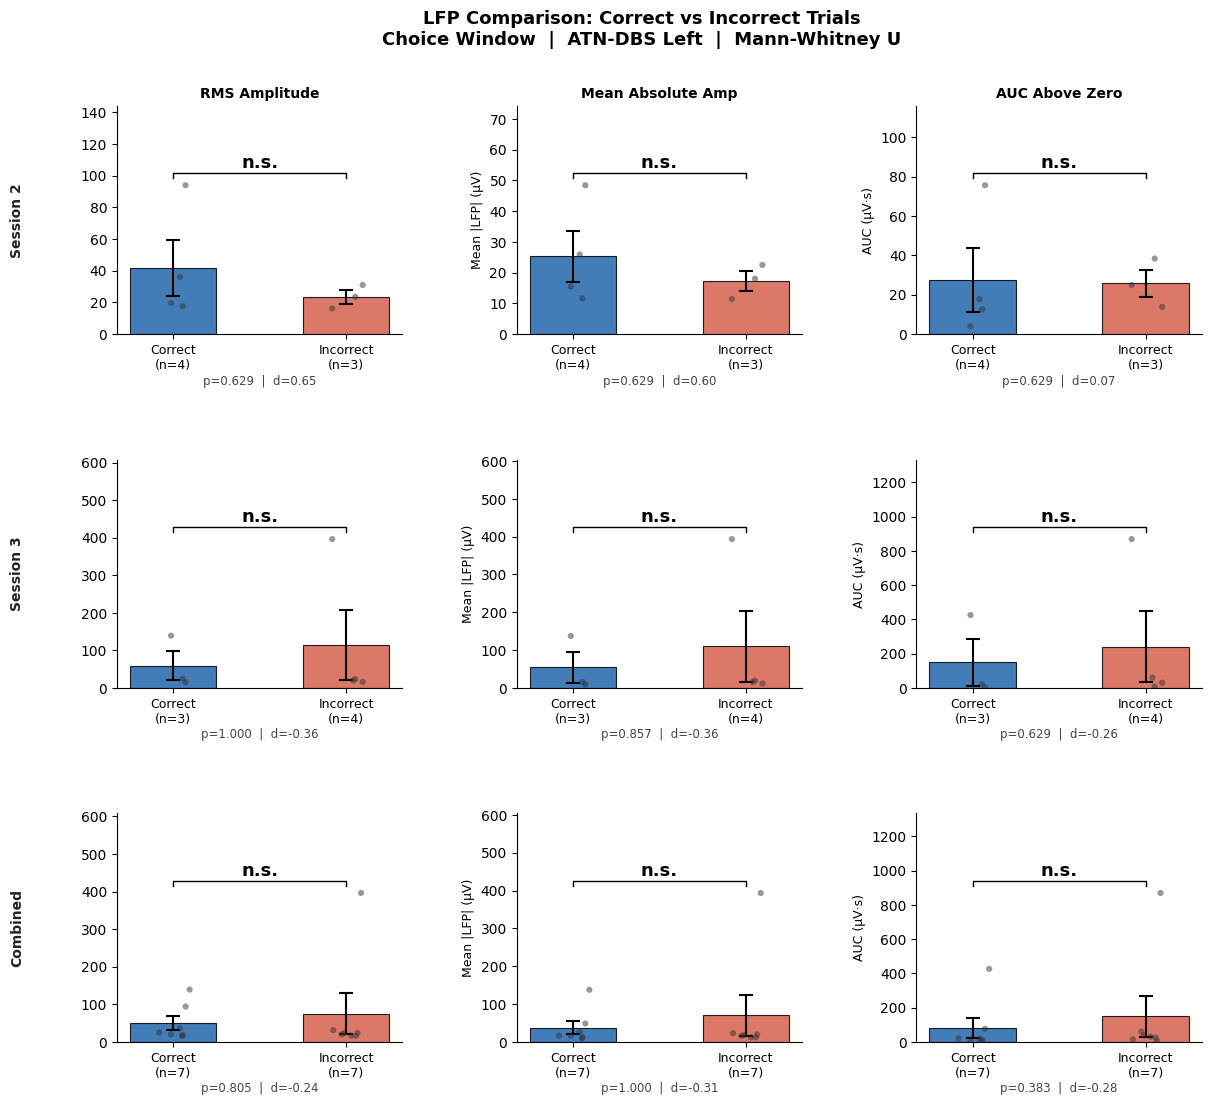

  Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison\fig1_correct_vs_incorrect.png
--- Figure 2: Session 2 vs Session 3 ---


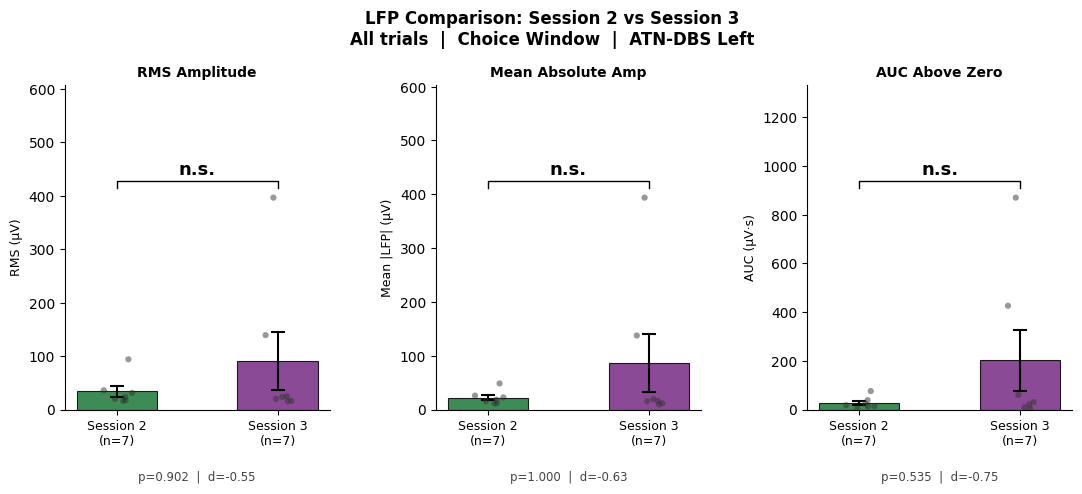

  Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison\fig2_session2_vs_session3.png
--- Figure 3: Stim ON vs Stim OFF (S2) ---


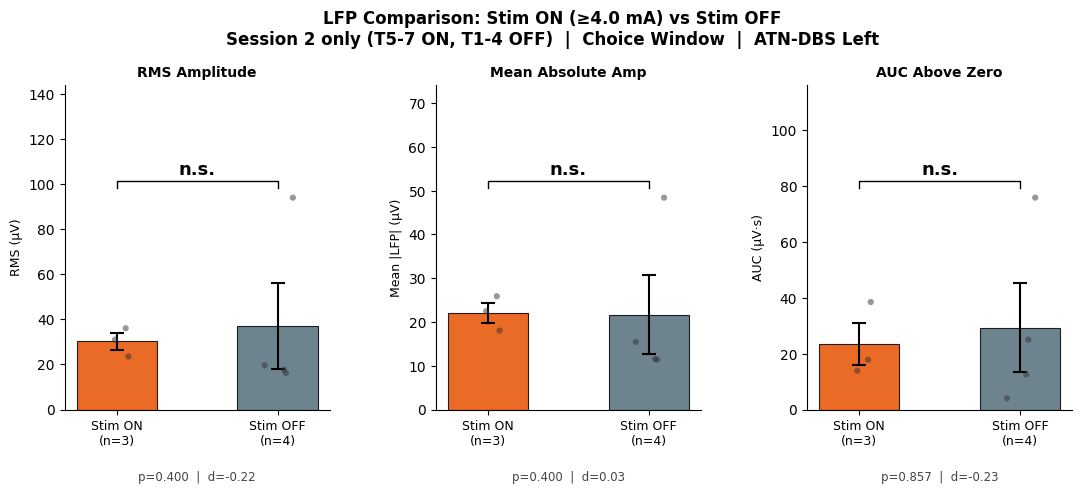

  Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison\fig3_stim_on_vs_off.png
--- Figure 4: Difficulty Levels ---


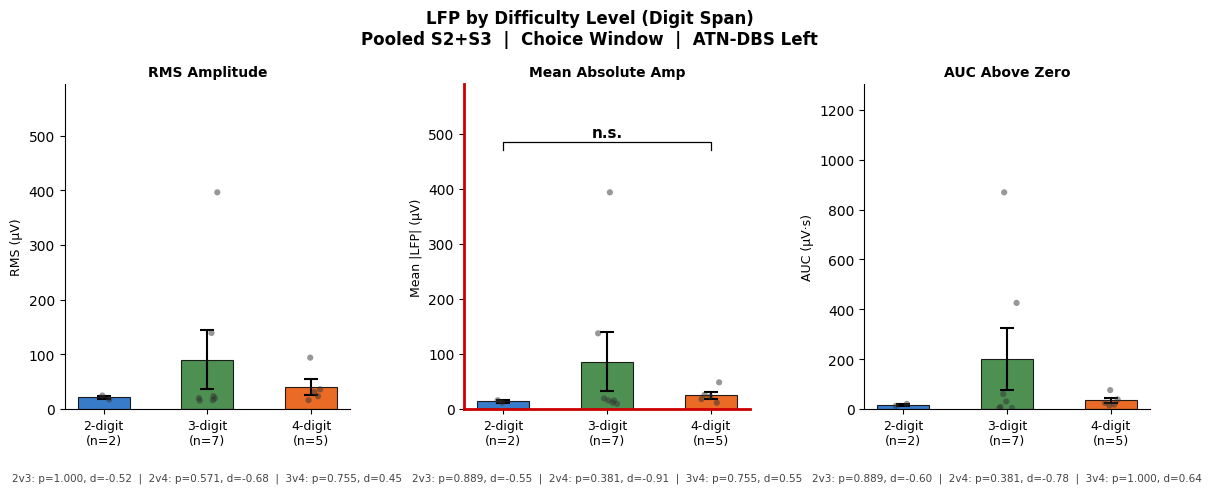

  Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison\fig4_difficulty_levels.png
--- Figure 5: Accuracy × Session Interaction ---


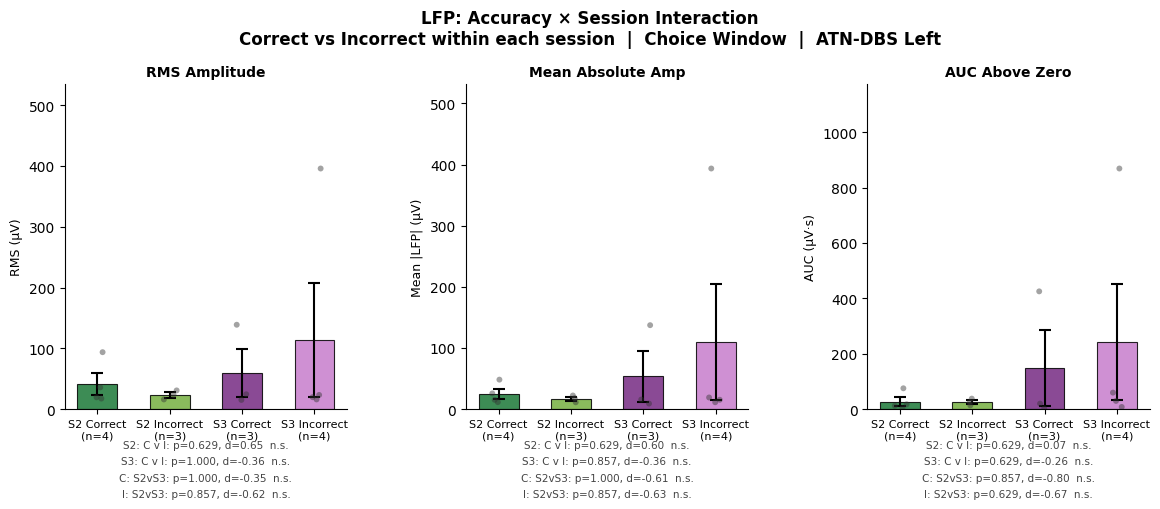

  Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison\fig5_accuracy_session_interaction.png
--- Figure 6: RT vs LFP Metrics ---


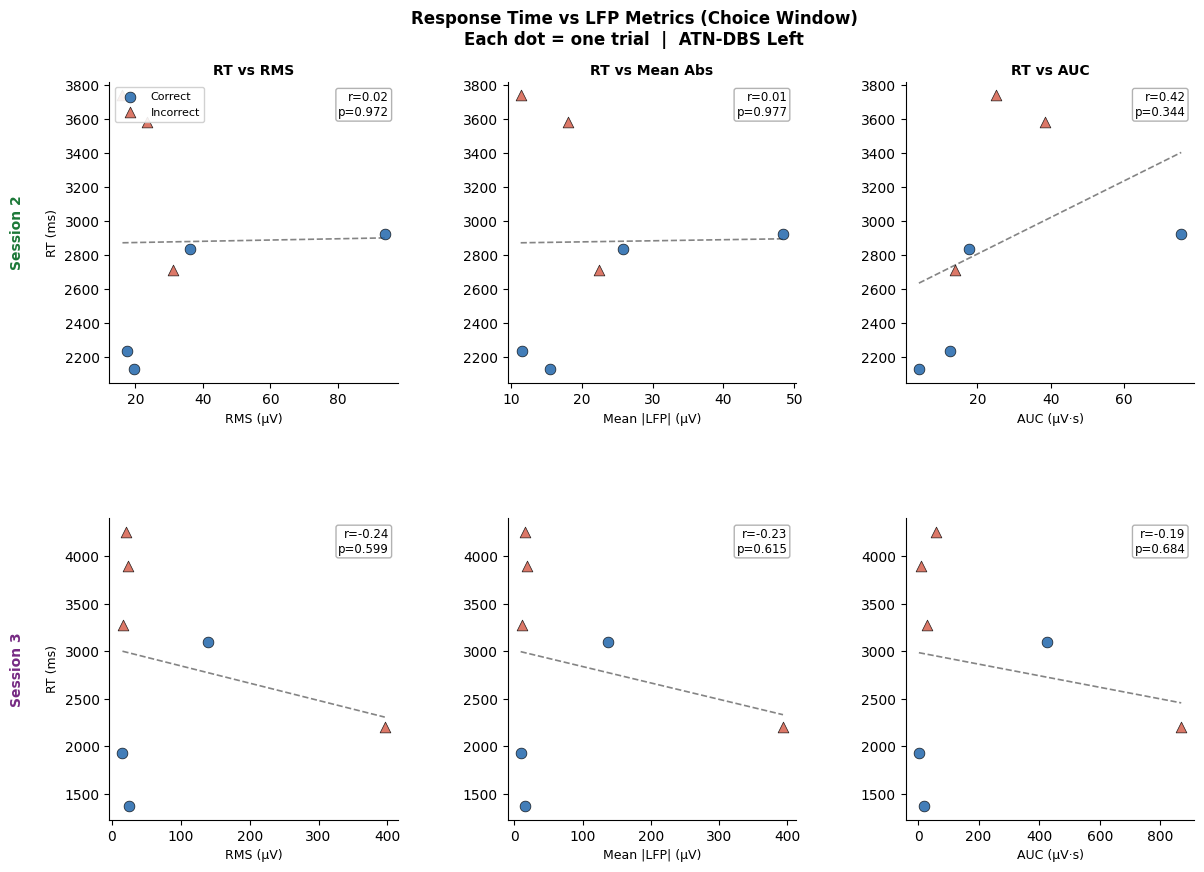

  Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison\fig6_rt_vs_lfp.png
--- Figure 7: Summary Statistics Table ---

=== SUMMARY STATISTICS ===
                         Comparison  nA  nB  MeanA  MeanB     p     d  Sig
           rms | S2: Corr vs Incorr   4   3  41.80  23.55 0.629  0.65 n.s.
           rms | S3: Corr vs Incorr   3   4  59.68 113.95 1.000 -0.36 n.s.
     rms | Combined: Corr vs Incorr   7   7  49.46  75.21 0.805 -0.24 n.s.
                     rms | S2 vs S3   7   7  33.98  90.69 0.902 -0.55 n.s.
           rms | S2: Stim ON vs OFF   3   4  30.18  36.82 0.400 -0.22 n.s.
      mean_abs | S2: Corr vs Incorr   4   3  25.33  17.30 0.629  0.60 n.s.
      mean_abs | S3: Corr vs Incorr   3   4  54.21 109.95 0.857 -0.36 n.s.
mean_abs | Combined: Corr vs Incorr   7   7  37.71  70.25 1.000 -0.31 n.s.
                mean_abs | S2 vs S3   7   7  21.89  86.06 1.000 -0.63 n.s.
      mean_abs | S2: Stim ON vs OFF   3   4  22.14  21.71 0.400  0.03 n.s.
           auc | S2: Cor

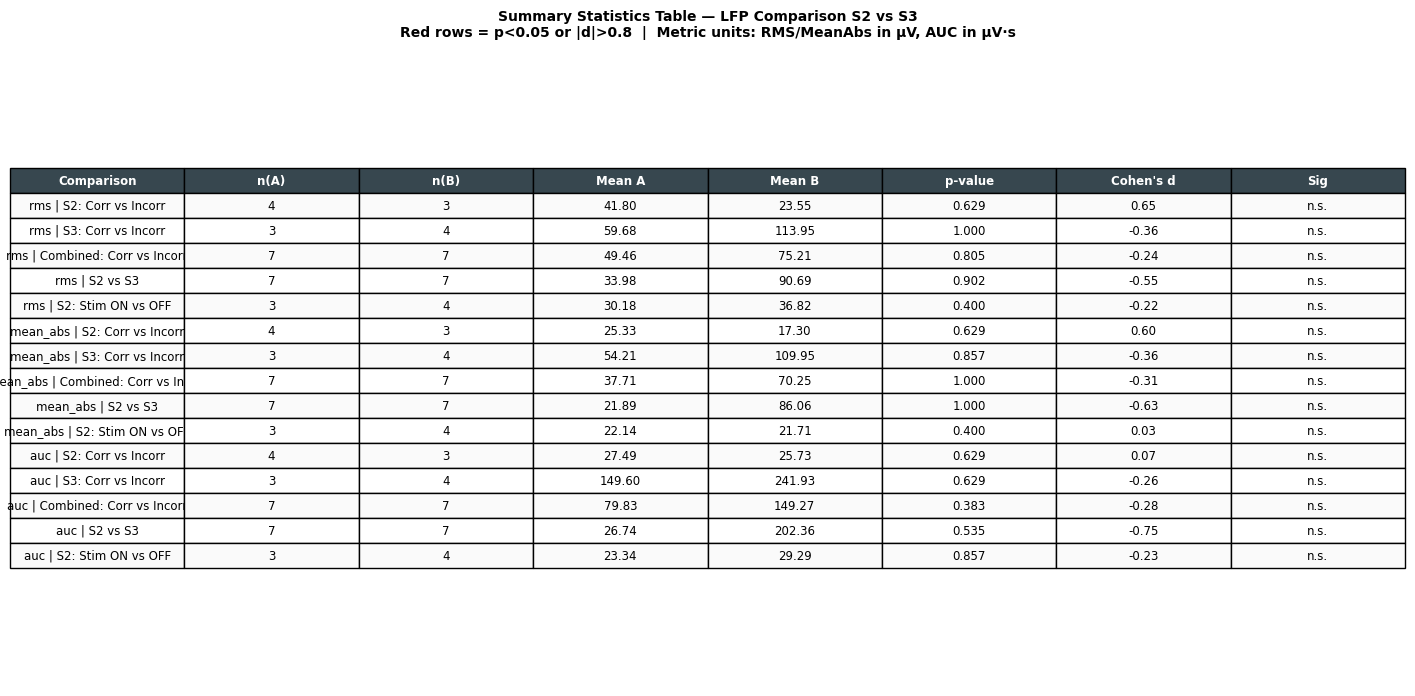

  Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison\fig7_summary_table.png

=== ALL DONE ===
All figures saved to: C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison


In [ ]:
"""
session_comparison.py
=====================
Comprehensive LFP comparison: Session 2 vs Session 3
ATN-DBS  |  Digit Span Backward  |  Roy's Lab

COMPARISONS:
  A. Correct vs Incorrect  — within S2, within S3, combined
  B. Session 2 vs Session 3  — overall LFP level
  C. Stim ON vs Stim OFF  — within S2 (T5-7 STIM ON vs T1-4 OFF)
  D. Difficulty  — 2-digit vs 3-digit vs 4-digit (pooled across sessions)
  E. Accuracy × Session interaction  — bar matrix

NEURAL METRIC (choice window):
  RMS amplitude, Mean absolute amplitude, AUC above zero
  All computed over the full Choice Start → Choice End window per trial

ALIGNMENT:
  stim_start_tick = first 0→>0 mA transition in BrainSenseLfp
  OFFSET = stim_start_tick − Welcome.TargetOnsetTime
  rel_ms  = eprime_ms + OFFSET − stim_start_tick  →  t=0 = Welcome

STATISTICS:
  n_trials is small — report descriptive stats + Mann-Whitney U (non-parametric)
  Cohen's d (effect size)   |   p-value   |   Red border if |d| > 0.8 or p < 0.05

Dependencies: pip install pandas numpy scipy matplotlib
"""

# =============================================================================
# IMPORTS & PATHS  ← EDIT THESE
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind
from pathlib import Path

S2_JSON   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
S2_EPRIME = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
S3_JSON   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
S3_EPRIME = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
OUT_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Comparison")

CHANNEL   = 'ZERO_THREE_LEFT'   # change to ZERO_THREE_RIGHT to switch
STIM_THRESH_MA = 4.0            # mA — stim is ON when Left mA >= this

OUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# DATA LOADING HELPERS
# =============================================================================

def build_neural(report, channel=CHANNEL):
    """Concatenate all TimeDomain streams for channel → (data, tick_times_ms)."""
    bstd = report['BrainSenseTimeDomain']
    streams = [s for s in bstd if s['Channel'] == channel]
    all_data, all_times = [], []
    dt_ms = 1000.0 / 250.0   # 250 Hz → 4 ms per sample
    for s in streams:
        data = np.array(s['TimeDomainData'], float)
        ticks = [float(x) for x in s['TicksInMses'].split(',') if x.strip()]
        pkt_sizes = [int(x) for x in s['GlobalPacketSizes'].split(',') if x.strip()]
        t_arr = []
        for tick, n in zip(ticks, pkt_sizes):
            for k in range(n):
                t_arr.append(tick + k * dt_ms)
        mn = min(len(data), len(t_arr))
        all_data.extend(data[:mn])
        all_times.extend(t_arr[:mn])
    return np.array(all_data), np.array(all_times)


def find_stim_start_tick(report):
    """Find tick of first 0→>0 mA transition in BrainSenseLfp (Left)."""
    for stream in report['BrainSenseLfp']:
        prev = 0.0
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev == 0.0 and curr > 0.0:
                return float(pkt['TicksInMs'])
            prev = curr
    raise ValueError("No 0→>0 mA transition found!")


def get_bslf(report, stim_tick):
    """Return (rel_ms, mA_left) arrays for BrainSenseLfp."""
    tick_list, mA_list = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            tick_list.append(pkt['TicksInMs'])
            mA_list.append(pkt['Left']['mA'])
    t = np.array(tick_list, float) - stim_tick
    m = np.array(mA_list, float)
    return t, m


def mA_at(bslf_rel, bslf_mA, rel_ms):
    """Step-interpolate mA at a given relative time."""
    idx = int(np.searchsorted(bslf_rel, rel_ms, side='right')) - 1
    return float(bslf_mA[idx]) if idx >= 0 else 0.0


def load_session(json_path, eprime_path, session_label):
    """
    Load one session: neural data + trial behavioral data, aligned.

    Returns dict with:
      neural_data, neural_rel_ms   — full LFP trace (µV), time axis (ms from task start)
      bslf_rel, bslf_mA            — stim amplitude step trace
      trials                       — DataFrame (one row per trial)
    """
    with open(json_path) as f:
        report = json.load(f)
    df = pd.read_csv(eprime_path, encoding='utf-8-sig', low_memory=False)

    welcome_ms = int(df['Welcome.TargetOnsetTime'].iloc[0])
    goodbye_ms = int(df['Goodbye.FinishTime'].iloc[0])

    stim_tick = find_stim_start_tick(report)
    offset    = stim_tick - welcome_ms          # OFFSET = stim_start_tick - welcome_ms

    def to_rel(eprime_ms):
        return float(eprime_ms) + offset - stim_tick   # = eprime_ms - welcome_ms

    # Neural
    neural_data, neural_ticks = build_neural(report, CHANNEL)
    neural_rel_ms = neural_ticks - stim_tick

    # Stim amplitude trace
    bslf_rel, bslf_mA = get_bslf(report, stim_tick)

    # Trials
    rows = []
    for block in sorted(df['Block'].dropna().unique()):
        sub = df[df['Block'] == block]
        r   = sub.iloc[0]

        cs_ms = to_rel(r['CollectResponse.OnsetTime'])
        ce_ms = to_rel(r['CollectResponse.RTTime'])
        fb_s  = to_rel(r['Feedback.OnsetTime'])
        fb_e  = to_rel(r['Feedback.OffsetTime'])
        stim_disp = to_rel(sub['Stimulus.OnsetTime'].min())

        mid_choice = (cs_ms + ce_ms) / 2.0
        ma_val     = mA_at(bslf_rel, bslf_mA, mid_choice)
        stim_on    = ma_val >= STIM_THRESH_MA

        rows.append(dict(
            session   = session_label,
            trial     = int(block),
            num_digits= int(r['CurrentSpanSize[Trial]']),
            acc       = int(r['CollectResponse.ACC']),
            rt_ms     = int(r['CollectResponse.RT']),
            cs_ms     = cs_ms,
            ce_ms     = ce_ms,
            fb_s_ms   = fb_s,
            fb_e_ms   = fb_e,
            stim_disp_ms = stim_disp,
            mA        = ma_val,
            stim_on   = stim_on,
            choice_dur= ce_ms - cs_ms,
        ))

    trials = pd.DataFrame(rows)

    return dict(
        label        = session_label,
        neural_data  = neural_data,
        neural_rel_ms= neural_rel_ms,
        bslf_rel     = bslf_rel,
        bslf_mA      = bslf_mA,
        trials       = trials,
        sess_end_ms  = to_rel(goodbye_ms),
    )


# =============================================================================
# EPOCH EXTRACTION
# =============================================================================
SR = 250   # Hz

def extract_epoch(neural_data, neural_rel_ms, window_start_ms, window_end_ms,
                  baseline_ms=500):
    """
    Extract epoch from window_start to window_end (both in rel_ms).
    Baseline-corrects using `baseline_ms` of data BEFORE window_start.
    Returns epoch array or None if out of range.
    """
    idx_start = np.searchsorted(neural_rel_ms, window_start_ms)
    idx_end   = np.searchsorted(neural_rel_ms, window_end_ms)
    idx_bl_start = np.searchsorted(neural_rel_ms, window_start_ms - baseline_ms)

    if idx_bl_start < 0 or idx_end > len(neural_data):
        return None

    baseline = np.mean(neural_data[idx_bl_start:idx_start]) if idx_start > idx_bl_start else 0.0
    epoch    = neural_data[idx_start:idx_end] - baseline

    return epoch if len(epoch) >= 5 else None   # need at least 5 samples


def epoch_metrics(epoch, dt=1.0/SR):
    """Compute RMS, mean abs amplitude, and AUC above zero for an epoch."""
    rms     = float(np.sqrt(np.mean(epoch**2)))
    mean_abs= float(np.mean(np.abs(epoch)))
    auc     = float(np.trapezoid(np.maximum(epoch, 0), dx=dt))
    return rms, mean_abs, auc


def get_trial_metrics(session, window='choice'):
    """
    Compute LFP metrics for each trial.
    window='choice': CS → CE
    """
    nd  = session['neural_data']
    nrl = session['neural_rel_ms']
    rows = []
    for _, t in session['trials'].iterrows():
        if window == 'choice':
            w_start = t['cs_ms']
            w_end   = t['ce_ms']
        epoch = extract_epoch(nd, nrl, w_start, w_end)
        if epoch is None:
            continue
        rms, mean_abs, auc = epoch_metrics(epoch)
        rows.append(dict(
            session   = t['session'],
            trial     = t['trial'],
            num_digits= t['num_digits'],
            acc       = t['acc'],
            rt_ms     = t['rt_ms'],
            stim_on   = t['stim_on'],
            mA        = t['mA'],
            rms       = rms,
            mean_abs  = mean_abs,
            auc       = auc,
            choice_dur= t['choice_dur'],
        ))
    return pd.DataFrame(rows)


# =============================================================================
# STATISTICS HELPERS
# =============================================================================

def cohens_d(x, y):
    """Pooled Cohen's d (independent groups)."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / pooled_std if pooled_std > 0 else 0.0


def run_stats(a, b):
    """Mann-Whitney U + Cohen's d. Returns (U, p, d, sig_str)."""
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, np.nan, 'n<2'
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    d    = cohens_d(np.array(a), np.array(b))
    if p < 0.001:   sig = '***'
    elif p < 0.01:  sig = '**'
    elif p < 0.05:  sig = '*'
    else:           sig = 'n.s.'
    return U, p, d, sig


def is_highlight(p, d):
    """Red border if p<0.05 OR |d|>0.8."""
    if p is None or np.isnan(p) or d is None or np.isnan(d):
        return False
    return p < 0.05 or abs(d) > 0.8


# =============================================================================
# PLOTTING HELPERS
# =============================================================================

C_CORRECT   = '#2166AC'   # blue
C_INCORRECT = '#D6604D'   # red-orange
C_S2        = '#1B7837'   # green
C_S3        = '#762A83'   # purple
C_ON        = '#E65100'   # orange
C_OFF       = '#546E7A'   # grey-blue

def bar_pair(ax, vals_a, vals_b, label_a, label_b, col_a, col_b,
             title, ylabel, metric_name):
    """
    Draw a two-bar comparison plot with individual dots, SEM error bars,
    significance bracket, and p / Cohen's d annotation.
    Red border on axes if highlight condition met.
    """
    U, p, d, sig = run_stats(vals_a, vals_b)

    means = [np.mean(vals_a), np.mean(vals_b)]
    sems  = [stats.sem(vals_a) if len(vals_a) > 1 else 0,
             stats.sem(vals_b) if len(vals_b) > 1 else 0]

    bars = ax.bar([0, 1], means, yerr=sems, capsize=5,
                  color=[col_a, col_b], alpha=0.85, width=0.5,
                  edgecolor='black', linewidth=0.8,
                  error_kw=dict(lw=1.5, capthick=1.5, color='#333'))

    jit = 0.10
    rng = np.random.default_rng(42)
    ax.scatter(rng.uniform(-jit, jit, len(vals_a)),
               vals_a, s=20, color='#333', alpha=0.5, zorder=3, edgecolors='none')
    ax.scatter(1 + rng.uniform(-jit, jit, len(vals_b)),
               vals_b, s=20, color='#333', alpha=0.5, zorder=3, edgecolors='none')

    y_top = max(max(vals_a, default=0), max(vals_b, default=0))
    y_max = y_top * 1.30 if y_top > 0 else 1.0

    bkt_y = y_top * 1.08
    ax.plot([0, 0, 1, 1], [bkt_y*0.97, bkt_y, bkt_y, bkt_y*0.97], 'k-', lw=1)
    ax.text(0.5, bkt_y * 1.01, sig, ha='center', va='bottom', fontsize=13, fontweight='bold')

    ax.set_ylim(0, y_max * 1.18)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'{label_a}\n(n={len(vals_a)})', f'{label_b}\n(n={len(vals_b)})'],
                       fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)

    # p and d annotation below x axis
    p_str = f'p={p:.3f}' if (p is not None and not np.isnan(p) and p >= 0.001) else 'p<0.001'
    d_str = f'd={d:.2f}' if (d is not None and not np.isnan(d)) else 'd=N/A'
    ax.text(0.5, -0.22, f'{p_str}  |  {d_str}',
            transform=ax.transAxes, ha='center', fontsize=8.5, color='#444')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Red border if significant or large effect
    hl = is_highlight(p, d)
    for spine in ax.spines.values():
        if hl:
            spine.set_edgecolor('#CC0000')
            spine.set_linewidth(2.0)

    return p, d, sig


def save_fig(fig, name):
    path = OUT_DIR / f'{name}.png'
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'  Saved → {path}')


# =============================================================================
# LOAD SESSIONS
# =============================================================================
print("Loading Session 2...")
s2 = load_session(S2_JSON, S2_EPRIME, 'S2')
print("Loading Session 3...")
s3 = load_session(S3_JSON, S3_EPRIME, 'S3')

print(f"\nS2 trials:\n{s2['trials'][['trial','num_digits','acc','stim_on','mA','rt_ms']].to_string(index=False)}")
print(f"\nS3 trials:\n{s3['trials'][['trial','num_digits','acc','stim_on','mA','rt_ms']].to_string(index=False)}")

# Compute trial-level LFP metrics for both sessions
m2 = get_trial_metrics(s2)
m3 = get_trial_metrics(s3)
mall = pd.concat([m2, m3], ignore_index=True)

print(f"\nS2 metrics ({len(m2)} trials):")
print(m2[['trial','num_digits','acc','stim_on','rms','mean_abs','auc']].round(3).to_string(index=False))
print(f"\nS3 metrics ({len(m3)} trials):")
print(m3[['trial','num_digits','acc','stim_on','rms','mean_abs','auc']].round(3).to_string(index=False))


# =============================================================================
# FIGURE 1 — CORRECT vs INCORRECT  (within S2, within S3, combined)
# =============================================================================
print("\n--- Figure 1: Correct vs Incorrect ---")

fig1, axes = plt.subplots(3, 3, figsize=(14, 12), facecolor='white')
fig1.suptitle('LFP Comparison: Correct vs Incorrect Trials\n'
              'Choice Window  |  ATN-DBS Left  |  Mann-Whitney U',
              fontsize=13, fontweight='bold')
plt.subplots_adjust(hspace=0.55, wspace=0.40, top=0.90, bottom=0.12)

for row_i, (df_sub, row_label) in enumerate([(m2, 'Session 2'), (m3, 'Session 3'), (mall, 'Combined S2+S3')]):
    corr = df_sub[df_sub['acc'] == 1]
    incr = df_sub[df_sub['acc'] == 0]
    for col_i, (metric, ylabel, title) in enumerate([
        ('rms',      'RMS (µV)',     'RMS Amplitude'),
        ('mean_abs', 'Mean |LFP| (µV)', 'Mean Absolute Amp'),
        ('auc',      'AUC (µV·s)',   'AUC Above Zero'),
    ]):
        ax = axes[row_i, col_i]
        ax.set_facecolor('white')
        if col_i == 0:
            ax.set_ylabel(f'{row_label}\n{ylabel}', fontsize=9)
        bar_pair(ax,
                 corr[metric].values, incr[metric].values,
                 'Correct', 'Incorrect',
                 C_CORRECT, C_INCORRECT,
                 title if row_i == 0 else '',
                 ylabel if col_i != 0 else '',
                 metric)

# Row labels on left
for row_i, lbl in enumerate(['Session 2', 'Session 3', 'Combined']):
    axes[row_i, 0].annotate(lbl, xy=(-0.35, 0.5), xycoords='axes fraction',
                             fontsize=10, fontweight='bold', rotation=90,
                             va='center', ha='center', color='#222')

save_fig(fig1, 'fig1_correct_vs_incorrect')


# =============================================================================
# FIGURE 2 — SESSION 2 vs SESSION 3  (overall)
# =============================================================================
print("--- Figure 2: Session 2 vs Session 3 ---")

fig2, axes = plt.subplots(1, 3, figsize=(13, 5), facecolor='white')
fig2.suptitle('LFP Comparison: Session 2 vs Session 3\n'
              'All trials  |  Choice Window  |  ATN-DBS Left',
              fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.40, top=0.83, bottom=0.18)

for col_i, (metric, ylabel, title) in enumerate([
    ('rms',      'RMS (µV)',       'RMS Amplitude'),
    ('mean_abs', 'Mean |LFP| (µV)', 'Mean Absolute Amp'),
    ('auc',      'AUC (µV·s)',     'AUC Above Zero'),
]):
    ax = axes[col_i]
    ax.set_facecolor('white')
    bar_pair(ax,
             m2[metric].values, m3[metric].values,
             'Session 2', 'Session 3',
             C_S2, C_S3,
             title, ylabel, metric)

save_fig(fig2, 'fig2_session2_vs_session3')


# =============================================================================
# FIGURE 3 — STIM ON vs STIM OFF  (S2 only: T5-7 ON vs T1-4 OFF)
# =============================================================================
print("--- Figure 3: Stim ON vs Stim OFF (S2) ---")

m2_on  = m2[m2['stim_on'] == True]
m2_off = m2[m2['stim_on'] == False]

fig3, axes = plt.subplots(1, 3, figsize=(13, 5), facecolor='white')
fig3.suptitle(f'LFP Comparison: Stim ON (≥{STIM_THRESH_MA} mA) vs Stim OFF\n'
              f'Session 2 only (T5-7 ON, T1-4 OFF)  |  Choice Window  |  ATN-DBS Left',
              fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.40, top=0.83, bottom=0.18)

for col_i, (metric, ylabel, title) in enumerate([
    ('rms',      'RMS (µV)',       'RMS Amplitude'),
    ('mean_abs', 'Mean |LFP| (µV)', 'Mean Absolute Amp'),
    ('auc',      'AUC (µV·s)',     'AUC Above Zero'),
]):
    ax = axes[col_i]
    ax.set_facecolor('white')
    bar_pair(ax,
             m2_on[metric].values, m2_off[metric].values,
             'Stim ON', 'Stim OFF',
             C_ON, C_OFF,
             title, ylabel, metric)

save_fig(fig3, 'fig3_stim_on_vs_off')


# =============================================================================
# FIGURE 4 — DIFFICULTY: 2 vs 3 vs 4 digits (pooled, all trials)
# =============================================================================
print("--- Figure 4: Difficulty Levels ---")

diffs = sorted(mall['num_digits'].unique())
n_d = len(diffs)
diff_colors = {2: '#1565C0', 3: '#2E7D32', 4: '#E65100', 5: '#6A1B9A'}
metrics_info = [('rms', 'RMS (µV)', 'RMS Amplitude'),
                ('mean_abs', 'Mean |LFP| (µV)', 'Mean Absolute Amp'),
                ('auc', 'AUC (µV·s)', 'AUC Above Zero')]

fig4, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='white')
fig4.suptitle('LFP by Difficulty Level (Digit Span)\n'
              'Pooled S2+S3  |  Choice Window  |  ATN-DBS Left',
              fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.40, top=0.83, bottom=0.18)

rng = np.random.default_rng(42)
for col_i, (metric, ylabel, title) in enumerate(metrics_info):
    ax = axes[col_i]
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    groups = [mall[mall['num_digits'] == d][metric].values for d in diffs]
    means  = [g.mean() for g in groups]
    sems   = [stats.sem(g) if len(g) > 1 else 0 for g in groups]
    cols   = [diff_colors.get(d, '#333') for d in diffs]

    ax.bar(range(n_d), means, yerr=sems, capsize=5,
           color=cols, alpha=0.85, width=0.5,
           edgecolor='black', linewidth=0.8,
           error_kw=dict(lw=1.5, capthick=1.5, color='#333'))

    for xi, (g, c) in enumerate(zip(groups, cols)):
        ax.scatter(xi + rng.uniform(-0.10, 0.10, len(g)),
                   g, s=20, color='#333', alpha=0.5, zorder=3, edgecolors='none')

    # Pairwise stats annotations (brackets for adjacent pairs)
    y_top = max(g.max() for g in groups if len(g) > 0)
    y_step = y_top * 0.15
    bkt_y = y_top * 1.08
    pairs = [(i, j) for i in range(n_d) for j in range(i+1, n_d)]
    any_sig = False
    for pi, (i, j) in enumerate(pairs):
        if len(groups[i]) < 2 or len(groups[j]) < 2:
            continue
        _, p_ij, d_ij, sig_ij = run_stats(groups[i], groups[j])
        if p_ij < 0.05 or abs(d_ij) > 0.8:
            any_sig = True
            bh = bkt_y + pi * y_step
            ax.plot([i, i, j, j], [bh*0.97, bh, bh, bh*0.97], 'k-', lw=0.9)
            ax.text((i+j)/2.0, bh*1.01, sig_ij, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylim(0, max(y_top * 1.50, 1e-3))
    ax.set_xticks(range(n_d))
    ax.set_xticklabels([f'{d}-digit\n(n={len(groups[i])})'
                         for i, d in enumerate(diffs)], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)

    # All pairwise p/d below
    pd_strs = []
    for i, j in pairs:
        if len(groups[i]) < 2 or len(groups[j]) < 2:
            continue
        _, p_ij, d_ij, _ = run_stats(groups[i], groups[j])
        p_str = f'p={p_ij:.3f}' if p_ij >= 0.001 else 'p<0.001'
        pd_strs.append(f'{diffs[i]}v{diffs[j]}: {p_str}, d={d_ij:.2f}')
    ax.text(0.5, -0.22, '  |  '.join(pd_strs),
            transform=ax.transAxes, ha='center', fontsize=7.5, color='#444')

    if any_sig:
        for spine in ax.spines.values():
            spine.set_edgecolor('#CC0000')
            spine.set_linewidth(2.0)

save_fig(fig4, 'fig4_difficulty_levels')


# =============================================================================
# FIGURE 5 — ACCURACY × SESSION INTERACTION
# =============================================================================
print("--- Figure 5: Accuracy × Session Interaction ---")

fig5, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='white')
fig5.suptitle('LFP: Accuracy × Session Interaction\n'
              'Correct vs Incorrect within each session  |  Choice Window  |  ATN-DBS Left',
              fontsize=12, fontweight='bold')
plt.subplots_adjust(wspace=0.42, top=0.83, bottom=0.18)

rng = np.random.default_rng(42)
group_defs = [('S2 Correct', m2, 1, C_S2),
              ('S2 Incorrect', m2, 0, '#76B041'),
              ('S3 Correct', m3, 1, C_S3),
              ('S3 Incorrect', m3, 0, '#C77DCC')]

for col_i, (metric, ylabel, title) in enumerate(metrics_info):
    ax = axes[col_i]
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    vals  = [df_sub[df_sub['acc'] == acc_val][metric].values
             for _, df_sub, acc_val, _ in group_defs]
    cols  = [c for _, _, _, c in group_defs]
    lbls  = [f'{lbl}\n(n={len(v)})' for (lbl, _, _, _), v in zip(group_defs, vals)]

    means = [v.mean() for v in vals]
    sems  = [stats.sem(v) if len(v) > 1 else 0 for v in vals]

    ax.bar(range(4), means, yerr=sems, capsize=4,
           color=cols, alpha=0.85, width=0.55,
           edgecolor='black', linewidth=0.8,
           error_kw=dict(lw=1.5, capthick=1.5, color='#333'))

    for xi, (v, c) in enumerate(zip(vals, cols)):
        ax.scatter(xi + rng.uniform(-0.10, 0.10, len(v)),
                   v, s=18, color='#333', alpha=0.45, zorder=3, edgecolors='none')

    y_top = max((v.max() for v in vals if len(v) > 0), default=1)

    # Key comparisons: S2C vs S2I, S3C vs S3I, S2C vs S3C, S2I vs S3I
    comparisons = [
        (0, 1, 'S2: C v I', -0.12),
        (2, 3, 'S3: C v I', -0.17),
        (0, 2, 'C: S2vS3', -0.22),
        (1, 3, 'I: S2vS3', -0.27),
    ]
    any_sig = False
    for i, j, lbl, y_off in comparisons:
        if len(vals[i]) < 2 or len(vals[j]) < 2:
            continue
        _, p_ij, d_ij, sig_ij = run_stats(vals[i], vals[j])
        p_str = f'p={p_ij:.3f}' if p_ij >= 0.001 else 'p<0.001'
        ax.text(0.5, y_off,
                f'{lbl}: {p_str}, d={d_ij:.2f}  {sig_ij}',
                transform=ax.transAxes, ha='center', fontsize=7.5, color='#444')
        if is_highlight(p_ij, d_ij):
            any_sig = True

    ax.set_ylim(0, y_top * 1.35)
    ax.set_xticks(range(4))
    ax.set_xticklabels(lbls, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)

    if any_sig:
        for spine in ax.spines.values():
            spine.set_edgecolor('#CC0000')
            spine.set_linewidth(2.0)

save_fig(fig5, 'fig5_accuracy_session_interaction')


# =============================================================================
# FIGURE 6 — RESPONSE TIME vs LFP METRICS  (scatter per session)
# =============================================================================
print("--- Figure 6: RT vs LFP Metrics ---")

fig6, axes = plt.subplots(2, 3, figsize=(14, 9), facecolor='white')
fig6.suptitle('Response Time vs LFP Metrics (Choice Window)\n'
              'Each dot = one trial  |  ATN-DBS Left',
              fontsize=12, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.38, top=0.90, bottom=0.08)

for row_i, (df_sub, row_label, col_main) in enumerate([(m2, 'Session 2', C_S2), (m3, 'Session 3', C_S3)]):
    for col_i, (metric, xlabel, title) in enumerate([
        ('rms',      'RMS (µV)',       'RT vs RMS'),
        ('mean_abs', 'Mean |LFP| (µV)', 'RT vs Mean Abs'),
        ('auc',      'AUC (µV·s)',     'RT vs AUC'),
    ]):
        ax = axes[row_i, col_i]
        ax.set_facecolor('white')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        corr = df_sub[df_sub['acc'] == 1]
        incr = df_sub[df_sub['acc'] == 0]

        ax.scatter(corr[metric], corr['rt_ms'], s=60, color=C_CORRECT,
                   label='Correct', zorder=3, alpha=0.85, edgecolors='k', linewidths=0.5)
        ax.scatter(incr[metric], incr['rt_ms'], s=60, color=C_INCORRECT, marker='^',
                   label='Incorrect', zorder=3, alpha=0.85, edgecolors='k', linewidths=0.5)

        # Correlation line (all)
        x_all = df_sub[metric].values
        y_all = df_sub['rt_ms'].values
        if len(x_all) >= 3 and len(np.unique(x_all)) >= 2:
            try:
                r, p_r = stats.pearsonr(x_all, y_all)
                m_coef, b_coef = np.polyfit(x_all, y_all, 1)
                x_line = np.linspace(x_all.min(), x_all.max(), 100)
                ax.plot(x_line, m_coef*x_line + b_coef,
                        color='#333', lw=1.2, ls='--', alpha=0.6)
                p_str = f'p={p_r:.3f}' if p_r >= 0.001 else 'p<0.001'
                ax.text(0.97, 0.97, f'r={r:.2f}\n{p_str}',
                        transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.9))
            except Exception:
                pass

        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('RT (ms)' if col_i == 0 else '', fontsize=9)
        if row_i == 0:
            ax.set_title(title, fontsize=10, fontweight='bold', pad=5)
        if col_i == 0:
            ax.annotate(row_label, xy=(-0.32, 0.5), xycoords='axes fraction',
                        fontsize=10, fontweight='bold', rotation=90,
                        va='center', ha='center', color=col_main)
        if row_i == 0 and col_i == 0:
            ax.legend(fontsize=8, framealpha=0.9, loc='upper left')

save_fig(fig6, 'fig6_rt_vs_lfp')


# =============================================================================
# FIGURE 7 — FULL SUMMARY TABLE (text panel)
# =============================================================================
print("--- Figure 7: Summary Statistics Table ---")

def fmt_stat_row(label, a_label, b_label, a_vals, b_vals):
    if len(a_vals) < 2 or len(b_vals) < 2:
        return dict(Comparison=label, GroupA=a_label, GroupB=b_label,
                    nA=len(a_vals), nB=len(b_vals),
                    MeanA='N/A', MeanB='N/A', p='N/A', d='N/A', Sig='N/A')
    _, p, d, sig = run_stats(a_vals, b_vals)
    p_str = f'{p:.3f}' if p >= 0.001 else '<0.001'
    return dict(Comparison=label, GroupA=a_label, GroupB=b_label,
                nA=len(a_vals), nB=len(b_vals),
                MeanA=f'{np.mean(a_vals):.2f}', MeanB=f'{np.mean(b_vals):.2f}',
                p=p_str, d=f'{d:.2f}', Sig=sig,
                Highlight=is_highlight(p, d))

summary_rows = []
for metric in ['rms', 'mean_abs', 'auc']:
    # 1. Correct vs Incorrect (S2)
    summary_rows.append(fmt_stat_row(f'{metric} | S2: Corr vs Incorr',
        'S2 Correct', 'S2 Incorrect',
        m2[m2['acc']==1][metric].values, m2[m2['acc']==0][metric].values))
    # 2. Correct vs Incorrect (S3)
    summary_rows.append(fmt_stat_row(f'{metric} | S3: Corr vs Incorr',
        'S3 Correct', 'S3 Incorrect',
        m3[m3['acc']==1][metric].values, m3[m3['acc']==0][metric].values))
    # 3. Correct vs Incorrect (combined)
    summary_rows.append(fmt_stat_row(f'{metric} | Combined: Corr vs Incorr',
        'Combined Correct', 'Combined Incorrect',
        mall[mall['acc']==1][metric].values, mall[mall['acc']==0][metric].values))
    # 4. S2 vs S3
    summary_rows.append(fmt_stat_row(f'{metric} | S2 vs S3',
        'Session 2', 'Session 3', m2[metric].values, m3[metric].values))
    # 5. Stim ON vs OFF (S2)
    summary_rows.append(fmt_stat_row(f'{metric} | S2: Stim ON vs OFF',
        'Stim ON', 'Stim OFF', m2_on[metric].values, m2_off[metric].values))

summary_df = pd.DataFrame(summary_rows)
print("\n=== SUMMARY STATISTICS ===")
print(summary_df[['Comparison','nA','nB','MeanA','MeanB','p','d','Sig']].to_string(index=False))

# Save table as CSV
summary_df.to_csv(OUT_DIR / 'summary_statistics.csv', index=False)
print(f"\n  Saved → {OUT_DIR / 'summary_statistics.csv'}")

# Plot table figure
fig7, ax7 = plt.subplots(figsize=(18, len(summary_rows)*0.45 + 1.5), facecolor='white')
ax7.axis('off')

cols_show = ['Comparison', 'nA', 'nB', 'MeanA', 'MeanB', 'p', 'd', 'Sig']
table_data = [[str(r[c]) for c in cols_show] for r in summary_rows]
col_labels = ['Comparison', 'n(A)', 'n(B)', 'Mean A', 'Mean B', 'p-value', "Cohen's d", 'Sig']

tbl = ax7.table(cellText=table_data, colLabels=col_labels,
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.5)

# Color header
for j in range(len(col_labels)):
    tbl[(0, j)].set_facecolor('#37474F')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Highlight significant rows
for i, row in enumerate(summary_rows):
    hl = row.get('Highlight', False)
    for j in range(len(col_labels)):
        if hl:
            tbl[(i+1, j)].set_facecolor('#FFEBEE')
            tbl[(i+1, j)].set_text_props(color='#B71C1C')
        else:
            tbl[(i+1, j)].set_facecolor('#FAFAFA' if i % 2 == 0 else 'white')

ax7.set_title('Summary Statistics Table — LFP Comparison S2 vs S3\n'
              'Red rows = p<0.05 or |d|>0.8  |  Metric units: RMS/MeanAbs in µV, AUC in µV·s',
              fontsize=10, fontweight='bold', pad=10)

save_fig(fig7, 'fig7_summary_table')

print("\n=== ALL DONE ===")
print(f"All figures saved to: {OUT_DIR}")